# **Benchmarking Generative Models for Conformational Sampling Against Biomolecular Dynamics Simulations**

---

### **MSc Project (AI for Drug Discovery)**

## Ioannis Arzinos

##### supervised by Dr. Wojciech Kopec

---

### Research Question

This study aims to compare three deep learning methods and evaluate their predicted ensembles along the two defining axes of biological relevance: structural similarity to experimentally resolved structures and dynamic behaviour. Using IL-2 as the model system, a library of experimentally resolved structures was curated for evaluating the biological relevance of the predicted ensembles against each state ensemble as the upper bound. After analysing their recovered quality, structural similarity and conformational diversity, a sampling strategy was employed to seed AI-generated structures for running short-timescale MD simulations. By using experimentally resolved structures as initial positions and running MD simulations of crystallographic structures as state representatives, the structural evolution of seeded structures is benchmarked in physical space against the structural similarity and conformational space explored by crystallographic structure simulations as the upper bound. The objective of this study is therefore twofold: to show the extent to which these techniques provide biologically relevant structures in terms of their coordinates, and to what extent these seeds reproduce this biological relevance in physical space compared to crystallographic IL-2 structures under short-timescale MD simulations.

# Appendix 1 - Reference and Predicted Ensemble Analysis (BioEmu, AFsample2, MSA subsampling) & MD Seed Selection

---
#### **MSc Thesis, AI for Drug Discovery**

This notebook is the cleaned, publication-facing companion to the working analysis notebook
(`IL2_Conformational_Analysis_Curated.ipynb`): every number and figure below is produced by the
same underlying computation, restructured here to follow the thesis write-up section for
section, with results printed as plain tables rather than raw DataFrame dumps. Run top to bottom
(Kernel → Restart & Run All) — every section only depends on what has already run above it.

## Research Question

This study aims to compare three deep learning methods and evaluate their predicted ensembles
along the two defining axes of biological relevance: structural similarity to experimentally
resolved structures and dynamic behaviour. Using IL-2 as the model system, a library of
experimentally resolved structures will be curated for evaluating the biological relevance of
the predicted ensembles against each state ensemble as the upper bound. After analysing their
recovered quality, structural similarity and conformational diversity, a sampling strategy will
be employed to seed AI-generated structures for running short-timescale MD simulations. By using
experimentally resolved structures as initial positions and running MD simulations of
crystallographic structures as state representatives, the structural evolution of seeded
structures will be benchmarked in physical space against the structural similarity and
conformational space explored by crystallographic structure simulations as the upper bound. The
objective of this study is therefore twofold: to show the extent to which these techniques
provide biologically relevant structures in terms of their coordinates, and to what extent these
seeds reproduce this biological relevance in physical space compared to crystallographic IL-2
structures under short-timescale MD simulations.

## 0. Helper Functions

Structure I/O, superposition, RMSD/TM-score, PCA-basis fitting, DSSP and BioEmu backbone
reconstruction utilities used throughout every section below. No results here -- skip ahead to
Section 1 for the actual analysis.

In [1]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import mdtraj as md
from scipy.spatial import ConvexHull, cKDTree
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import mannwhitneyu, ks_2samp, spearmanr

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

# Okabe-Ito colorblind-safe palette, one color per series used throughout.
COLOR_REF = "#4d4d4d"
COLOR_MSA = "#0072B2"   # MSA Subsampling (af2_msa_sweep) -- was mislabelled "AFsample2"
COLOR_AFS2 = "#009E73"  # AFsample2 (real, dropout-based) -- new in this version
COLOR_BIO = "#D55E00"   # BioEmu
MODEL_COLORS = {"MSA Subsampling": COLOR_MSA, "AFsample2": COLOR_AFS2, "BioEmu": COLOR_BIO}
MODEL_NAMES = ["MSA Subsampling", "AFsample2", "BioEmu"]

mpl.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.size": 10,
})

STATES = ["apo", "holo", "ligand"]
STATE_LABELS = {"apo": "Apo (unbound)", "holo": "Holo (IL-2Ra-bound)",
                "ligand": "Ligand-bound (cryptic pocket)"}
STATE_DIRS = {"apo": "data/raw/apo", "holo": "data/raw/holo", "ligand": "data/raw/ligand"}
MSA_ORDER = ["msa_008_016", "msa_016_032", "msa_032_064", "msa_064_128", "full_msa"]
DROPOUT_ORDER = ["frac_010", "frac_015", "frac_020", "frac_030"]

# Canonical mature human IL-2 sequence (PDB 1M47 numbering, Ala1...Thr133), used only to
# auto-detect which chain in a reference PDB is IL-2 and to sanity-check numbering.
IL2_SEQUENCE = (
    "APTSSSTKKTQLQLEHLLLDLQMILNGINNYKNPKLTRMLTFKFYMPKKATELKHLQCLE"
    "EELKPLEEVLNLAQSKNFHLRPRDLISNINVIVLELKGSETTFMCEYADETATIVEFLNR"
    "WITFCQSIISTLT"
)
THREE_TO_ONE = {
    "ALA": "A", "ARG": "R", "ASN": "N", "ASP": "D", "CYS": "C", "GLN": "Q",
    "GLU": "E", "GLY": "G", "HIS": "H", "ILE": "I", "LEU": "L", "LYS": "K",
    "MET": "M", "PHE": "F", "PRO": "P", "SER": "S", "THR": "T", "TRP": "W",
    "TYR": "Y", "VAL": "V", "MSE": "M",
}
# Cryptic-pocket gating residues (chi1 = N-CA-CB-CG for all three) and the
# groove-flanking backbone segments (Shan et al. 2022 order parameter).
GATING_RESIDUES = {42: "PHE", 45: "TYR", 62: "GLU"}
GROOVE_SEGMENT_1 = list(range(32, 45))
GROOVE_SEGMENT_2 = list(range(63, 75))

# HETATM residue names excluded when auto-detecting the bound small-molecule ligand in a
# cryptic-pocket reference PDB (Section 6a) -- water, crystallographic ions and common
# cryobuffer/precipitant additives, none of which define the pocket itself.
NON_LIGAND_HET = {"HOH", "ZN", "NA", "CL", "MG", "CA", "K", "MN", "CU",
                  "SO4", "GOL", "EDO", "PO4", "ACT", "TRS", "PEG"}

for d in ["../outputs/top5_structures", "../outputs/figures",
          "../outputs/md_seeds/MSA_Subsampling", "../outputs/md_seeds/AFsample2",
          "../outputs/md_seeds/BioEmu"]:
    os.makedirs(d, exist_ok=True)

In [2]:
def load_pdb_angstrom(path):
    """MDTraj loads coordinates in nanometres; rescale to Angstrom immediately so every
    downstream RMSD/PCA number is directly comparable to the 1/2 A fidelity thresholds
    used throughout this notebook."""
    t = md.load(path)
    t.xyz = t.xyz * 10.0
    return t


def find_il2_chains(traj, min_identity=0.9):
    """Identify which chain(s) of a (possibly multi-chain, multi-copy) PDB are IL-2, by
    aligning each chain's sequence to IL2_SEQUENCE at its own author residue numbering and
    requiring high fractional identity. Several reference files here also contain receptor
    chains, small-molecule ligands and N-glycans that must be excluded from the reference
    ensemble."""
    hits = []
    for chain in traj.topology.chains:
        resids, seq = [], []
        for res in chain.residues:
            one = THREE_TO_ONE.get(res.name)
            if one is None:
                continue
            resids.append(res.resSeq)
            seq.append(one)
        seq = "".join(seq)
        if len(seq) < 50:
            continue
        n_match = n_compare = 0
        for rid, aa in zip(resids, seq):
            idx = rid - 1  # IL2_SEQUENCE is 1-indexed at position 1 = Ala1
            if 0 <= idx < len(IL2_SEQUENCE):
                n_compare += 1
                if IL2_SEQUENCE[idx] == aa:
                    n_match += 1
        if n_compare >= 50 and (n_match / n_compare) >= min_identity:
            hits.append(chain.index)
    return hits


def ca_single_chain_trajs(pdb_path):
    """Load a reference PDB and return a (label, CA-only 1-frame Trajectory) pair for
    every IL-2 chain/copy found in it -- e.g. both NCS copies of a homodimeric crystal."""
    traj = load_pdb_angstrom(pdb_path)
    pdb_id = os.path.basename(pdb_path).replace(".pdb", "")
    out = []
    for cidx in find_il2_chains(traj):
        chain = traj.topology.chain(cidx)
        ca_idx = [a.index for a in chain.atoms if a.name == "CA"]
        out.append((f"{pdb_id}:chain{cidx}", traj.atom_slice(ca_idx)))
    return out


def full_atom_single_chain_trajs(pdb_path):
    """Like ca_single_chain_trajs but keeps every atom (needed for chi1, which requires
    CB/CG) -- used to pull out each IL-2 chain of a multi-copy reference file separately,
    since a naive md.compute_chi1 on the whole multi-chain file would conflate chain A's,
    B's, C's and D's Phe42 (same resSeq, different chains) into one another."""
    traj = load_pdb_angstrom(pdb_path)
    pdb_id = os.path.basename(pdb_path).replace(".pdb", "")
    out = []
    for cidx in find_il2_chains(traj):
        chain = traj.topology.chain(cidx)
        idx = [a.index for a in chain.atoms]
        out.append((f"{pdb_id}:chain{cidx}", traj.atom_slice(idx)))
    return out


def common_resSeqs(trajs):
    """Residue ids (real IL-2 numbering) resolved in EVERY trajectory in the list --
    crystallographic loops differ in which residues are ordered, so a fixed-dimensionality
    PCA/RMSD basis can only be built over their common resolved core."""
    sets = [set(a.residue.resSeq for a in t.topology.atoms) for t in trajs]
    return sorted(set.intersection(*sets))


def slice_to_resSeqs(traj, resSeqs):
    """Restrict an already CA-only trajectory to a given set of real residue ids."""
    keep = [a.index for a in traj.topology.atoms if a.residue.resSeq in resSeqs]
    return traj.atom_slice(keep)


def stack_trajs(trajs):
    """Combine a list of single/multi-frame Trajectories that share one topology (same
    atoms, same order) into one multi-frame Trajectory, by directly concatenating their
    coordinate arrays."""
    xyz = np.concatenate([t.xyz for t in trajs], axis=0)
    return md.Trajectory(xyz=xyz, topology=trajs[0].topology)


def mean_plddt_from_bfactor(pdb_path):
    """AFsample2's raw PDB files carry pLDDT in the B-factor column (standard AF2
    convention) with no separate scores.json sidecar (unlike the MSA-sweep set) -- read it
    directly off the CA-atom B-factor field."""
    vals = []
    with open(pdb_path) as fh:
        for line in fh:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                vals.append(float(line[60:66]))
    return float(np.mean(vals)) if vals else np.nan

In [3]:
def load_reference_state(state):
    """Every IL-2 chain/copy pooled across all reference PDBs for one state.
    Returns (labels, list_of_CA_only_1frame_trajectories)."""
    paths = sorted(glob.glob(f"{STATE_DIRS[state]}/*.pdb"))
    labels, trajs = [], []
    for p in paths:
        for label, t in ca_single_chain_trajs(p):
            pdb_id = os.path.basename(p).replace(".pdb", "")
            labels.append(f"{pdb_id}:{label.split(':')[-1]}")
            trajs.append(t)
    return labels, trajs


def load_msa_sweep_ensemble(root="data/raw/af2_msa_sweep"):
    """Load all 200 MSA Subsampling models (5 MSA-depth conditions x 40 models),
    full-length, full-atom, plus a metadata DataFrame (msa_depth, rank, model, seed, pLDDT,
    pTM). (This is the ensemble that earlier drafts of this notebook mislabelled
    "AFsample2" -- it is AlphaFold2 with MSA-depth subsampling, not AFsample2.)"""
    conditions = sorted(d for d in os.listdir(root) if os.path.isdir(f"{root}/{d}"))
    full_trajs, rows = [], []
    for cond in conditions:
        for pdb_path in sorted(glob.glob(f"{root}/{cond}/*_unrelaxed_rank_*.pdb")):
            full_trajs.append(load_pdb_angstrom(pdb_path))
            tag = os.path.basename(pdb_path).split("_unrelaxed_")[1].replace(".pdb", "")
            parts = tag.split("_")
            rank = int(parts[1])
            model_num = int(parts[parts.index("model") + 1])
            seed = int(parts[parts.index("seed") + 1])
            score_path = pdb_path.replace("_unrelaxed_", "_scores_").replace(".pdb", ".json")
            with open(score_path) as fh:
                scores = json.load(fh)
            rows.append(dict(source=f"MSA:{cond}:rank{rank:03d}_model{model_num}_seed{seed}",
                              path=pdb_path, msa_depth=cond, rank=rank, model=model_num,
                              seed=seed, plddt=float(np.mean(scores["plddt"])),
                              ptm=float(scores.get("ptm", np.nan))))
    msa_traj_full = stack_trajs(full_trajs)
    msa_meta = pd.DataFrame(rows)
    msa_meta["msa_depth"] = pd.Categorical(msa_meta["msa_depth"], categories=MSA_ORDER, ordered=True)
    return msa_traj_full, msa_meta


def load_afsample2_ensemble(root="data/raw/afsample2/outputs"):
    """Load all 200 real AFsample2 (dropout-based) models (4 dropout rates x 5 AF2 models
    x 10 predictions each), full-length, full-atom, plus a metadata DataFrame (dropout_rate,
    model, pred, plddt). AFsample2's raw PDBs carry pLDDT in the B-factor column with no
    separate scores.json (unlike the MSA-sweep set) -- see mean_plddt_from_bfactor. The
    smoke_test/ directory (5-structure pipeline check, not real data) is excluded by only
    globbing DROPOUT_ORDER's frac_* directories."""
    full_trajs, rows = [], []
    for frac in DROPOUT_ORDER:
        for pdb_path in sorted(glob.glob(f"{root}/{frac}/il2/afsample2/unrelaxed_*.pdb")):
            full_trajs.append(load_pdb_angstrom(pdb_path))
            tag = os.path.basename(pdb_path).replace("unrelaxed_", "").replace(".pdb", "")
            parts = tag.split("_")  # model_<n>_pred_<n>_rand<f>_dropout
            model_num = int(parts[1])
            pred_num = int(parts[3])
            rand_str = parts[4].replace("rand", "")
            rows.append(dict(source=f"AFS2:{frac}:model{model_num}_pred{pred_num}",
                              path=pdb_path, dropout_rate=frac, dropout_frac=float(rand_str),
                              model=model_num, pred=pred_num,
                              plddt=mean_plddt_from_bfactor(pdb_path)))
    afs2_traj_full = stack_trajs(full_trajs)
    afs2_meta = pd.DataFrame(rows)
    afs2_meta["dropout_rate"] = pd.Categorical(afs2_meta["dropout_rate"], categories=DROPOUT_ORDER, ordered=True)
    return afs2_traj_full, afs2_meta


def load_bioemu_ensemble(root="data/raw/bioemu"):
    """Load all 1000 BioEmu samples from the batched .npz files as one CA-only Trajectory
    (used by Sections 2/3/4/5, matching the CA-only views of the other two ensembles).
    Each batch's 'pos' array is (n_in_batch, 133, 3) in nm -- one xyz per *residue* (Cα).
    The topology's residues are 0-indexed (0-132); shifted by +1 in place so every ensemble
    in this notebook shares real IL-2 numbering."""
    top_full = md.load_topology(f"{root}/topology.pdb")
    ca_top = top_full.subset(top_full.select("name CA"))
    for res in ca_top.residues:
        res.resSeq += 1

    frames = []
    for bf in sorted(glob.glob(f"{root}/batch_*.npz")):
        d = np.load(bf)
        frames.append(d["pos"] * 10.0)  # nm -> Angstrom
    xyz = np.concatenate(frames, axis=0)
    return md.Trajectory(xyz=xyz, topology=ca_top)

In [4]:
def fit_state_pca(ref_trajs, n_components=2):
    """Build the reference-basis PCA for one state: find the common resolved core across
    every reference chain, superpose them onto their own mean shape (one-pass generalized
    Procrustes: align onto the raw mean, then refine onto the mean of that first alignment),
    and fit PCA on the resulting Cα coordinates. Returns everything needed to later project
    new structures onto this exact basis.

    If fewer than 3 reference chains are available, a meaningful 2D PCA basis and convex
    hull cannot be built -- PCA needs enough samples to define variance, and SciPy's
    ConvexHull needs >=3 non-collinear points in 2D. In that case `pca`/`mean_`/`ref_scores`
    are returned as None; every section that consumes them (PCA plots/rankings, hull/EV
    score) detects this and skips that state with a printed warning, while RMSD- and
    chi1/pocket-volume-based sections (which only need >=1 reference frame) are unaffected."""
    resid_list = common_resSeqs(ref_trajs)
    sliced = [slice_to_resSeqs(t, set(resid_list)) for t in ref_trajs]
    ref_traj = stack_trajs(sliced)

    ref_traj.superpose(ref_traj, frame=0)
    mean_traj = md.Trajectory(xyz=ref_traj.xyz.mean(axis=0, keepdims=True), topology=ref_traj.topology)
    ref_traj.superpose(mean_traj, frame=0)

    if ref_traj.n_frames < 3:
        return dict(resid_list=resid_list, ref_traj=ref_traj, mean_target=mean_traj,
                    pca=None, mean_=None, ref_scores=None)

    X = ref_traj.xyz.reshape(ref_traj.n_frames, -1)
    mean_ = X.mean(axis=0)
    pca = PCA(n_components=n_components)
    ref_scores = pca.fit_transform(X - mean_)
    return dict(resid_list=resid_list, ref_traj=ref_traj, mean_target=mean_traj,
                pca=pca, mean_=mean_, ref_scores=ref_scores)


def project_onto_pca(traj, basis):
    """Slice a (CA-only, full-length) ensemble trajectory to a state's common resolved
    core, superpose every frame onto that state's reference mean frame, and transform
    through the already-fit PCA. Returns (None, sliced) if the state's reference basis has
    no PCA (too few reference chains, see fit_state_pca) -- callers must handle a None
    scores array."""
    sliced = slice_to_resSeqs(traj, set(basis["resid_list"]))
    sliced = sliced[:]  # copy so superpose doesn't mutate the caller's trajectory in place
    sliced.superpose(basis["mean_target"], frame=0)
    if basis["pca"] is None:
        return None, sliced
    X = sliced.xyz.reshape(sliced.n_frames, -1)
    scores = basis["pca"].transform(X - basis["mean_"])
    return scores, sliced


def shared_axes_limits(score_arrays, margin=0.08):
    """One shared (xlim, ylim) computed from the union of several Nx2 PCA-score arrays
    (reference + every model, for one state), so every subplot for that state can use the
    identical axis range -- required for the panels to be visually comparable across models.
    A None entry (a model with no computable projection) is skipped."""
    all_pts = np.concatenate([s for s in score_arrays if s is not None], axis=0)
    xmin, xmax = all_pts[:, 0].min(), all_pts[:, 0].max()
    ymin, ymax = all_pts[:, 1].min(), all_pts[:, 1].max()
    dx, dy = (xmax - xmin) * margin, (ymax - ymin) * margin
    return (xmin - dx, xmax + dx), (ymin - dy, ymax + dy)


def rmsd_to_nearest(traj, ref_traj):
    """For every frame in `traj`, the minimum Cα RMSD (after Kabsch superposition, via
    MDTraj's vectorised md.rmsd) to ANY frame in `ref_traj`. Operates on defensive copies of
    BOTH arguments -- md.rmsd(target, reference, ...) mutates *both* target and reference in
    place as a side effect (verified empirically: it superposes target onto reference[frame]
    before computing the distance, and reference itself shifts too), so calling this with a
    shared/persistent object (e.g. a state's pca_basis[state]["ref_traj"], reused by later
    sections) as *either* argument would otherwise silently corrupt its stored alignment for
    everything downstream that reads it directly (as Section 8's binding-site RMSD does)."""
    traj = traj[:]
    ref_traj = ref_traj[:]
    all_rmsd = np.zeros((ref_traj.n_frames, traj.n_frames))
    for i in range(ref_traj.n_frames):
        all_rmsd[i] = md.rmsd(traj, ref_traj, frame=i)
    return all_rmsd.min(axis=0)


def classify_outliers(rmsd_values):
    """RMSD-based structural-fidelity classes (thermal-noise thresholds): indistinguishable
    (<=1 A), displaced but similar (1-2 A), distinct state (>2 A)."""
    return np.where(rmsd_values <= 1.0, "indistinguishable",
            np.where(rmsd_values <= 2.0, "displaced", "distinct"))


def convex_hull_ev_score(scores_2d, expansion_factor=1.1):
    """Convex hull in the EV1-EV2 plane, expanded by `expansion_factor` x centroid radius,
    reported as hull area (\"EV score\")."""
    centroid = scores_2d.mean(axis=0)
    radii = np.linalg.norm(scores_2d - centroid, axis=1)
    expanded = centroid + (scores_2d - centroid) * expansion_factor
    hull = ConvexHull(expanded)
    return dict(area=float(hull.volume), centroid=centroid, radii=radii, mean_radius=float(radii.mean()))

In [5]:
def top5_by_distance_to_point(scores_2d, point, labels, ascending=True):
    """Rank structures by Euclidean distance (in PCA space) to a reference point.
    ascending=True -> closest first (most representative); False -> furthest first
    (diversity-envelope / hull-defining extremes)."""
    d = np.linalg.norm(scores_2d - point, axis=1)
    order = np.argsort(d) if ascending else np.argsort(-d)
    idx = order[:5]
    return pd.DataFrame({"rank": range(1, len(idx) + 1),
                          "source": [labels[i] for i in idx],
                          "distance_to_point": d[idx].round(3)}), idx


def top5_by_value(values, labels, ascending=True):
    order = np.argsort(values) if ascending else np.argsort(-values)
    idx = order[:5]
    return pd.DataFrame({"rank": range(1, len(idx) + 1),
                          "source": [labels[i] for i in idx],
                          "value": np.asarray(values)[idx].round(3)}), idx


def save_pdb_from_angstrom(traj, path):
    """mdtraj's Trajectory.save_pdb always assumes .xyz is in its native nanometre unit
    and rescales x10 when writing the PDB. Every trajectory in this notebook deliberately
    keeps .xyz in Angstrom instead (load_pdb_angstrom's convention, used throughout so RMSD/
    PCA numbers are directly comparable to the 1/2 A thresholds) -- so a raw .save_pdb() call
    would double-apply that x10 and write coordinates 10x too large. Rescale back to nm
    immediately before writing so the output PDB has correct real-world coordinates."""
    md.Trajectory(xyz=traj.xyz / 10.0, topology=traj.topology).save_pdb(path)


def export_top5_pdbs(traj, idx, state, model, metric, labels):
    """Write the top-5 ranked structures out as individual PDB files, ready to load
    straight into PyMOL/ChimeraX for figures."""
    out_dir = f"../outputs/top5_structures/{state}/{model}/{metric}"
    os.makedirs(out_dir, exist_ok=True)
    for rank, i in enumerate(idx, start=1):
        safe_label = labels[i].replace(":", "_").replace(" ", "")
        save_pdb_from_angstrom(traj[int(i)], f"{out_dir}/rank{rank}_{safe_label}.pdb")
    return out_dir


def superpose_full_atom_on_ca(full_traj, basis):
    """Superpose a full-atom ensemble Trajectory onto a state's reference frame using only
    the Cα atoms of the common resolved core to fit the rotation, while carrying every atom
    -- including side chains -- along with that same rotation."""
    resid_set = set(basis["resid_list"])
    ca_idx = sorted(
        (a.index for a in full_traj.topology.atoms if a.name == "CA" and a.residue.resSeq in resid_set),
        key=lambda i: full_traj.topology.atom(i).residue.resSeq,
    )
    out = full_traj[:]  # copy so the caller's trajectory isn't mutated in place
    out.superpose(basis["mean_target"], atom_indices=ca_idx,
                  ref_atom_indices=list(range(len(basis["resid_list"]))))
    return out


def angular_diff(a, b):
    d = np.abs(a - b) % 360.0
    return np.where(d <= 180.0, d, 360.0 - d)

# 1. Data Curation & Validation

## 1.1. Reference Ensemble

Experimental IL-2 structures were sourced from the Protein Data Bank to construct reference
ensembles representing three conformational states: unbound (apo), IL-2Rα-bound (holo), and
cryptic-pocket ligand-bound.

**Inclusion criteria.** A structure was retained if it represented one of the three defined
IL-2 states, contained sufficient resolved IL-2 coordinates for structural comparison, and
preserved the region required for cryptic-pocket analysis. Where a PDB entry contained multiple
resolved IL-2 chains (e.g. crystallographic NCS copies), each eligible chain was treated as an
individual reference conformation.

**Exclusion criteria.** A structure was excluded if substantial residues within the
cryptic-pocket-associated region (35–72) were unresolved. For the holo ensemble, receptor
complexes lacking IL-2Rα were excluded, since IL-2Rα binding is what defines the receptor-bound
state used for benchmarking. Structures carrying substantial sequence modifications in the
relevant regions were excluded or subjected to mutation screening.

**Mutation screening.** Because wild-type IL-2/IL-2Rα structures are scarce, receptor-bound
structures carrying engineered mutations were not automatically excluded outright. Every
reference chain is instead screened live below for the C125A/S recombinant-expression
substitution (a free, unpaired cysteine far from the pocket) and for an intact native
Cys58–Cys105 disulfide. `3INK` (apo) carries the substitution and is excluded from the pooled
reference ensemble. `2ERJ` (holo) carries the same substitution but is **retained**, following a
reviewed mutation-bias assessment: C125 sits far from the binding interface and only its Cα
position (not side-chain identity) ever enters the pooled reference trace used for RMSD/PCA;
including it also brings holo's reference count up to the 4 chains needed for a proper 2D PCA
basis and convex-hull EV score. `2B5I` is wild-type at Cys125 and passes unconditionally.

In [6]:
ref_labels, ref_trajs = {}, {}
for state in STATES:
    labels, trajs = load_reference_state(state)
    ref_labels[state], ref_trajs[state] = labels, trajs

msa_traj_full, msa_meta = load_msa_sweep_ensemble()
msa_meta_idx = msa_meta.reset_index(drop=True)
msa_traj = msa_traj_full.atom_slice(msa_traj_full.topology.select("name CA"))

afs2_traj_full, afs2_meta = load_afsample2_ensemble()
afs2_meta_idx = afs2_meta.reset_index(drop=True)
afs2_traj = afs2_traj_full.atom_slice(afs2_traj_full.topology.select("name CA"))

bio_traj = load_bioemu_ensemble()

rows = []
for state in STATES:
    for label, t in zip(ref_labels[state], ref_trajs[state]):
        resSeqs = [a.residue.resSeq for a in t.topology.atoms]
        rows.append(dict(state=state, chain=label, n_resolved=len(resSeqs),
                          range=f"{min(resSeqs)}-{max(resSeqs)}"))
ref_table = pd.DataFrame(rows)
print(f"Reference chains per state (pre-QC): apo={sum(ref_table.state=='apo')}, "
      f"holo={sum(ref_table.state=='holo')}, ligand={sum(ref_table.state=='ligand')}")
print(f"MSA Subsampling models: {msa_traj.n_frames}  ({msa_meta.msa_depth.nunique()} depths x "
      f"{msa_meta.groupby('msa_depth').size().iloc[0]} models)")
print(f"AFsample2 models: {afs2_traj.n_frames}  ({afs2_meta.dropout_rate.nunique()} dropout rates x "
      f"{afs2_meta.groupby('dropout_rate').size().iloc[0]} models)")
print(f"BioEmu samples: {bio_traj.n_frames}")
ref_table

Reference chains per state (pre-QC): apo=5, holo=4, ligand=10
MSA Subsampling models: 200  (5 depths x 40 models)
AFsample2 models: 200  (4 dropout rates x 50 models)
BioEmu samples: 1000


/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/920961259.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f"{msa_meta.groupby('msa_depth').size().iloc[0]} models)")
/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/920961259.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f"{afs2_meta.groupby('dropout_rate').size().iloc[0]} models)")


,state,chain,n_resolved,range
0,apo,1M47:chain0,122,6-133
1,apo,1M4C:chain0,114,6-131
2,apo,1M4C:chain1,115,6-132
3,apo,3INK:chain0,121,6-133
4,apo,3INK:chain1,121,6-133
5,holo,1Z92:chain0,121,6-133
6,holo,2B5I:chain0,120,6-133
7,holo,2ERJ:chain3,131,3-133
8,holo,2ERJ:chain7,131,3-133
9,ligand,1M48:chain0,123,4-132


In [7]:
# Live construct/mutation QC: screen every reference chain's residue 125 (a common
# recombinant-expression C125S/A substitution that removes a free, unpaired cysteine far
# from the pocket) and confirm the native Cys58-Cys105 disulfide pair is intact everywhere.
qc_rows = []
for state in STATES:
    for label, t in zip(ref_labels[state], ref_trajs[state]):
        res_by_id = {a.residue.resSeq: a.residue.name for a in t.topology.atoms}
        qc_rows.append(dict(state=state, chain=label,
                             res125=res_by_id.get(125, "n/a"),
                             res58=res_by_id.get(58, "n/a"),
                             res105=res_by_id.get(105, "n/a")))
qc_df = pd.DataFrame(qc_rows)
qc_df["wild_type_C125"] = qc_df.res125 == "CYS"
qc_df["native_disulfide_intact"] = (qc_df.res58 == "CYS") & (qc_df.res105 == "CYS")
print("Chains NOT carrying wild-type Cys125 (engineered C125A/S construct):")
print(qc_df.loc[~qc_df.wild_type_C125, ["state", "chain", "res125"]].to_string(index=False))

# QC_OVERRIDE_INCLUDE: PDB IDs that fail the wild-type-Cys125 screen below but are retained
# anyway. 2ERJ (holo) is included here following a reviewed mutation-bias assessment (see the
# accompanying literature review): C125A is a recombinant-expression substitution that removes
# a free, unpaired cysteine far from the binding interface, and does not fall among the
# gating/pocket-lining residues used anywhere in this notebook (residue 125 only ever
# contributes its Cα position to the pooled Cα reference trace used for RMSD/PCA, never its
# side-chain identity). Including it also fixes holo's n=2 wild-type-only shortfall (one short
# of the n>=3 needed for a 2D PCA basis / convex-hull EV score) without having to drop the
# wild-type-only criterion for every other state. 3INK (apo) is NOT overridden and stays
# excluded, since apo already has a usable n=3 basis (1M47 + 1M4C's 2 chains) without it.
QC_OVERRIDE_INCLUDE = {"2ERJ"}

# Enforce the wild-type-only inclusion criterion programmatically, with the reviewed override
# above: drop every chain without native Cys125 from the pooled reference ensemble used by
# every downstream section, UNLESS its PDB ID is in QC_OVERRIDE_INCLUDE.
qc_df["pdb_id"] = qc_df["chain"].str.split(":").str[0]
qc_df["included"] = qc_df["wild_type_C125"] | qc_df["pdb_id"].isin(QC_OVERRIDE_INCLUDE)
EXCLUDED_PDB_IDS = set(qc_df.loc[~qc_df.included, "pdb_id"])
for state in STATES:
    keep = qc_df.loc[qc_df.state == state, "included"].values
    ref_labels[state] = [lbl for lbl, k in zip(ref_labels[state], keep) if k]
    ref_trajs[state] = [t for t, k in zip(ref_trajs[state], keep) if k]

print(f"\nOverridden despite failing QC (reviewed mutation-bias assessment): {sorted(QC_OVERRIDE_INCLUDE)}")
print(f"Excluded PDB IDs (engineered mutation, all chains): {sorted(EXCLUDED_PDB_IDS)}")
print("Pooled reference chains remaining after wild-type-only filtering + override:",
      {state: len(ref_trajs[state]) for state in STATES})
qc_df

Chains NOT carrying wild-type Cys125 (engineered C125A/S construct):
state       chain res125
  apo 3INK:chain0    ALA
  apo 3INK:chain1    ALA
 holo 2ERJ:chain3    ALA
 holo 2ERJ:chain7    ALA

Overridden despite failing QC (reviewed mutation-bias assessment): ['2ERJ']
Excluded PDB IDs (engineered mutation, all chains): ['3INK']
Pooled reference chains remaining after wild-type-only filtering + override: {'apo': 3, 'holo': 4, 'ligand': 10}


,state,chain,res125,res58,res105,wild_type_C125,native_disulfide_intact,pdb_id,included
0,apo,1M47:chain0,CYS,CYS,CYS,True,True,1M47,True
1,apo,1M4C:chain0,CYS,CYS,CYS,True,True,1M4C,True
2,apo,1M4C:chain1,CYS,CYS,CYS,True,True,1M4C,True
3,apo,3INK:chain0,ALA,CYS,CYS,False,True,3INK,False
4,apo,3INK:chain1,ALA,CYS,CYS,False,True,3INK,False
5,holo,1Z92:chain0,CYS,CYS,CYS,True,True,1Z92,True
6,holo,2B5I:chain0,CYS,CYS,CYS,True,True,2B5I,True
7,holo,2ERJ:chain3,ALA,CYS,CYS,False,True,2ERJ,True
8,holo,2ERJ:chain7,ALA,CYS,CYS,False,True,2ERJ,True
9,ligand,1M48:chain0,CYS,CYS,CYS,True,True,1M48,True


## 1.2. BioEmu: Backbone Reconstruction + Side-Chain Graft

BioEmu's raw output provides only Cα coordinates and a per-residue backbone orientation frame
-- no N/C/O and no side chains -- so it cannot be used directly wherever full-atom geometry is
needed (χ1 rotamer state, pocket-lining convex-hull volume, real DSSP, PDBFixer/OpenMM
minimization). Full-atom coverage is recovered in two steps:

**Step 1 -- exact backbone reconstruction (below).** N, Cα, C and Cβ are placed deterministically
from BioEmu's own Cα position and backbone orientation, using AlphaFold2's own idealised
per-residue local geometry (`AF2_GROUP0` -- the same bond lengths/angles AlphaFold2 itself
assumes, so no new assumption is introduced). This step needs nothing but BioEmu's raw output
and is run immediately below, giving `bio_bb_traj` (backbone-only) and, from the same pass,
`bio_phi_by_res`/`bio_psi_by_res` -- BioEmu's backbone dihedrals, used for the Ramachandran-region
DSSP proxy in Section 2.1 (real DSSP needs H-bond geometry BioEmu's reconstruction doesn't
provide).

**Step 2 -- side-chain grafting (deferred to Section 3.1).** Beyond Cβ, BioEmu carries no
side-chain information at all, so the remaining heavy atoms are grafted in from a donor
structure: for each BioEmu frame, one donor is picked from the pooled MSA Subsampling +
AFsample2 ensemble (`donor_pool_all`, built below) by matching backbone dihedrals jointly across
the pocket-lining and gating residue positions, and that donor's side-chain geometry for those
residues is grafted onto BioEmu's own backbone. Because "pocket-lining residues" is itself a
result computed later (Section 3.1, from the ligand-bound reference structures), the grafting
call itself is deferred to run immediately after that residue set is known -- shown there, not
duplicated here.

In [8]:
AF2_GROUP0 = {
    'ALA': {'N': (-0.525, 1.363, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.526, -0.0, -0.0), 'CB': (-0.529, -0.774, -1.205)},
    'ARG': {'N': (-0.524, 1.362, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.525, -0.0, -0.0), 'CB': (-0.524, -0.778, -1.209)},
    'ASN': {'N': (-0.536, 1.357, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.526, -0.0, -0.0), 'CB': (-0.531, -0.787, -1.2)},
    'ASP': {'N': (-0.525, 1.362, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.527, 0.0, -0.0), 'CB': (-0.526, -0.778, -1.208)},
    'CYS': {'N': (-0.522, 1.362, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.524, 0.0, 0.0), 'CB': (-0.519, -0.773, -1.212)},
    'GLN': {'N': (-0.526, 1.361, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.526, 0.0, 0.0), 'CB': (-0.525, -0.779, -1.207)},
    'GLU': {'N': (-0.528, 1.361, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.526, -0.0, -0.0), 'CB': (-0.526, -0.781, -1.207)},
    'GLY': {'N': (-0.572, 1.337, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.517, -0.0, -0.0)},
    'HIS': {'N': (-0.527, 1.36, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.525, 0.0, 0.0), 'CB': (-0.525, -0.778, -1.208)},
    'ILE': {'N': (-0.493, 1.373, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.527, -0.0, -0.0), 'CB': (-0.536, -0.793, -1.213)},
    'LEU': {'N': (-0.52, 1.363, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.525, -0.0, -0.0), 'CB': (-0.522, -0.773, -1.214)},
    'LYS': {'N': (-0.526, 1.362, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.526, 0.0, 0.0), 'CB': (-0.524, -0.778, -1.208)},
    'MET': {'N': (-0.521, 1.364, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.525, 0.0, 0.0), 'CB': (-0.523, -0.776, -1.21)},
    'PHE': {'N': (-0.518, 1.363, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.524, 0.0, -0.0), 'CB': (-0.525, -0.776, -1.212)},
    'PRO': {'N': (-0.566, 1.351, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.527, -0.0, 0.0), 'CB': (-0.546, -0.611, -1.293)},
    'SER': {'N': (-0.529, 1.36, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.525, -0.0, -0.0), 'CB': (-0.518, -0.777, -1.211)},
    'THR': {'N': (-0.517, 1.364, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.526, 0.0, -0.0), 'CB': (-0.516, -0.793, -1.215)},
    'TRP': {'N': (-0.521, 1.363, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.525, -0.0, 0.0), 'CB': (-0.523, -0.776, -1.212)},
    'TYR': {'N': (-0.522, 1.362, 0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.524, -0.0, -0.0), 'CB': (-0.522, -0.776, -1.213)},
    'VAL': {'N': (-0.494, 1.373, -0.0), 'CA': (0.0, 0.0, 0.0), 'C': (1.527, -0.0, -0.0), 'CB': (-0.533, -0.795, -1.213)},
}  # AlphaFold rigid_group_atom_positions, group 0 (backbone frame), Angstrom
ONE_TO_THREE = {"A":"ALA","R":"ARG","N":"ASN","D":"ASP","C":"CYS","Q":"GLN","E":"GLU","G":"GLY",
                 "H":"HIS","I":"ILE","L":"LEU","K":"LYS","M":"MET","F":"PHE","P":"PRO","S":"SER",
                 "T":"THR","W":"TRP","Y":"TYR","V":"VAL"}


def load_bioemu_raw(root="data/raw/bioemu"):
    """Load every BioEmu batch's raw pos (Cα, Angstrom) + node_orientations (backbone
    frame rotation matrices)."""
    pos_list, R_list = [], []
    for bf in sorted(glob.glob(f"{root}/batch_*.npz")):
        d = np.load(bf)
        pos_list.append(d["pos"] * 10.0)  # nm -> Angstrom
        R_list.append(d["node_orientations"])
    pos_A = np.concatenate(pos_list, axis=0)   # (n_frames, 133, 3)
    R_all = np.concatenate(R_list, axis=0)     # (n_frames, 133, 3, 3)
    return pos_A, R_all


def reconstruct_bioemu_backbone(pos_A, R_all, sequence):
    """Exact (not imputed) N/CA/C/CB reconstruction from BioEmu's raw Cα + backbone-frame
    output -- see the markdown above for the empirical validation of this frame convention."""
    resnames = [ONE_TO_THREE[c] for c in sequence]
    N_local = np.array([AF2_GROUP0[rn]["N"] for rn in resnames])
    C_local = np.array([AF2_GROUP0[rn]["C"] for rn in resnames])
    CB_local = np.array([AF2_GROUP0[rn].get("CB", (0.0, 0.0, 0.0)) for rn in resnames])
    has_cb = np.array([("CB" in AF2_GROUP0[rn]) for rn in resnames])

    N_glob = np.einsum("frij,rj->fri", R_all, N_local) + pos_A
    C_glob = np.einsum("frij,rj->fri", R_all, C_local) + pos_A
    CB_glob = np.einsum("frij,rj->fri", R_all, CB_local) + pos_A
    return dict(N=N_glob, CA=pos_A, C=C_glob, CB=CB_glob, has_cb=has_cb, resnames=resnames)


def backbone_dict_to_mdtraj(bb, resSeq_offset=1):
    """Build an mdtraj Topology + Trajectory from a reconstructed backbone dict, so
    md.compute_phi/md.compute_psi can be reused rather than re-deriving dihedral geometry by
    hand. Kept in Angstrom (not mdtraj's native nm) to match load_pdb_angstrom's convention,
    used for every other trajectory in this notebook -- dihedral angles are scale-invariant
    so this only matters for functions elsewhere that read raw distances off bio_traj_full."""
    n_frames, n_res, _ = bb["CA"].shape
    top = md.Topology()
    chain = top.add_chain()
    atom_index_map = {}
    for i, rn in enumerate(bb["resnames"]):
        res = top.add_residue(rn, chain, resSeq=i + resSeq_offset)
        for name in ["N", "CA", "C"]:
            a = top.add_atom(name, md.element.get_by_symbol(name[0]), res)
            atom_index_map[(i + resSeq_offset, name)] = a.index
        if bb["has_cb"][i]:
            a = top.add_atom("CB", md.element.get_by_symbol("C"), res)
            atom_index_map[(i + resSeq_offset, "CB")] = a.index

    xyz = np.zeros((n_frames, top.n_atoms, 3), dtype=np.float32)
    for i, rn in enumerate(bb["resnames"]):
        resSeq = i + resSeq_offset
        xyz[:, atom_index_map[(resSeq, "N")]] = bb["N"][:, i]
        xyz[:, atom_index_map[(resSeq, "CA")]] = bb["CA"][:, i]
        xyz[:, atom_index_map[(resSeq, "C")]] = bb["C"][:, i]
        if bb["has_cb"][i]:
            xyz[:, atom_index_map[(resSeq, "CB")]] = bb["CB"][:, i]
    return md.Trajectory(xyz=xyz, topology=top), atom_index_map


def phi_psi_by_resSeq(traj, atom_index_map):
    """{resSeq: array of phi (rad)}, {resSeq: array of psi (rad)} for a Trajectory built
    by backbone_dict_to_mdtraj (works equally for real full-atom Trajectories, since only
    N/CA/C atom identity matters to md.compute_phi/psi, not the rest of the topology)."""
    rev = {v: k for k, v in atom_index_map.items()}
    phi_idx, phi_vals = md.compute_phi(traj)
    psi_idx, psi_vals = md.compute_psi(traj)
    phi_by_res = {rev[q[1]][0]: phi_vals[:, c] for c, q in enumerate(phi_idx) if q[1] in rev}
    psi_by_res = {rev[q[1]][0]: psi_vals[:, c] for c, q in enumerate(psi_idx) if q[1] in rev}
    return phi_by_res, psi_by_res


def extract_donor_sidechain_data(full_traj, residues):
    """For a full-atom, uniform-topology, multi-frame Trajectory (all MSA Subsampling
    models, or all AFsample2 models), compute each residue's local backbone frame (same
    Gram-Schmidt convention as the AlphaFold rigid frame used above) and express every
    side-chain heavy atom beyond CB in that local frame, alongside the residue's own real
    phi/psi -- the raw material grafted onto BioEmu's reconstructed backbone."""
    top = full_traj.topology
    phi_idx, phi_vals = md.compute_phi(full_traj)
    psi_idx, psi_vals = md.compute_psi(full_traj)
    phi_col = {top.atom(q[1]).residue.resSeq: c for c, q in enumerate(phi_idx)}
    psi_col = {top.atom(q[1]).residue.resSeq: c for c, q in enumerate(psi_idx)}

    out = {}
    for resSeq in residues:
        atoms_res = [a for a in top.atoms if a.residue.resSeq == resSeq]
        name_to_idx = {a.name: a.index for a in atoms_res}
        if not {"N", "CA", "C"}.issubset(name_to_idx):
            continue
        sc_names = [n for n in name_to_idx if n not in ("N", "CA", "C", "O", "CB")]
        N_i, CA_i, C_i = name_to_idx["N"], name_to_idx["CA"], name_to_idx["C"]
        Nc, CAc, Cc = full_traj.xyz[:, N_i], full_traj.xyz[:, CA_i], full_traj.xyz[:, C_i]
        e1 = Cc - CAc
        e1 = e1 / np.linalg.norm(e1, axis=1, keepdims=True)
        v2 = Nc - CAc
        u2 = v2 - (v2 * e1).sum(1, keepdims=True) * e1
        e2 = u2 / np.linalg.norm(u2, axis=1, keepdims=True)
        e3 = np.cross(e1, e2)
        R_donor = np.stack([e1, e2, e3], axis=-1)
        local_sc = {name: np.einsum("nij,ni->nj", R_donor, full_traj.xyz[:, name_to_idx[name]] - CAc)
                    for name in sc_names}
        phi = phi_vals[:, phi_col[resSeq]] if resSeq in phi_col else np.full(full_traj.n_frames, np.nan)
        psi = psi_vals[:, psi_col[resSeq]] if resSeq in psi_col else np.full(full_traj.n_frames, np.nan)
        out[resSeq] = dict(atom_names=sc_names, local=local_sc, phi=phi, psi=psi,
                            elements={name: top.atom(name_to_idx[name]).element.symbol for name in sc_names})
    return out


def combine_donor_pools(pools):
    """Concatenate two or more per-residue donor pools (e.g. MSA Subsampling + AFsample2)
    from extract_donor_sidechain_data into one pooled donor set per residue."""
    combined = {}
    all_resSeqs = set.union(*[set(p.keys()) for p in pools])
    for resSeq in all_resSeqs:
        present = [p[resSeq] for p in pools if resSeq in p]
        if not present:
            continue
        names = present[0]["atom_names"]
        combined[resSeq] = dict(
            atom_names=names,
            elements=present[0]["elements"],
            local={n: np.concatenate([p["local"][n] for p in present]) for n in names},
            phi=np.concatenate([p["phi"] for p in present]),
            psi=np.concatenate([p["psi"] for p in present]),
        )
    return combined


def graft_bioemu_sidechains(bio_phi_by_res, bio_psi_by_res, R_all, pos_A, donor_pool, resSeq_offset=1):
    """For every BioEmu frame and every residue in donor_pool, pick the pooled donor whose
    (phi, psi) is closest (circular distance) to BioEmu's own reconstructed (phi, psi) at
    that position, and graft that donor's side-chain atoms (Cβ onward, in the donor's own
    local frame) directly into BioEmu's local frame (R_all, pos_A). Returns
    {resSeq: {atom_name: (n_frames, 3) global Angstrom coords}}."""
    def circ_diff(a, b):
        d = np.abs(a[:, None] - b[None, :]) % (2 * np.pi)
        return np.minimum(d, 2 * np.pi - d)

    grafted = {}
    for resSeq, dpool in donor_pool.items():
        if not dpool["atom_names"]:
            continue  # ALA/GLY: nothing beyond CB to graft
        bio_phi = bio_phi_by_res.get(resSeq)
        bio_psi = bio_psi_by_res.get(resSeq)
        if bio_phi is None or bio_psi is None:
            continue
        dphi, dpsi = dpool["phi"], dpool["psi"]
        valid = ~(np.isnan(dphi) | np.isnan(dpsi))
        if valid.sum() == 0:
            continue
        dist2 = circ_diff(bio_phi, dphi[valid]) ** 2 + circ_diff(bio_psi, dpsi[valid]) ** 2
        nn = np.argmin(dist2, axis=1)

        i = resSeq - resSeq_offset
        Ri = R_all[:, i]      # (n_frames, 3, 3)
        ti = pos_A[:, i]      # (n_frames, 3)
        atoms_out = {}
        for name in dpool["atom_names"]:
            local_chosen = dpool["local"][name][valid][nn]  # (n_frames, 3)
            atoms_out[name] = np.einsum("fij,fj->fi", Ri, local_chosen) + ti
        atoms_out["_elements"] = dpool["elements"]
        grafted[resSeq] = atoms_out
    return grafted


def graft_bioemu_sidechains_single_donor(bio_phi_by_res, bio_psi_by_res, R_all, pos_A,
                                          donor_pool, match_residues, resSeq_offset=1):
    """Whole-structure variant of graft_bioemu_sidechains (see the Section 0/1 markdown for
    why): pick ONE donor structure per BioEmu frame, matched by summed circular (phi, psi)
    distance across `match_residues` (the pocket-lining + gating set), and graft that single
    donor's side-chain atoms for every residue in donor_pool -- keeping every grafted
    side chain in a given frame mutually consistent with one real conformation, unlike
    per-residue-independent matching."""
    def circ_diff(a, b):
        d = np.abs(a[:, None] - b[None, :]) % (2 * np.pi)
        return np.minimum(d, 2 * np.pi - d)

    n_donors = len(next(iter(donor_pool.values()))["phi"])
    donor_valid = np.ones(n_donors, dtype=bool)
    for r in match_residues:
        dphi, dpsi = donor_pool[r]["phi"], donor_pool[r]["psi"]
        donor_valid &= ~(np.isnan(dphi) | np.isnan(dpsi))
    valid_idx = np.where(donor_valid)[0]

    n_frames = len(next(iter(bio_phi_by_res.values())))
    dist2_total = np.zeros((n_frames, valid_idx.size))
    for r in match_residues:
        bio_phi, bio_psi = bio_phi_by_res[r], bio_psi_by_res[r]
        dphi, dpsi = donor_pool[r]["phi"][valid_idx], donor_pool[r]["psi"][valid_idx]
        dist2_total += circ_diff(bio_phi, dphi) ** 2 + circ_diff(bio_psi, dpsi) ** 2
    nn_donor = valid_idx[np.argmin(dist2_total, axis=1)]  # (n_frames,) donor index, shared across residues

    grafted = {}
    for resSeq, dpool in donor_pool.items():
        if not dpool["atom_names"]:
            continue  # ALA/GLY: nothing beyond CB to graft
        i = resSeq - resSeq_offset
        Ri = R_all[:, i]
        ti = pos_A[:, i]
        atoms_out = {}
        for name in dpool["atom_names"]:
            local_chosen = dpool["local"][name][nn_donor]  # (n_frames, 3), same donor index for every residue
            atoms_out[name] = np.einsum("fij,fj->fi", Ri, local_chosen) + ti
        atoms_out["_elements"] = dpool["elements"]
        grafted[resSeq] = atoms_out
    return grafted, nn_donor


def build_bioemu_full_atom_traj(bb, grafted, resSeq_offset=1):
    """Assemble the final full-atom BioEmu Trajectory: exact N/CA/C/CB everywhere (Step 1)
    plus grafted side-chain atoms wherever available (Step 2, i.e. every residue passed to
    graft_bioemu_sidechains). Atoms beyond CB are omitted for residues with no grafted data
    (outside the reconstructed residue set)."""
    n_frames, n_res, _ = bb["CA"].shape
    top = md.Topology()
    chain = top.add_chain()
    atom_index_map = {}
    for i, rn in enumerate(bb["resnames"]):
        resSeq = i + resSeq_offset
        res = top.add_residue(rn, chain, resSeq=resSeq)
        for name in ["N", "CA", "C"]:
            a = top.add_atom(name, md.element.get_by_symbol(name[0]), res)
            atom_index_map[(resSeq, name)] = a.index
        if bb["has_cb"][i]:
            a = top.add_atom("CB", md.element.get_by_symbol("C"), res)
            atom_index_map[(resSeq, "CB")] = a.index
        if resSeq in grafted:
            for name in grafted[resSeq]:
                if name == "_elements":
                    continue
                elem_sym = grafted[resSeq].get("_elements", {}).get(name, name[0])
                a = top.add_atom(name, md.element.get_by_symbol(elem_sym), res)
                atom_index_map[(resSeq, name)] = a.index

    xyz = np.zeros((n_frames, top.n_atoms, 3), dtype=np.float32)
    for i, rn in enumerate(bb["resnames"]):
        resSeq = i + resSeq_offset
        xyz[:, atom_index_map[(resSeq, "N")]] = bb["N"][:, i]
        xyz[:, atom_index_map[(resSeq, "CA")]] = bb["CA"][:, i]
        xyz[:, atom_index_map[(resSeq, "C")]] = bb["C"][:, i]
        if bb["has_cb"][i]:
            xyz[:, atom_index_map[(resSeq, "CB")]] = bb["CB"][:, i]
        if resSeq in grafted:
            for name, coords in grafted[resSeq].items():
                if name == "_elements":
                    continue
                xyz[:, atom_index_map[(resSeq, name)]] = coords
    return md.Trajectory(xyz=xyz, topology=top)  # Angstrom, matching load_pdb_angstrom's convention

In [9]:
bio_pos_A, bio_R_all = load_bioemu_raw()
bio_bb = reconstruct_bioemu_backbone(bio_pos_A, bio_R_all, IL2_SEQUENCE)
bio_bb_traj, bio_bb_atom_map = backbone_dict_to_mdtraj(bio_bb)
bio_phi_by_res, bio_psi_by_res = phi_psi_by_resSeq(bio_bb_traj, bio_bb_atom_map)

donor_pool_all = combine_donor_pools([
    extract_donor_sidechain_data(msa_traj_full, list(range(1, 134))),
    extract_donor_sidechain_data(afs2_traj_full, list(range(1, 134))),
])
print(f"BioEmu backbone reconstructed for {bio_bb['CA'].shape[0]} frames x {bio_bb['CA'].shape[1]} residues; "
      f"donor pool built from {len(donor_pool_all)} residue positions across "
      f"{msa_traj_full.n_frames + afs2_traj_full.n_frames} pooled MSA Subsampling + AFsample2 structures.")

BioEmu backbone reconstructed for 1000 frames x 133 residues; donor pool built from 133 residue positions across 400 pooled MSA Subsampling + AFsample2 structures.


# 2. Ensemble Analysis

## 2.1. Structural Similarity

### Pooled Pairwise RMSD Between Reference States

Before comparing any predicted ensemble against the reference structures, it is worth asking a
simpler question of the reference structures alone: are apo, holo and ligand-bound actually
distinguishable states in plain Cα RMSD terms, or does the crystallographic variation *within*
one state already overlap with the separation *between* states? For every pair of states
(including a state against itself), the mean (and SD) Cα RMSD after Kabsch superposition is
computed across every possible pairing of reference chains between the two states' pooled sets,
over the common resolved core across all three states pooled together. The three **diagonal**
entries (apo–apo, holo–holo, ligand–ligand) exclude a chain from being compared to itself, and
report the mean RMSD *between the different resolved copies within that state's own reference
set* -- a noise floor for how much variation already exists before crossing any state boundary.

Every fidelity classification later in this notebook implicitly assumes apo, holo and
ligand-bound are separable states in the first place; this is where that assumption is checked
directly.

In [10]:
# `pooled_resid_list`: common resolved Ca residue core across all apo+holo+ligand reference
# chains pooled together. The fuller pooled-PCA diagnostic that also computes this (Section 2a,
# "was a single pooled PCA basis considered") runs later in the notebook, so it's computed here
# first instead of depending on a forward reference, and reused as-is when that later cell
# recomputes it identically from the same ref_trajs.
all_ref_trajs = [t for state in STATES for t in ref_trajs[state]]
pooled_resid_list = common_resSeqs(all_ref_trajs)

In [11]:
pooled_state_sliced = {state: stack_trajs([slice_to_resSeqs(t, set(pooled_resid_list)) for t in ref_trajs[state]])
                        for state in STATES}

def pairwise_rmsd_mean(traj_a, traj_b, exclude_self=False):
    """Mean (and SD) Ca RMSD, Kabsch-superposed via md.rmsd, across every (chain_i in
    traj_a) x (chain_j in traj_b) pair -- the full pairwise comparison, not nearest-neighbor
    like rmsd_to_nearest elsewhere in this notebook. exclude_self drops i==j comparisons,
    used only for the within-state diagonal entries (traj_a is traj_b) so a reference chain
    isn't trivially compared to itself, which would pull that state's own mean toward 0."""
    traj_a = traj_a[:]
    traj_b = traj_b[:]
    all_rmsd = np.zeros((traj_b.n_frames, traj_a.n_frames))
    for j in range(traj_b.n_frames):
        all_rmsd[j] = md.rmsd(traj_a, traj_b, frame=j)
    if exclude_self:
        np.fill_diagonal(all_rmsd, np.nan)
        return float(np.nanmean(all_rmsd)), float(np.nanstd(all_rmsd)), int(np.isfinite(all_rmsd).sum())
    return float(all_rmsd.mean()), float(all_rmsd.std()), int(all_rmsd.size)


pooled_rmsd_rows = []
for state_a in STATES:
    for state_b in STATES:
        traj_a, traj_b = pooled_state_sliced[state_a], pooled_state_sliced[state_b]
        mean_rmsd, std_rmsd, n_pairs = pairwise_rmsd_mean(traj_a, traj_b, exclude_self=(state_a == state_b))
        pooled_rmsd_rows.append(dict(state_a=STATE_LABELS[state_a], state_b=STATE_LABELS[state_b],
                                      n_chains_a=traj_a.n_frames, n_chains_b=traj_b.n_frames,
                                      n_pairs=n_pairs, mean_RMSD_A=round(mean_rmsd, 2),
                                      std_RMSD_A=round(std_rmsd, 2)))
pooled_state_rmsd_df = pd.DataFrame(pooled_rmsd_rows)
print(pooled_state_rmsd_df.to_markdown(index=False))
pooled_state_rmsd_df


| state_a                       | state_b                       |   n_chains_a |   n_chains_b |   n_pairs |   mean_RMSD_A |   std_RMSD_A |
|:------------------------------|:------------------------------|-------------:|-------------:|----------:|--------------:|-------------:|
| Apo (unbound)                 | Apo (unbound)                 |            3 |            3 |         6 |          0.22 |         0.14 |
| Apo (unbound)                 | Holo (IL-2Ra-bound)           |            3 |            4 |        12 |          0.71 |         0.14 |
| Apo (unbound)                 | Ligand-bound (cryptic pocket) |            3 |           10 |        30 |          0.55 |         0.1  |
| Holo (IL-2Ra-bound)           | Apo (unbound)                 |            4 |            3 |        12 |          0.71 |         0.14 |
| Holo (IL-2Ra-bound)           | Holo (IL-2Ra-bound)           |            4 |            4 |        12 |          0.55 |         0.27 |
| Holo (IL-2Ra-bound)      

,state_a,state_b,n_chains_a,n_chains_b,n_pairs,mean_RMSD_A,std_RMSD_A
0,Apo (unbound),Apo (unbound),3,3,6,0.22,0.14
1,Apo (unbound),Holo (IL-2Ra-bound),3,4,12,0.71,0.14
2,Apo (unbound),Ligand-bound (cryptic pocket),3,10,30,0.55,0.10
3,Holo (IL-2Ra-bound),Apo (unbound),4,3,12,0.71,0.14
4,Holo (IL-2Ra-bound),Holo (IL-2Ra-bound),4,4,12,0.55,0.27
5,Holo (IL-2Ra-bound),Ligand-bound (cryptic pocket),4,10,40,0.78,0.15
6,Ligand-bound (cryptic pocket),Apo (unbound),10,3,30,0.55,0.10
7,Ligand-bound (cryptic pocket),Holo (IL-2Ra-bound),10,4,40,0.78,0.15
8,Ligand-bound (cryptic pocket),Ligand-bound (cryptic pocket),10,10,90,0.59,0.16


### DSSP Recovery

Per-residue secondary structure (Helix / Strand / Coil) is assigned with DSSP (via MDTraj,
simplified 3-state) for every reference chain and every predicted structure. A majority-vote
consensus label per residue across all QC'd reference chains of a state gives the ground-truth
secondary structure; each predicted structure (or ensemble, pooled per residue) is scored
against it. BioEmu has no explicit hydrogen positions or carbonyl oxygens in its reconstructed
backbone -- both needed for DSSP's hydrogen-bond-pattern geometry -- so it is scored instead with
a simplified phi/psi Ramachandran-region classifier (standard α-helix/β-strand basins) using its
own reconstructed dihedrals; this is **not equivalent to true DSSP**, only a like-for-like
stand-in for this comparison.

Per-structure recovery is summarised as **Q3**, the percentage of residues where a structure's
own DSSP call matches the reference-consensus label:

**Q3 = (N_match / N_total) × 100%**

where *N_match* is the number of residues carrying the same secondary-structure class as the
reference consensus, and *N_total* is the number of residues scored (both structures resolved,
non-unmodelled).

In [12]:
from collections import Counter


def dssp_by_resSeq(traj):
    """Per-residue DSSP (simplified 3-state H/E/C) for a full-atom Trajectory, keyed by real
    IL-2 resSeq rather than DSSP's own 0..N-1 residue-array position. md.compute_dssp expects
    mdtraj's native nanometre scale; every trajectory in this notebook is kept in Angstrom
    instead (load_pdb_angstrom's convention), so convert back before calling it -- same fix
    save_pdb_from_angstrom already applies for the same reason."""
    traj_nm = md.Trajectory(xyz=traj.xyz / 10.0, topology=traj.topology)
    labels = md.compute_dssp(traj_nm, simplified=True)
    resSeqs = [res.resSeq for res in traj.topology.residues]
    return {resSeqs[i]: labels[:, i] for i in range(len(resSeqs))}


def reference_ss_consensus(state):
    """Majority-vote DSSP label per residue across every QC'd reference chain of one state
    (mirrors the reference-loading pattern already used for pocket volume/SASA)."""
    votes = {}
    for p in sorted(glob.glob(f"{STATE_DIRS[state]}/*.pdb")):
        pdb_id = os.path.basename(p).replace(".pdb", "")
        if pdb_id in EXCLUDED_PDB_IDS:
            continue
        for label, t in full_atom_single_chain_trajs(p):
            for resSeq, lab in dssp_by_resSeq(t).items():
                if lab[0] != "NA":
                    votes.setdefault(resSeq, []).append(lab[0])
    return {r: Counter(v).most_common(1)[0][0] for r, v in votes.items()}


def ramachandran_ss(phi, psi):
    """Simplified 3-state (H/E/C) Ramachandran-region secondary-structure proxy -- used only
    for BioEmu (see the markdown above for why real DSSP isn't available for it). Standard
    alpha-helix / beta-strand basins; not a substitute for true DSSP, only a like-for-like
    stand-in for this comparison."""
    phi_d, psi_d = np.degrees(phi), np.degrees(psi)
    is_helix = (phi_d >= -100) & (phi_d <= -30) & (psi_d >= -67) & (psi_d <= 0)
    is_strand = (phi_d >= -180) & (phi_d <= -45) & ((psi_d >= 90) | (psi_d <= -150))
    out = np.full(phi_d.shape, "C", dtype="<U1")
    out[is_strand] = "E"
    out[is_helix] = "H"
    return out


msa_dssp = dssp_by_resSeq(msa_traj_full)
afs2_dssp = dssp_by_resSeq(afs2_traj_full)
bio_dssp = {resSeq: ramachandran_ss(bio_phi_by_res[resSeq], bio_psi_by_res[resSeq])
            for resSeq in bio_phi_by_res if resSeq in bio_psi_by_res}


def ss_agreement_table(state):
    ref_consensus = reference_ss_consensus(state)
    rows = []
    for model, ss_by_res in [("MSA Subsampling", msa_dssp), ("AFsample2", afs2_dssp), ("BioEmu", bio_dssp)]:
        agree_all = []
        for r, ref_lab in ref_consensus.items():
            if r not in ss_by_res:
                continue
            labs = ss_by_res[r]
            valid = labs != "NA"
            if valid.sum() == 0:
                continue
            agree_all.append(labs[valid] == ref_lab)
        agree_concat = np.concatenate(agree_all) if agree_all else np.array([])
        rows.append(dict(state=STATE_LABELS[state], model=model,
                          n_residues_scored=len(agree_all),
                          overall_Q3_pct=round(float(agree_concat.mean() * 100), 1) if agree_concat.size else np.nan))
    return pd.DataFrame(rows)


ss_df = pd.concat([ss_agreement_table(state) for state in STATES], ignore_index=True)
print("Secondary-structure recovery vs. reference DSSP consensus (BioEmu: phi/psi proxy, not true DSSP):")
ss_df


Secondary-structure recovery vs. reference DSSP consensus (BioEmu: phi/psi proxy, not true DSSP):


,state,model,n_residues_scored,overall_Q3_pct
0,Apo (unbound),MSA Subsampling,123,86.5
1,Apo (unbound),AFsample2,123,85.3
2,Apo (unbound),BioEmu,122,68.2
3,Holo (IL-2Ra-bound),MSA Subsampling,131,91.0
4,Holo (IL-2Ra-bound),AFsample2,131,88.5
5,Holo (IL-2Ra-bound),BioEmu,130,65.0
6,Ligand-bound (cryptic pocket),MSA Subsampling,130,90.0
7,Ligand-bound (cryptic pocket),AFsample2,130,88.0
8,Ligand-bound (cryptic pocket),BioEmu,129,66.6


(n=3 pooled reference chains for this state)


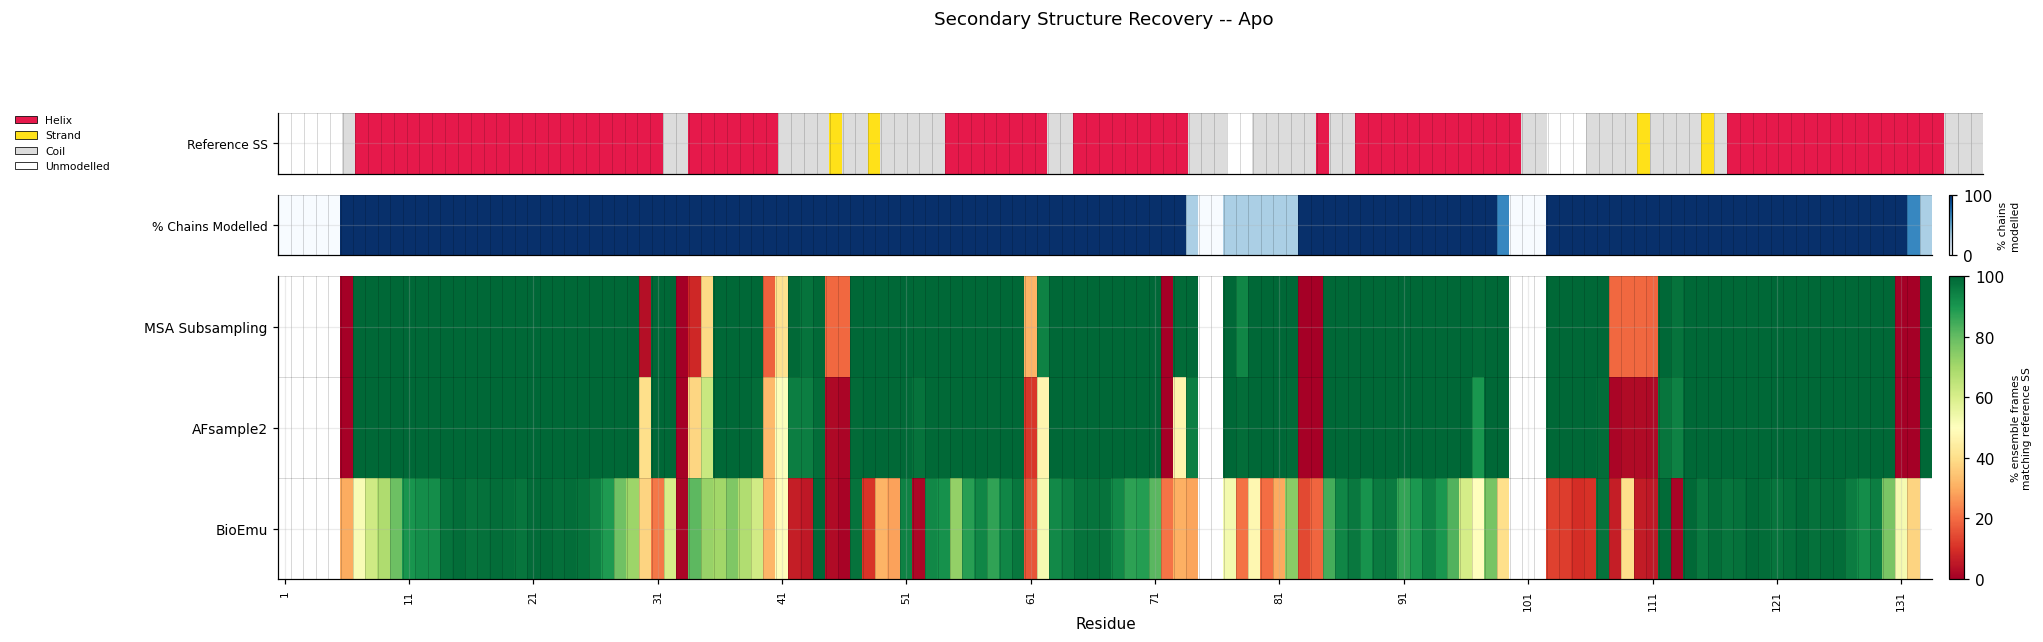

(n=4 pooled reference chains for this state)


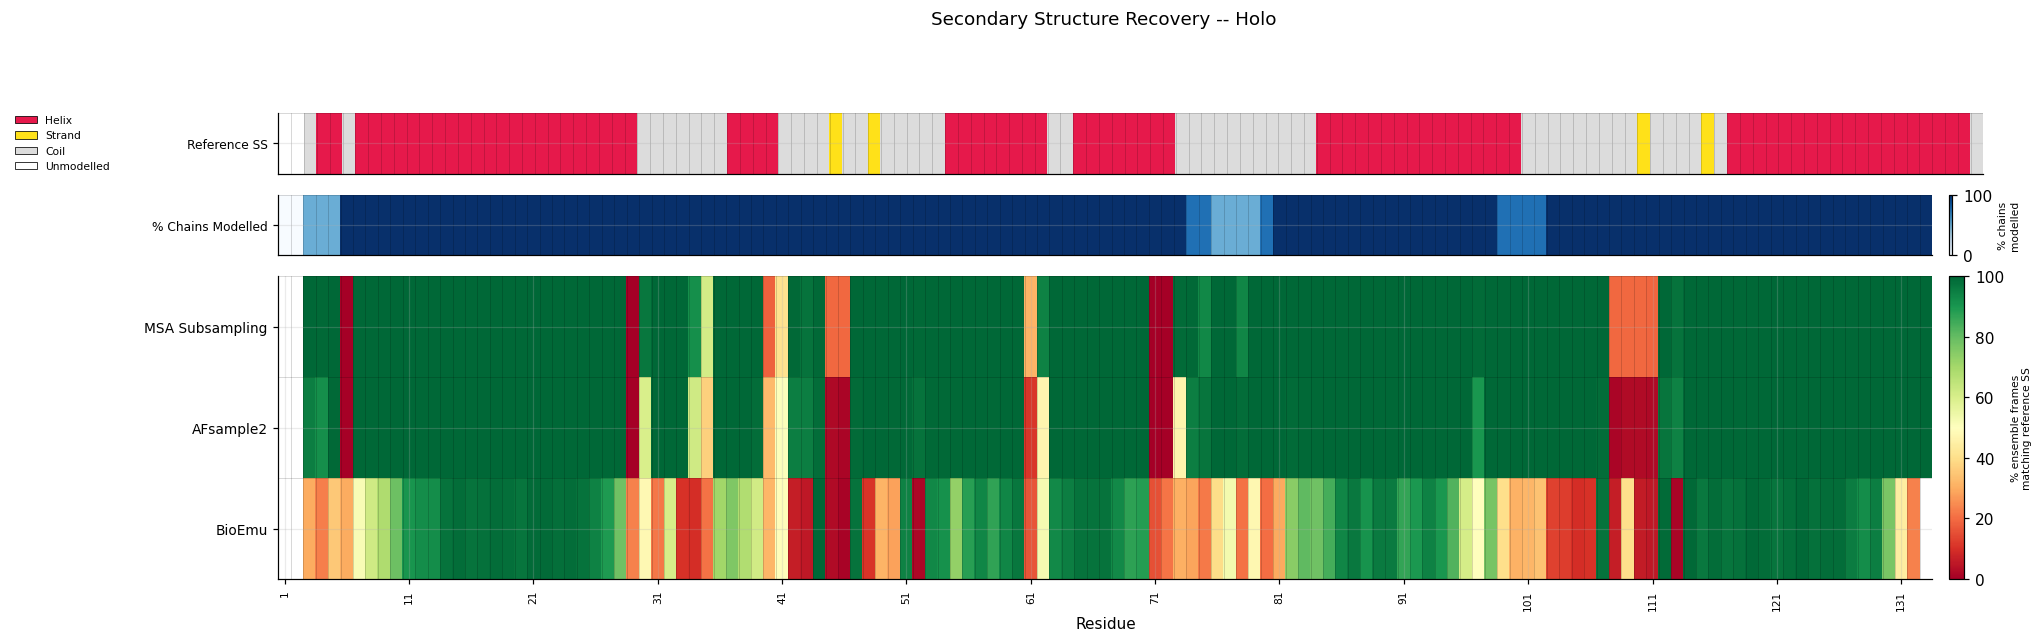

(n=10 pooled reference chains for this state)


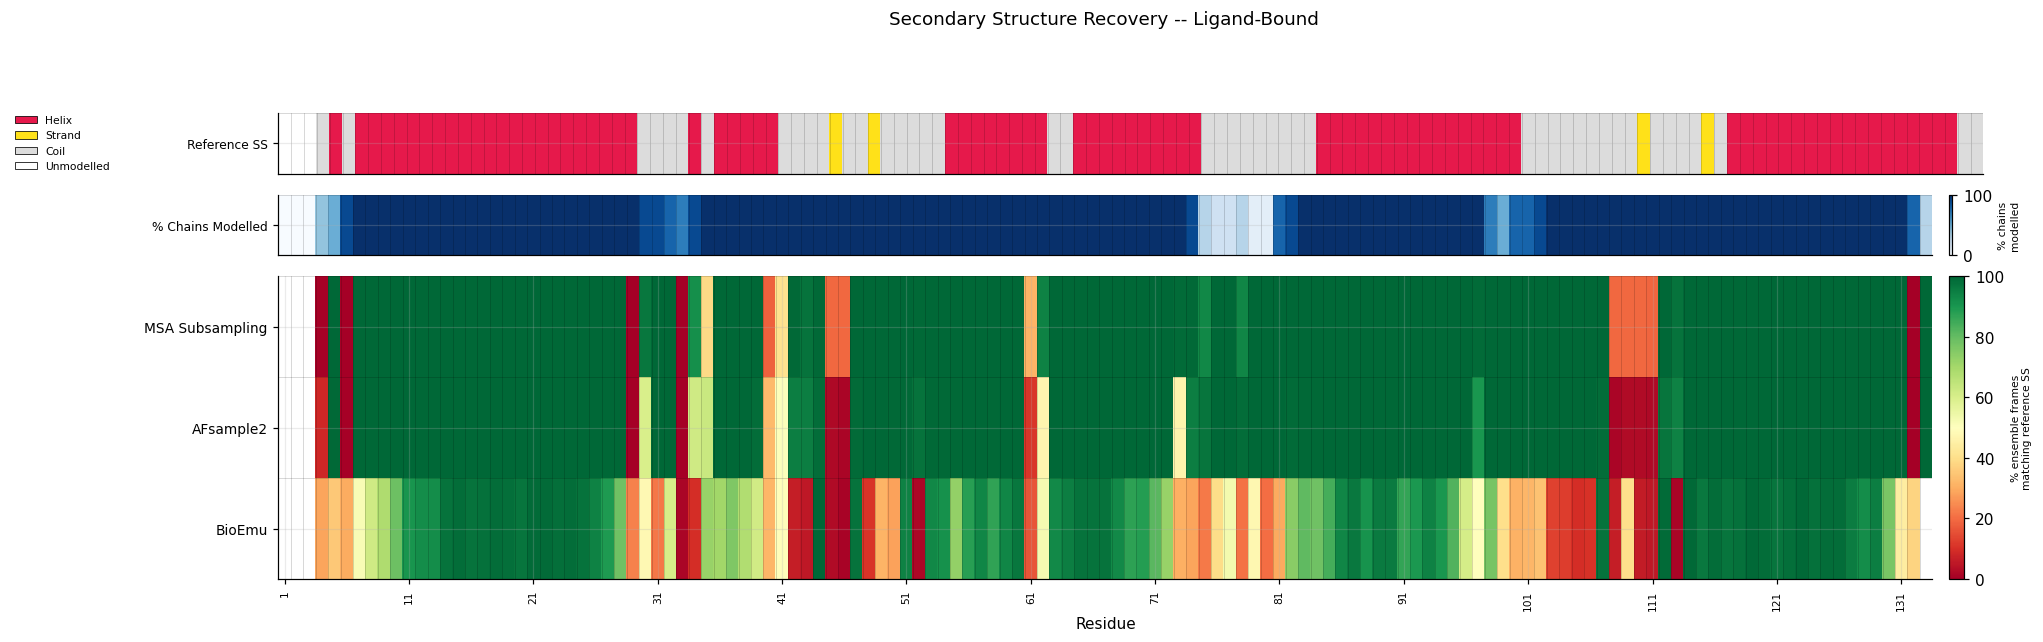

In [13]:
from collections import Counter
from matplotlib.colors import ListedColormap

SS_COLORS4 = {"H": "#e6194B", "E": "#ffe119", "C": "#dcdcdc", "U": "#ffffff"}
SS_CMAP4 = ListedColormap([SS_COLORS4["C"], SS_COLORS4["H"], SS_COLORS4["E"], SS_COLORS4["U"]])
SS_CODE4 = {"C": 0, "H": 1, "E": 2, "U": 3}


def reference_ss_consensus_with_coverage(state):
    """Majority-vote DSSP label per residue (same logic as reference_ss_consensus), plus
    per-residue 'involvement' -- the % of QC'd reference chains for this state that actually
    resolve that residue (non-NA DSSP call), out of every chain processed for that state."""
    votes = {}
    n_chains = 0
    for p in sorted(glob.glob(f"{STATE_DIRS[state]}/*.pdb")):
        pdb_id = os.path.basename(p).replace(".pdb", "")
        if pdb_id in EXCLUDED_PDB_IDS:
            continue
        for label, t in full_atom_single_chain_trajs(p):
            n_chains += 1
            for resSeq, lab in dssp_by_resSeq(t).items():
                if lab[0] != "NA":
                    votes.setdefault(resSeq, []).append(lab[0])
    consensus = {r: Counter(v).most_common(1)[0][0] for r, v in votes.items()}
    involvement = {r: 100.0 * len(v) / n_chains for r, v in votes.items()}
    return consensus, involvement, n_chains


def per_residue_agreement(resSeqs, ref_consensus, ss_by_res):
    """% of ensemble frames matching the reference consensus SS label, per residue. NaN
    where the reference has no modelled density there (unmodelled), or the model has no
    data for that residue."""
    pct = np.full(len(resSeqs), np.nan)
    for i, r in enumerate(resSeqs):
        ref_lab = ref_consensus.get(r)
        if ref_lab is None or r not in ss_by_res:
            continue
        labs = ss_by_res[r]
        valid = labs != "NA"
        if valid.sum() == 0:
            continue
        pct[i] = (labs[valid] == ref_lab).mean() * 100
    return pct


STATE_SHORT_TITLE = {"apo": "Apo", "holo": "Holo", "ligand": "Ligand-Bound"}

for state in STATES:
    ref_consensus, involvement, n_chains = reference_ss_consensus_with_coverage(state)
    resSeqs = list(range(1, 134))
    n = len(resSeqs)
    ref_codes = np.array([[SS_CODE4[ref_consensus.get(r, "U")] for r in resSeqs]])
    involve_row = np.array([[involvement.get(r, 0.0) for r in resSeqs]])

    agreement = np.vstack([
        per_residue_agreement(resSeqs, ref_consensus, msa_dssp),
        per_residue_agreement(resSeqs, ref_consensus, afs2_dssp),
        per_residue_agreement(resSeqs, ref_consensus, bio_dssp),
    ])

    fig, axes = plt.subplots(3, 1, figsize=(20, 5.5),
                              gridspec_kw={"height_ratios": [0.2, 0.2, 1], "hspace": 0.15})
    ax_ref, ax_inv, ax_hm = axes

    ax_ref.imshow(ref_codes, aspect="auto", cmap=SS_CMAP4, vmin=0, vmax=3)
    ax_ref.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax_ref.set_yticks(np.arange(-0.5, 1, 1), minor=True)
    ax_ref.grid(which="minor", color="black", linewidth=0.4)
    ax_ref.tick_params(which="minor", length=0)
    ax_ref.set_yticks([0]); ax_ref.set_yticklabels(["Reference SS"], fontsize=8)
    ax_ref.set_xticks([])

    im_inv = ax_inv.imshow(involve_row, aspect="auto", cmap="Blues", vmin=0, vmax=100)
    ax_inv.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax_inv.set_yticks(np.arange(-0.5, 1, 1), minor=True)
    ax_inv.grid(which="minor", color="black", linewidth=0.4)
    ax_inv.tick_params(which="minor", length=0)
    ax_inv.set_yticks([0]); ax_inv.set_yticklabels(["% Chains Modelled"], fontsize=8)
    ax_inv.set_xticks([])

    im = ax_hm.imshow(agreement, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
    ax_hm.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax_hm.set_yticks(np.arange(-0.5, 3, 1), minor=True)
    ax_hm.grid(which="minor", color="black", linewidth=0.4)
    ax_hm.tick_params(which="minor", length=0)
    ax_hm.set_yticks([0, 1, 2])
    ax_hm.set_yticklabels(MODEL_NAMES, fontsize=9)
    tick_pos = list(range(0, n, 10))
    ax_hm.set_xticks(tick_pos)
    ax_hm.set_xticklabels([resSeqs[i] for i in tick_pos], fontsize=7, rotation=90)
    ax_hm.set_xlabel("Residue")

    cbar1 = fig.colorbar(im_inv, ax=ax_inv, location="right", fraction=0.02, pad=0.01)
    cbar1.set_label("% chains\nmodelled", fontsize=7)
    cbar2 = fig.colorbar(im, ax=ax_hm, location="right", fraction=0.02, pad=0.01)
    cbar2.set_label("% ensemble frames\nmatching reference SS", fontsize=7)

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=SS_COLORS4[k], edgecolor="black", linewidth=0.5)
               for k in ["H", "E", "C", "U"]]
    ax_ref.legend(handles, ["Helix", "Strand", "Coil", "Unmodelled"], loc="center left",
                  bbox_to_anchor=(-0.16, 0.5), fontsize=7, frameon=False)

    fig.suptitle(f"Secondary Structure Recovery -- {STATE_SHORT_TITLE[state]}", fontsize=12, y=1.05)
    print(f"(n={n_chains} pooled reference chains for this state)")
    plt.savefig(f"../outputs/figures/ss_recovery_heatmap_{state}.png", dpi=150, bbox_inches="tight")
    plt.show()




**Interpretation.** The heatmaps above show, per residue, whether each model's ensemble
(pooled across all its structures) reproduces the reference-consensus fold at that position, and
how many reference chains actually resolve that residue (the "% chains modelled" row) -- a
residue with low reference coverage makes for a noisier consensus label regardless of how well a
model recovers it. The segment-level table below aggregates this by named secondary-structure
element rather than by individual residue.

In [14]:
SS_NAME = {"H": "Helix", "E": "Strand", "C": "Coil"}

def ss_segments(resSeqs, ref_consensus):
    """Run-length-encode the reference consensus SS string into contiguous segments.
    Breaks on both an SS-type change and a gap in resSeqs (an unresolved stretch), so every
    reported range is truly contiguous in real residue numbering."""
    segments = []
    seg_start = resSeqs[0]
    seg_type = ref_consensus[resSeqs[0]]
    prev = resSeqs[0]
    for r in resSeqs[1:]:
        if not (ref_consensus[r] == seg_type and r == prev + 1):
            segments.append((seg_type, seg_start, prev))
            seg_start, seg_type = r, ref_consensus[r]
        prev = r
    segments.append((seg_type, seg_start, prev))
    return segments

def ss_segment_table(state):
    ref_consensus = reference_ss_consensus(state)
    resSeqs = sorted(ref_consensus)
    resSeq_to_i = {r: i for i, r in enumerate(resSeqs)}
    pct_by_model = {
        "MSA Subsampling": per_residue_agreement(resSeqs, ref_consensus, msa_dssp),
        "AFsample2": per_residue_agreement(resSeqs, ref_consensus, afs2_dssp),
        "BioEmu": per_residue_agreement(resSeqs, ref_consensus, bio_dssp),
    }
    rows = []
    for ss_type, start, end in ss_segments(resSeqs, ref_consensus):
        idxs = [resSeq_to_i[r] for r in range(start, end + 1) if r in resSeq_to_i]
        row = dict(state=STATE_LABELS[state], type=SS_NAME[ss_type],
                   range=f"{start}-{end}", length=len(idxs))
        for model, pct in pct_by_model.items():
            row[f"{model} % recovered"] = round(float(np.nanmean(pct[idxs])), 1)
        rows.append(row)
    return pd.DataFrame(rows)

ss_segment_df = pd.concat([ss_segment_table(state) for state in STATES], ignore_index=True)
ss_segment_df = ss_segment_df.rename(columns={"state": "State", "type": "Element", "range": "Residue Range", "length": "Length (residues)"})
print(ss_segment_df.to_markdown(index=False))


| State                         | Element   | Residue Range   |   Length (residues) |   MSA Subsampling % recovered |   AFsample2 % recovered |   BioEmu % recovered |
|:------------------------------|:----------|:----------------|--------------------:|------------------------------:|------------------------:|---------------------:|
| Apo (unbound)                 | Coil      | 6-6             |                   1 |                           0   |                     0.5 |                 29.9 |
| Apo (unbound)                 | Helix     | 7-30            |                  24 |                          96   |                    97.5 |                 86.8 |
| Apo (unbound)                 | Coil      | 31-32           |                   2 |                         100   |                   100   |                 41   |
| Apo (unbound)                 | Helix     | 33-39           |                   7 |                          63.9 |                    71.4 |                 61.5 

/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/244502830.py:34: RuntimeWarning: Mean of empty slice
  row[f"{model} % recovered"] = round(float(np.nanmean(pct[idxs])), 1)


### Cα RMSD of Predicted Ensembles to Reference (Three-Way)

A fair three-way comparison cannot lean on each model's *native* confidence output: MSA
Subsampling exposes full pLDDT + pTM + PAE, AFsample2 exposes only mean pLDDT (read off the PDB
B-factor column), and BioEmu -- a diffusion-based equilibrium sampler, not a single-shot
predictor with a confidence head -- exposes none at all. Comparing "confidence" across the three
would really be comparing three different, non-comparable things. Instead, one metric is
computed identically for all three: **Cα RMSD to the nearest reference conformer**, after Kabsch
(optimal rigid-body) superposition,

**RMSD = √( (1/L) Σᵢ₌₁ᴸ |xᵢ − xᵢʳᵉᶠ|² )**

where *L* is the state's common resolved reference core and *xᵢ*, *xᵢʳᵉᶠ* are the aligned Cα
coordinates of the predicted and reference structures. For each predicted frame, RMSD is
computed against **every** reference chain in that state, each independently superposed, and the
**minimum** is kept -- how close does this predicted structure get to the single most similar
resolved reference conformation.

In [15]:
rmsd_scores = {"MSA Subsampling": {}, "AFsample2": {}, "BioEmu": {}}
print("Ca RMSD (Angstrom) to nearest reference conformer, per state (Kabsch-superposed):")
for state in STATES:
    resid_list = common_resSeqs(ref_trajs[state])
    ref_sliced = stack_trajs([slice_to_resSeqs(t, set(resid_list)) for t in ref_trajs[state]])
    msa_sliced_tm = slice_to_resSeqs(msa_traj, set(resid_list))
    afs2_sliced_tm = slice_to_resSeqs(afs2_traj, set(resid_list))
    bio_sliced_tm = slice_to_resSeqs(bio_traj, set(resid_list))

    rmsd_scores["MSA Subsampling"][state] = rmsd_to_nearest(msa_sliced_tm, ref_sliced)
    rmsd_scores["AFsample2"][state] = rmsd_to_nearest(afs2_sliced_tm, ref_sliced)
    rmsd_scores["BioEmu"][state] = rmsd_to_nearest(bio_sliced_tm, ref_sliced)

    print(f"{state:8s}: over {len(resid_list)} common residues -- "
          f"MSA Subsampling mean={rmsd_scores['MSA Subsampling'][state].mean():.2f} A, "
          f"AFsample2 mean={rmsd_scores['AFsample2'][state].mean():.2f} A, "
          f"BioEmu mean={rmsd_scores['BioEmu'][state].mean():.2f} A")

# Pooled across all three states into one row per model -- "Between-State SD" is a distinct
# statistic from "+/- SD": it's the spread of each state's OWN mean RMSD around the model's
# overall mean (i.e. how consistent the model is apo vs holo vs ligand), not the frame-to-
# frame spread within the pooled ensemble (which "+/- SD" already captures).
rmsd_pooled_rows = []
for model in MODEL_NAMES:
    per_state_means = np.array([rmsd_scores[model][state].mean() for state in STATES])
    pooled = np.concatenate([rmsd_scores[model][state] for state in STATES])
    rmsd_pooled_rows.append(dict(
        model=model,
        mean_RMSD=round(float(pooled.mean()), 2),
        std_RMSD=round(float(pooled.std()), 2),
        median_RMSD=round(float(np.median(pooled)), 2),
        pct_RMSD_le_2A=round(float((pooled <= 2.0).mean() * 100), 1),
        between_state_sd=round(float(per_state_means.std()), 2),
    ))

rmsd_df = pd.DataFrame(rmsd_pooled_rows)
rmsd_df = rmsd_df.rename(columns={
    "model": "Model", "mean_RMSD": "Mean RMSD (A)", "std_RMSD": "± SD",
    "median_RMSD": "Median RMSD (A)", "pct_RMSD_le_2A": "% RMSD ≤ 2 A",
    "between_state_sd": "Between-State SD",
})
print(rmsd_df.to_markdown(index=False))



Ca RMSD (Angstrom) to nearest reference conformer, per state (Kabsch-superposed):
apo     : over 113 common residues -- MSA Subsampling mean=0.89 A, AFsample2 mean=1.12 A, BioEmu mean=2.13 A
holo    : over 117 common residues -- MSA Subsampling mean=1.10 A, AFsample2 mean=1.34 A, BioEmu mean=2.30 A
ligand  : over 106 common residues -- MSA Subsampling mean=0.70 A, AFsample2 mean=0.95 A, BioEmu mean=1.87 A
| Model           |   Mean RMSD (A) |   ± SD |   Median RMSD (A) |   % RMSD ≤ 2 A |   Between-State SD |
|:----------------|----------------:|-------:|------------------:|---------------:|-------------------:|
| MSA Subsampling |            0.89 |   0.26 |              0.85 |           99.7 |               0.17 |
| AFsample2       |            1.14 |   0.44 |              1.03 |           96   |               0.16 |
| BioEmu          |            2.1  |   0.74 |              1.97 |           52.4 |               0.18 |


### RMSD Coverage

Reference-state coverage measures the proportion of reference conformations effectively
recovered by the nearest ensemble member, by classifying every predicted structure's
Kabsch-superposed Cα RMSD to its nearest reference chain into 1 Å-wide bands: **indistinguishable**
(0–1 Å), **displaced but similar** (1–2 Å), **distinct state** (2–3 Å), and three further bands
out to >5 Å. This is the structural-fidelity half of the research question made concrete: of the
structures each model produces, how close does the best of them get to a real, resolved
conformation?

/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/881284869.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=0, fontsize=8)
/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/881284869.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=0, fontsize=8)
/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/881284869.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=0, fontsize=8)


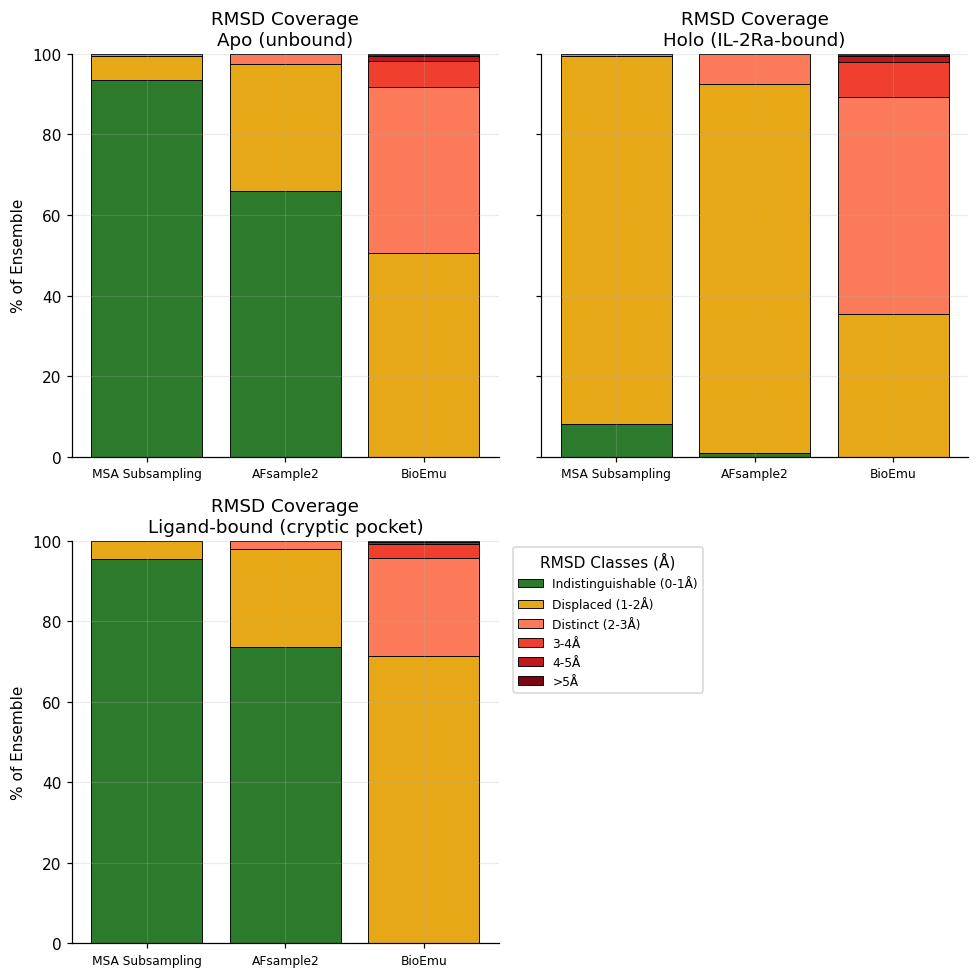

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharey=True)
_plot_axes = [axes[0, 0], axes[0, 1], axes[1, 0]]
axes[1, 1].axis("off")

rmsd_bin_edges = [0, 1, 2, 3, 4, 5, np.inf]
rmsd_bin_labels = ["Indistinguishable (0-1Å)", "Displaced (1-2Å)", "Distinct (2-3Å)",
                    "3-4Å", "4-5Å", ">5Å"]

rmsd_bin_colors = {"Indistinguishable (0-1Å)": "#2c7a2c", "Displaced (1-2Å)": "#e6a817"}
rmsd_bin_colors.update(dict(zip(["Distinct (2-3Å)", "3-4Å", "4-5Å", ">5Å"],
                                 plt.cm.Reds(np.linspace(0.45, 0.95, 4)))))

model_rmsd_by_name = rmsd_scores  # {model: {state: array}}, built in Section 1b -- was a stale {"MSA Subsampling": msa_rmsd, ...} literal referencing three names never defined anywhere

def rmsd_bin_coverage(rmsd_arr):
    binned = pd.Series(pd.cut(rmsd_arr, bins=rmsd_bin_edges, labels=rmsd_bin_labels, right=True, include_lowest=True))
    return binned.value_counts(normalize=True).reindex(rmsd_bin_labels).fillna(0.0) * 100


for ax, state in zip(_plot_axes, STATES):
    state_label = STATE_LABELS[state]
    coverage = pd.DataFrame({name: rmsd_bin_coverage(model_rmsd_by_name[name][state]) for name in MODEL_NAMES}).T
    coverage = coverage.reindex(MODEL_NAMES)
    bottom = np.zeros(len(coverage))
    for label in rmsd_bin_labels:
        vals = coverage[label].values
        ax.bar(MODEL_NAMES, vals, bottom=bottom, color=rmsd_bin_colors[label], label=label,
               edgecolor="black", linewidth=0.6)
        bottom += vals
    ax.set_title(f"RMSD Coverage\n{state_label}")
    ax.set_xticklabels(MODEL_NAMES, rotation=0, fontsize=8)

axes[0, 0].set_ylabel("% of Ensemble")
axes[1, 0].set_ylabel("% of Ensemble")
_plot_axes[-1].legend(title="RMSD Classes (Å)", fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.subplots_adjust(wspace=0.10)
plt.savefig("../outputs/figures/rmsd_coverage_5bin.png", dpi=150, bbox_inches="tight")
plt.show()




In [17]:
rows = []
for state in STATES:
    for name in MODEL_NAMES:
        frac = rmsd_bin_coverage(model_rmsd_by_name[name][state])
        rows.append(dict(state=STATE_LABELS[state], model=name, **frac.round(1).to_dict()))
rmsd_coverage_df = pd.DataFrame(rows).rename(columns={"state": "State", "model": "Model"})
print(rmsd_coverage_df.to_markdown(index=False))


| State                         | Model           |   Indistinguishable (0-1Å) |   Displaced (1-2Å) |   Distinct (2-3Å) |   3-4Å |   4-5Å |   >5Å |
|:------------------------------|:----------------|---------------------------:|-------------------:|------------------:|-------:|-------:|------:|
| Apo (unbound)                 | MSA Subsampling |                       93.5 |                6   |               0.5 |    0   |    0   |   0   |
| Apo (unbound)                 | AFsample2       |                       66   |               31.5 |               2.5 |    0   |    0   |   0   |
| Apo (unbound)                 | BioEmu          |                        0   |               50.5 |              41.3 |    6.5 |    1.3 |   0.4 |
| Holo (IL-2Ra-bound)           | MSA Subsampling |                        8   |               91.5 |               0.5 |    0   |    0   |   0   |
| Holo (IL-2Ra-bound)           | AFsample2       |                        1   |               91.5 |           

## 2.2. Conformational Diversity

**RQ link:** this is the second defining axis of biological relevance. A model that is accurate
on average but narrow is not a better answer to the research question than one that is noisier
but complete -- this section is what tells those two failure modes apart, using the same
reference-anchored PCA basis throughout.

### 2.2a. Per-State Reference-Basis PCA & Projection

For each state, a PCA basis is built from that state's pooled reference ensemble alone (the
common resolved core, superposed onto its own mean shape). All three model ensembles are then
projected onto this fixed, state-specific basis, so a structure's position is always read off
axes defined by real crystallographic structures, not by the predicted data itself. Axes are
shared *within* a state (across the reference and all three models) but not *across* states,
since each state's basis is refit independently.

In [18]:
pca_basis = {}
msa_scores, afs2_scores, bio_scores = {}, {}, {}
msa_sliced, afs2_sliced, bio_sliced = {}, {}, {}
state_axes = {}

for state in STATES:
    basis = fit_state_pca(ref_trajs[state])
    pca_basis[state] = basis
    msa_scores[state], msa_sliced[state] = project_onto_pca(msa_traj, basis)
    afs2_scores[state], afs2_sliced[state] = project_onto_pca(afs2_traj, basis)
    bio_scores[state], bio_sliced[state] = project_onto_pca(bio_traj, basis)
    if basis["pca"] is None:
        print(f"{state:8s}: only {basis['ref_traj'].n_frames} reference chain(s) after QC "
              f"filtering -- insufficient for a 2D PCA basis (need >=3); PCA/hull rankings "
              f"skipped for this state below (RMSD/coverage/chi1/pocket-volume unaffected).")
        state_axes[state] = None
    else:
        print(f"{state:8s}: {len(basis['resid_list']):3d} common resolved residues "
              f"({basis['resid_list'][0]}-{basis['resid_list'][-1]}), "
              f"PC1+PC2 explained variance = {basis['pca'].explained_variance_ratio_.sum()*100:.1f}%")
        state_axes[state] = shared_axes_limits(
            [basis["ref_scores"], msa_scores[state], afs2_scores[state], bio_scores[state]])

apo     : 113 common resolved residues (6-131), PC1+PC2 explained variance = 100.0%
holo    : 117 common resolved residues (6-133), PC1+PC2 explained variance = 98.0%
ligand  : 106 common resolved residues (7-131), PC1+PC2 explained variance = 62.2%


In [19]:
# Diagnostic: was a single pooled (apo+holo+ligand) PCA basis considered instead of one per
# state? Yes -- tried below. Verdict: pooling captures LESS 2D variance than any per-state
# basis (see numbers above), so the per-state design in the loop above is kept.
all_ref_trajs = [t for state in STATES for t in ref_trajs[state]]
pooled_resid_list = common_resSeqs(all_ref_trajs)
pooled_sliced = [slice_to_resSeqs(t, set(pooled_resid_list)) for t in all_ref_trajs]
pooled_ref_traj = stack_trajs(pooled_sliced)

pooled_ref_traj.superpose(pooled_ref_traj, frame=0)
pooled_mean_traj = md.Trajectory(xyz=pooled_ref_traj.xyz.mean(axis=0, keepdims=True),
                                  topology=pooled_ref_traj.topology)
pooled_ref_traj.superpose(pooled_mean_traj, frame=0)

X_pooled = pooled_ref_traj.xyz.reshape(pooled_ref_traj.n_frames, -1)
pooled_pca = PCA(n_components=2)
pooled_pca.fit(X_pooled - X_pooled.mean(axis=0))

print(f"Pooled (apo+holo+ligand) basis: {len(pooled_resid_list)} common residues, "
      f"n_chains={len(all_ref_trajs)}, PC1+PC2 explained variance = "
      f"{pooled_pca.explained_variance_ratio_.sum()*100:.1f}%")
print("--> lower than every per-state basis above; per-state fitting kept for the plots below.")


Pooled (apo+holo+ligand) basis: 106 common residues, n_chains=17, PC1+PC2 explained variance = 47.4%
--> lower than every per-state basis above; per-state fitting kept for the plots below.


/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/3957331099.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for depth, sub in msa_meta_idx.groupby("msa_depth"):
/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/3957331099.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for frac, sub in afs2_meta_idx.groupby("dropout_rate"):


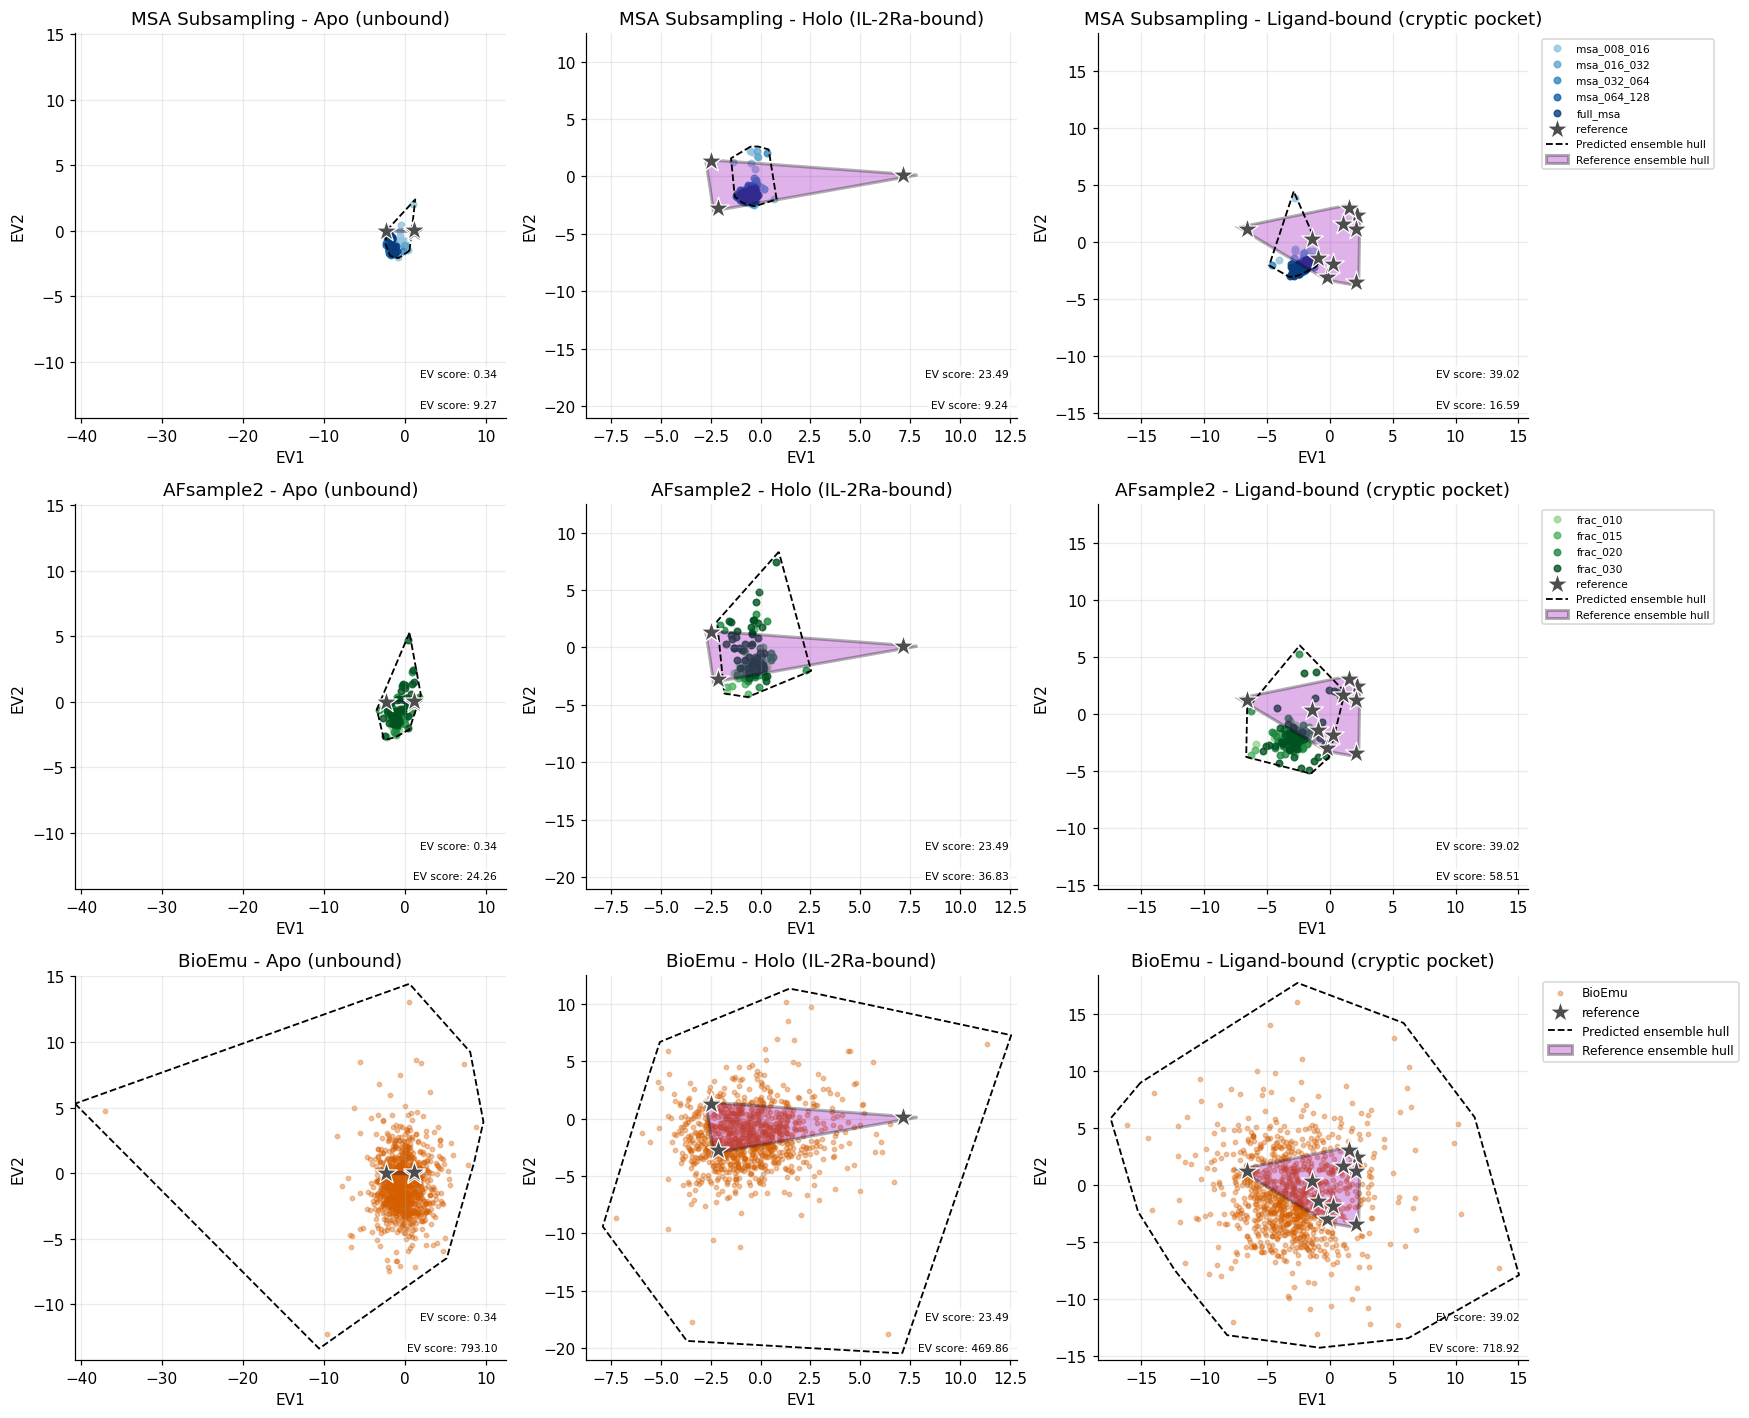

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
depth_colors = dict(zip(MSA_ORDER, plt.cm.Blues(np.linspace(0.4, 0.95, len(MSA_ORDER)))))
dropout_colors = dict(zip(DROPOUT_ORDER, plt.cm.Greens(np.linspace(0.4, 0.95, len(DROPOUT_ORDER)))))
REF_HULL_COLOR = "#9600b8"  # mild purple



def draw_hull_polygon(ax, scores_2d, color="black", label=None, expansion_factor=1.1,
                       show_area=True, fill=False):
    """Draw the actual convex hull (in the EV1-EV2 plane, expanded by `expansion_factor`
    about the centroid -- same construction as convex_hull_ev_score). Predicted-ensemble
    hulls are drawn as a dashed outline (fill=False, default); the reference-ensemble hull
    is drawn as a filled, outlined area (fill=True) so the two read as visually distinct
    categories rather than two dashed lines of different colors."""
    centroid = scores_2d.mean(axis=0)
    expanded = centroid + (scores_2d - centroid) * expansion_factor
    hull = ConvexHull(expanded)
    vertices = expanded[hull.vertices]
    polygon = np.vstack([vertices, vertices[:1]])  # close the loop
    if fill:
        ax.fill(polygon[:, 0], polygon[:, 1], facecolor=color, edgecolor="black",
                alpha=0.3, linewidth=2.0, zorder=3, label=label)
    else:
        ax.plot(polygon[:, 0], polygon[:, 1], linestyle="--", color=color, linewidth=1.2, zorder=4, label=label)
    if show_area:
        y_pos = 0.02 if color == "black" else 0.10
        text_color = "black" if fill else color
        ax.text(0.98, y_pos, f"EV score: {hull.volume:.2f}", ha="right", va="bottom",
                fontsize=7, color=text_color, transform=ax.transAxes,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none"))

for j, state in enumerate(STATES):
    basis = pca_basis[state]
    degenerate = basis["pca"] is None

    ax = axes[0, j]
    if degenerate:
        ax.text(0.5, 0.5, "PCA skipped\n(< 3 reference chains)", ha="center", va="center", transform=ax.transAxes)
    else:
        for depth, sub in msa_meta_idx.groupby("msa_depth"):
            idx = sub.index.values
            ax.scatter(msa_scores[state][idx, 0], msa_scores[state][idx, 1],
                       s=18, alpha=0.8, color=depth_colors[depth], label=depth)
        ax.scatter(basis["ref_scores"][:, 0], basis["ref_scores"][:, 1], marker="*", s=220,
                   color=COLOR_REF, edgecolor="white", linewidth=0.8, zorder=5, label="reference")
        draw_hull_polygon(ax, msa_scores[state], color="black", label="Predicted ensemble hull")
        draw_hull_polygon(ax, basis["ref_scores"], color=REF_HULL_COLOR, label="Reference ensemble hull", fill=True)
        ax.set_xlim(state_axes[state][0]); ax.set_ylim(state_axes[state][1])
        ax.set_xlabel("EV1"); ax.set_ylabel("EV2")
        if j == 2:
            ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.set_title(f"MSA Subsampling - {STATE_LABELS[state]}")

    ax = axes[1, j]
    if degenerate:
        ax.text(0.5, 0.5, "PCA skipped\n(< 3 reference chains)", ha="center", va="center", transform=ax.transAxes)
    else:
        for frac, sub in afs2_meta_idx.groupby("dropout_rate"):
            idx = sub.index.values
            ax.scatter(afs2_scores[state][idx, 0], afs2_scores[state][idx, 1],
                       s=18, alpha=0.8, color=dropout_colors[frac], label=frac)
        ax.scatter(basis["ref_scores"][:, 0], basis["ref_scores"][:, 1], marker="*", s=220,
                   color=COLOR_REF, edgecolor="white", linewidth=0.8, zorder=5, label="reference")
        draw_hull_polygon(ax, afs2_scores[state], color="black", label="Predicted ensemble hull")
        draw_hull_polygon(ax, basis["ref_scores"], color=REF_HULL_COLOR, label="Reference ensemble hull", fill=True)
        ax.set_xlim(state_axes[state][0]); ax.set_ylim(state_axes[state][1])
        ax.set_xlabel("EV1"); ax.set_ylabel("EV2")
        if j == 2:
            ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.set_title(f"AFsample2 - {STATE_LABELS[state]}")

    ax = axes[2, j]
    if degenerate:
        ax.text(0.5, 0.5, "PCA skipped\n(< 3 reference chains)", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.scatter(bio_scores[state][:, 0], bio_scores[state][:, 1], s=8, alpha=0.35,
                   color=COLOR_BIO, label="BioEmu")
        ax.scatter(basis["ref_scores"][:, 0], basis["ref_scores"][:, 1], marker="*", s=220,
                   color=COLOR_REF, edgecolor="white", linewidth=0.8, zorder=5, label="reference")
        draw_hull_polygon(ax, bio_scores[state], color="black", label="Predicted ensemble hull")
        draw_hull_polygon(ax, basis["ref_scores"], color=REF_HULL_COLOR, label="Reference ensemble hull", fill=True)
        ax.set_xlim(state_axes[state][0]); ax.set_ylim(state_axes[state][1])
        ax.set_xlabel("EV1"); ax.set_ylabel("EV2")
        if j == 2:
            ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    ax.set_title(f"BioEmu - {STATE_LABELS[state]}")

plt.tight_layout()
plt.savefig("../outputs/figures/pca_projections.png", dpi=150, bbox_inches="tight")
plt.show()




**Furthest-from-centroid seeds, apo state.** The panel below highlights, per model, the
single structure furthest from that model's own ensemble centroid in apo-basis PCA space --
included here (rather than only in Section 4) since it is the structure exported below for
display in the write-up.

In [21]:
from pdbfixer import PDBFixer
from openmm import app

_furthest_state = "apo"
_furthest_out_dir = "../outputs/figures"  # same directory as the plot above

# BioEmu is exported separately, further down (right after Section 6's side-chain grafting) --
# bio_traj_full (the full-atom, grafted-side-chain reconstruction PDBFixer needs) doesn't exist
# yet at this point in the notebook; it depends on POCKET_LINING_RESIDUES/GATING_RESIDUES,
# which are only computed in Section 6a, well after this cell.
_ensembles_for_furthest = {
    "MSA Subsampling": (msa_scores[_furthest_state], msa_traj_full, msa_meta_idx["source"].tolist()),
    "AFsample2": (afs2_scores[_furthest_state], afs2_traj_full, afs2_meta_idx["source"].tolist()),
}

furthest_structure_rows = []
for _name, (_scores, _full_traj, _labels) in _ensembles_for_furthest.items():
    _centroid = _scores.mean(axis=0)  # swap for pca_basis[_furthest_state]["ref_scores"].mean(axis=0)
                                        # here if you meant furthest-from-reference instead
    _, _idx = top5_by_distance_to_point(_scores, _centroid, _labels, ascending=False)
    _furthest_i = int(_idx[0])
    _dist = float(np.linalg.norm(_scores[_furthest_i] - _centroid))

    _raw_path = f"{_furthest_out_dir}/{_name.replace(' ', '_')}_apo_furthest_raw.pdb"
    save_pdb_from_angstrom(_full_traj[_furthest_i], _raw_path)

    _fixed_path = f"{_furthest_out_dir}/{_name.replace(' ', '_')}_apo_furthest_fixed.pdb"
    fixer = PDBFixer(filename=_raw_path)
    fixer.findMissingResidues()
    fixer.missingResidues = {}  # keep the structure's own geometry as-is, don't model in loops
    fixer.findNonstandardResidues()
    fixer.replaceNonstandardResidues()
    fixer.removeHeterogens(keepWater=False)
    fixer.findMissingAtoms()
    fixer.addMissingAtoms()
    fixer.addMissingHydrogens(7.0)
    with open(_fixed_path, "w") as fh:
        app.PDBFile.writeFile(fixer.topology, fixer.positions, fh)

    furthest_structure_rows.append(dict(model=_name, source=_labels[_furthest_i], frame_idx=_furthest_i,
                                          distance_to_centroid=round(_dist, 3), raw_path=_raw_path,
                                          fixed_path=_fixed_path))

furthest_structure_df = pd.DataFrame(furthest_structure_rows)
furthest_structure_df

,model,source,frame_idx,distance_to_centroid,raw_path,fixed_path
0,MSA Subsampling,MSA:msa_008_016:rank040_model2_seed3,79,4.173,../outputs/figures/MSA_Subsampling_apo_furthes...,../outputs/figures/MSA_Subsampling_apo_furthes...
1,AFsample2,AFS2:frac_030:model1_pred6,156,5.856,../outputs/figures/AFsample2_apo_furthest_raw.pdb,../outputs/figures/AFsample2_apo_furthest_fixe...


/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/1688473961.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for depth, sub in msa_meta_idx.groupby("msa_depth"):
/var/folders/kh/k4gl00092_d65yb6s2btkznr0000gn/T/ipykernel_6686/1688473961.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for frac, sub in afs2_meta_idx.groupby("dropout_rate"):


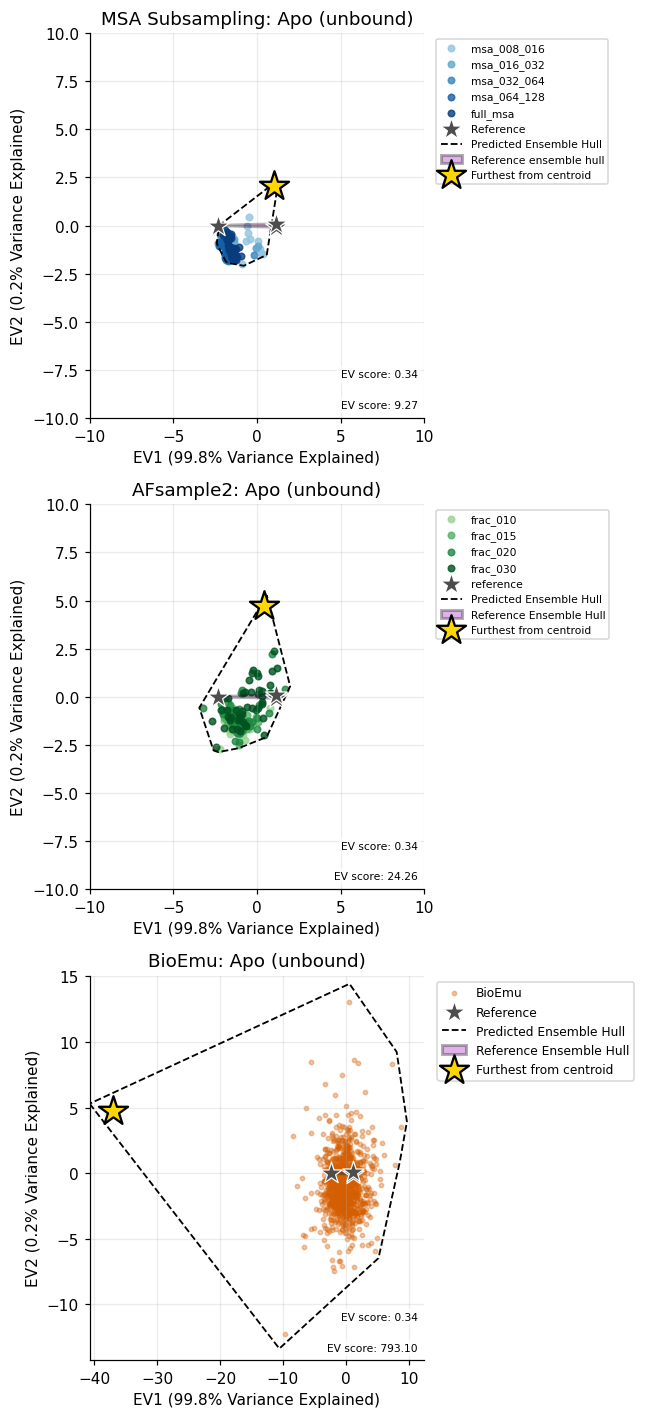

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(6, 13))
_state = "apo"
_basis = pca_basis[_state]
_degenerate = _basis["pca"] is None
_custom_xlim, _custom_ylim = (-10, 10), (-10, 10)
if not _degenerate:
    _pc1_pct, _pc2_pct = _basis["pca"].explained_variance_ratio_[:2] * 100


def _highlight_furthest(ax, scores_2d, labels):
    """Same 'furthest from own ensemble centroid' definition used by furthest_structure_df --
    marks it distinctly (gold star, black edge) so it's identifiable at a glance."""
    _centroid = scores_2d.mean(axis=0)
    _, _idx = top5_by_distance_to_point(scores_2d, _centroid, labels, ascending=False)
    _furthest_i = int(_idx[0])
    ax.scatter(scores_2d[_furthest_i, 0], scores_2d[_furthest_i, 1], marker="*", s=400,
               facecolor="gold", edgecolor="black", linewidth=1.5, zorder=6,
               label="Furthest from centroid")


ax = axes[0]
if _degenerate:
    ax.text(0.5, 0.5, "PCA skipped\n(< 3 reference chains)", ha="center", va="center", transform=ax.transAxes)
else:
    for depth, sub in msa_meta_idx.groupby("msa_depth"):
        idx = sub.index.values
        ax.scatter(msa_scores[_state][idx, 0], msa_scores[_state][idx, 1],
                   s=18, alpha=0.8, color=depth_colors[depth], label=depth)
    ax.scatter(_basis["ref_scores"][:, 0], _basis["ref_scores"][:, 1], marker="*", s=220,
               color=COLOR_REF, edgecolor="white", linewidth=0.8, zorder=5, label="Reference")
    draw_hull_polygon(ax, msa_scores[_state], color="black", label="Predicted Ensemble Hull")
    draw_hull_polygon(ax, _basis["ref_scores"], color=REF_HULL_COLOR, label="Reference ensemble hull", fill=True)
    _highlight_furthest(ax, msa_scores[_state], msa_meta_idx["source"].tolist())
    ax.set_xlim(_custom_xlim); ax.set_ylim(_custom_ylim)
    ax.set_xlabel(f"EV1 ({_pc1_pct:.1f}% Variance Explained)")
    ax.set_ylabel(f"EV2 ({_pc2_pct:.1f}% Variance Explained)")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title(f"MSA Subsampling: {STATE_LABELS[_state]}")

ax = axes[1]
if _degenerate:
    ax.text(0.5, 0.5, "PCA skipped\n(< 3 reference chains)", ha="center", va="center", transform=ax.transAxes)
else:
    for frac, sub in afs2_meta_idx.groupby("dropout_rate"):
        idx = sub.index.values
        ax.scatter(afs2_scores[_state][idx, 0], afs2_scores[_state][idx, 1],
                   s=18, alpha=0.8, color=dropout_colors[frac], label=frac)
    ax.scatter(_basis["ref_scores"][:, 0], _basis["ref_scores"][:, 1], marker="*", s=220,
               color=COLOR_REF, edgecolor="white", linewidth=0.8, zorder=5, label="reference")
    draw_hull_polygon(ax, afs2_scores[_state], color="black", label="Predicted Ensemble Hull")
    draw_hull_polygon(ax, _basis["ref_scores"], color=REF_HULL_COLOR, label="Reference Ensemble Hull", fill=True)
    _highlight_furthest(ax, afs2_scores[_state], afs2_meta_idx["source"].tolist())
    ax.set_xlim(_custom_xlim); ax.set_ylim(_custom_ylim)
    ax.set_xlabel(f"EV1 ({_pc1_pct:.1f}% Variance Explained)")
    ax.set_ylabel(f"EV2 ({_pc2_pct:.1f}% Variance Explained)")
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title(f"AFsample2: {STATE_LABELS[_state]}")

ax = axes[2]
if _degenerate:
    ax.text(0.5, 0.5, "PCA skipped\n(< 3 Reference Chains)", ha="center", va="center", transform=ax.transAxes)
else:
    ax.scatter(bio_scores[_state][:, 0], bio_scores[_state][:, 1], s=8, alpha=0.35,
               color=COLOR_BIO, label="BioEmu")
    ax.scatter(_basis["ref_scores"][:, 0], _basis["ref_scores"][:, 1], marker="*", s=220,
               color=COLOR_REF, edgecolor="white", linewidth=0.8, zorder=5, label="Reference")
    draw_hull_polygon(ax, bio_scores[_state], color="black", label="Predicted Ensemble Hull")
    draw_hull_polygon(ax, _basis["ref_scores"], color=REF_HULL_COLOR, label="Reference Ensemble Hull", fill=True)
    _highlight_furthest(ax, bio_scores[_state], [f"BioEmu:{i}" for i in range(bio_scores[_state].shape[0])])
    ax.set_xlim(state_axes[_state][0]); ax.set_ylim(state_axes[_state][1])  # unchanged, original range
    ax.set_xlabel(f"EV1 ({_pc1_pct:.1f}% Variance Explained)")
    ax.set_ylabel(f"EV2 ({_pc2_pct:.1f}% Variance Explained)")
    ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1.0))
ax.set_title(f"BioEmu: {STATE_LABELS[_state]}")

plt.tight_layout()
plt.savefig("../outputs/figures/pca_projections_apo_only.png", dpi=150, bbox_inches="tight")
plt.show()


**Note:** BioEmu's much wider spread in several states reflects a small subset of highly
diverged/outlier samples, not necessarily broader *physiological* sampling -- its ensembles are
otherwise dominated by a dense, near-reference core (Section 2.2c quantifies this directly).

### 2.2b. Convex-Hull Area (EV Score)

Convex hulls are computed in the EV1–EV2 plane, expanded by 1.1× about the ensemble centroid,
and reported as hull area (the "EV score") for the reference ensemble and all three predicted
ensembles, per state.

In [23]:
hull_rows = []
ref_hulls, msa_hulls, afs2_hulls, bio_hulls = {}, {}, {}, {}
for state in STATES:
    basis = pca_basis[state]
    if basis["pca"] is None:
        print(f"{state}: hull/EV score skipped (no PCA basis, < 3 reference chains after QC "
              f"filtering + override -- see Section 1 note)")
        ref_hulls[state] = msa_hulls[state] = afs2_hulls[state] = bio_hulls[state] = None
        hull_rows.append(dict(state=STATE_LABELS[state], reference=np.nan,
                               MSA_Subsampling=np.nan, AFsample2=np.nan, BioEmu=np.nan))
        continue
    ref_hulls[state] = convex_hull_ev_score(basis["ref_scores"])
    msa_hulls[state] = convex_hull_ev_score(msa_scores[state])
    afs2_hulls[state] = convex_hull_ev_score(afs2_scores[state])
    bio_hulls[state] = convex_hull_ev_score(bio_scores[state])
    hull_rows.append(dict(state=STATE_LABELS[state],
                           reference=round(ref_hulls[state]["area"], 2),
                           MSA_Subsampling=round(msa_hulls[state]["area"], 2),
                           AFsample2=round(afs2_hulls[state]["area"], 2),
                           BioEmu=round(bio_hulls[state]["area"], 2)))
hull_df = pd.DataFrame(hull_rows).rename(columns={"state": "State", "reference": "Reference",
    "MSA_Subsampling": "MSA Subsampling", "AFsample2": "AFsample2", "BioEmu": "BioEmu"})
print(hull_df.to_markdown(index=False)) 

| State                         |   Reference |   MSA Subsampling |   AFsample2 |   BioEmu |
|:------------------------------|------------:|------------------:|------------:|---------:|
| Apo (unbound)                 |        0.34 |              9.27 |       24.26 |   793.1  |
| Holo (IL-2Ra-bound)           |       23.49 |              9.24 |       36.83 |   469.86 |
| Ligand-bound (cryptic pocket) |       39.02 |             16.59 |       58.51 |   718.92 |


A model that is accurate on average but occupies only a narrow slice of this space is not,
by that fact alone, a better answer to the research question than one that is noisier but
explores more of it -- diversity has to be checked as its own axis, independent of fidelity.

### 2.2c. Secondary Structure Recovery (Per Predicted Structure) vs. Distance to Reference

Section 2.1's DSSP recovery is a per-*residue*, ensemble-pooled statistic. Here the same
underlying DSSP calls are instead aggregated per **structure**: what fraction of *its own*
residues carry the same secondary-structure class as that residue's reference-consensus label,
averaged over residues, giving one Q3 score per predicted structure. This is then correlated
(Spearman) against that same structure's PCA distance to the nearest reference conformer and its
Cα RMSD to the nearest reference -- asking whether structures with poorly-predicted secondary
structure are systematically the same ones sitting furthest from the reference ensemble, or
whether fold quality and ensemble position are independent.

In [24]:
def dist_to_nearest_reference(scores_2d, ref_scores_2d):
    """Euclidean PCA-space distance from each structure to the nearest crystallographic
    reference (seed-state) structure in that state's basis."""
    ref_tree = cKDTree(ref_scores_2d)
    d, _ = ref_tree.query(scores_2d)
    return d


model_scores_by_state = {"MSA Subsampling": msa_scores, "AFsample2": afs2_scores, "BioEmu": bio_scores}
model_labels_by_state = {
    "MSA Subsampling": msa_meta_idx["source"].tolist(),
    "AFsample2": afs2_meta_idx["source"].tolist(),
    "BioEmu": [f"BioEmu:{i}" for i in range(bio_traj.n_frames)],
}

density_rows = []
for state in STATES:
    basis = pca_basis[state]
    if basis["pca"] is None:
        continue
    for name in MODEL_NAMES:
        scores = model_scores_by_state[name][state]
        dist = dist_to_nearest_reference(scores, basis["ref_scores"])
        labels = model_labels_by_state[name]
        for i in range(len(scores)):
            density_rows.append(dict(state=state, model=name, source=labels[i], dist_to_ref_EV=dist[i]))

density_vs_refdist_df = pd.DataFrame(density_rows)
density_vs_refdist_df.head()


,state,model,source,dist_to_ref_EV
0,apo,MSA Subsampling,MSA:full_msa:rank001_model5_seed0,1.306732
1,apo,MSA Subsampling,MSA:full_msa:rank002_model5_seed1,1.362791
2,apo,MSA Subsampling,MSA:full_msa:rank003_model3_seed4,1.619264
3,apo,MSA Subsampling,MSA:full_msa:rank004_model5_seed4,1.751382
4,apo,MSA Subsampling,MSA:full_msa:rank005_model5_seed6,1.805090


In [25]:
# % secondary-structure identity per STRUCTURE (not per residue, as Section 3's
# ss_agreement_table/per_residue_agreement already report) -- for one predicted structure,
# what fraction of ITS OWN residues carry the same DSSP class (H/E/C; BioEmu: phi/psi proxy,
# not true DSSP -- see Section 3 markdown) as that residue's reference-consensus label,
# averaged over residues. Reuses msa_dssp/afs2_dssp/bio_dssp and reference_ss_consensus(state)
# exactly as computed in Section 3 -- no DSSP is recomputed here.
def per_structure_ss_identity(ss_by_res, ref_consensus, n_frames):
    resSeqs = [r for r in ref_consensus if r in ss_by_res]
    match_counts = np.zeros(n_frames)
    valid_counts = np.zeros(n_frames)
    for r in resSeqs:
        labs = ss_by_res[r]
        ref_lab = ref_consensus[r]
        valid = labs != "NA"
        match_counts += valid & (labs == ref_lab)
        valid_counts += valid
    with np.errstate(invalid="ignore", divide="ignore"):
        pct = np.where(valid_counts > 0, 100.0 * match_counts / valid_counts, np.nan)
    return pct


model_dssp_by_name = {"MSA Subsampling": msa_dssp, "AFsample2": afs2_dssp, "BioEmu": bio_dssp}
model_nframes_by_name = {"MSA Subsampling": msa_traj_full.n_frames,
                          "AFsample2": afs2_traj_full.n_frames,
                          "BioEmu": bio_traj.n_frames}

ss_identity_rows = []
for state in STATES:
    if pca_basis[state]["pca"] is None:
        continue
    ref_consensus = reference_ss_consensus(state)
    for name in MODEL_NAMES:
        pct = per_structure_ss_identity(model_dssp_by_name[name], ref_consensus, model_nframes_by_name[name])
        labels = model_labels_by_state[name]
        for i in range(len(pct)):
            ss_identity_rows.append(dict(state=state, model=name, source=labels[i], pct_ss_identity=pct[i]))

ss_identity_df = pd.DataFrame(ss_identity_rows)
density_vs_refdist_df = density_vs_refdist_df.drop(columns=["pct_ss_identity"], errors="ignore").merge(
    ss_identity_df, on=["state", "model", "source"], how="left")
density_vs_refdist_df.head()



,state,model,source,dist_to_ref_EV,pct_ss_identity
0,apo,MSA Subsampling,MSA:full_msa:rank001_model5_seed0,1.306732,84.552846
1,apo,MSA Subsampling,MSA:full_msa:rank002_model5_seed1,1.362791,84.552846
2,apo,MSA Subsampling,MSA:full_msa:rank003_model3_seed4,1.619264,85.365854
3,apo,MSA Subsampling,MSA:full_msa:rank004_model5_seed4,1.751382,91.869919
4,apo,MSA Subsampling,MSA:full_msa:rank005_model5_seed6,1.805090,90.243902


In [26]:
model_rmsd_by_state = rmsd_scores  # {model: {state: array}}, built in Section 1b -- was a stale {"MSA Subsampling": msa_rmsd, ...} literal referencing three names never defined anywhere

rmsd_rows = []
for state in STATES:
    if pca_basis[state]["pca"] is None:
        continue
    for name in MODEL_NAMES:
        rmsd_arr = model_rmsd_by_state[name][state]
        labels = model_labels_by_state[name]
        for i in range(len(rmsd_arr)):
            rmsd_rows.append(dict(state=state, model=name, source=labels[i], rmsd_to_ref_A=rmsd_arr[i]))

rmsd_vs_ref_df = pd.DataFrame(rmsd_rows).merge(ss_identity_df, on=["state", "model", "source"], how="left")
rmsd_vs_ref_df.head()


,state,model,source,rmsd_to_ref_A,pct_ss_identity
0,apo,MSA Subsampling,MSA:full_msa:rank001_model5_seed0,0.816828,84.552846
1,apo,MSA Subsampling,MSA:full_msa:rank002_model5_seed1,0.836028,84.552846
2,apo,MSA Subsampling,MSA:full_msa:rank003_model3_seed4,0.808747,85.365854
3,apo,MSA Subsampling,MSA:full_msa:rank004_model5_seed4,0.843909,91.869919
4,apo,MSA Subsampling,MSA:full_msa:rank005_model5_seed6,0.842084,90.243902


In [27]:
ss_recovery_stats_rows = []
for name, sub in density_vs_refdist_df.dropna(subset=["pct_ss_identity"]).groupby("model"):
    vals = sub["pct_ss_identity"].values
    ss_recovery_stats_rows.append(dict(model=name, n=len(vals),
                                        mean=round(float(np.mean(vals)), 2),
                                        sdev=round(float(np.std(vals, ddof=1)), 2),
                                        variance=round(float(np.var(vals, ddof=1)), 2),
                                        min=round(float(np.min(vals)), 2),
                                        max=round(float(np.max(vals)), 2)))
ss_recovery_stats_df = pd.DataFrame(ss_recovery_stats_rows).rename(columns={
    "model": "Model", "n": "N", "mean": "Mean Q3 (%)", "sdev": "SD", "variance": "Variance",
    "min": "Min", "max": "Max"})
print(ss_recovery_stats_df.to_markdown(index=False))


| Model           |    N |   Mean Q3 (%) |   SD |   Variance |   Min |   Max |
|:----------------|-----:|--------------:|-----:|-----------:|------:|------:|
| AFsample2       |  600 |         87.28 | 2.09 |       4.38 | 80.49 | 92.37 |
| BioEmu          | 3000 |         66.59 | 4.03 |      16.21 | 48.06 | 78.69 |
| MSA Subsampling |  600 |         89.19 | 2.94 |       8.67 | 82.93 | 96.95 |


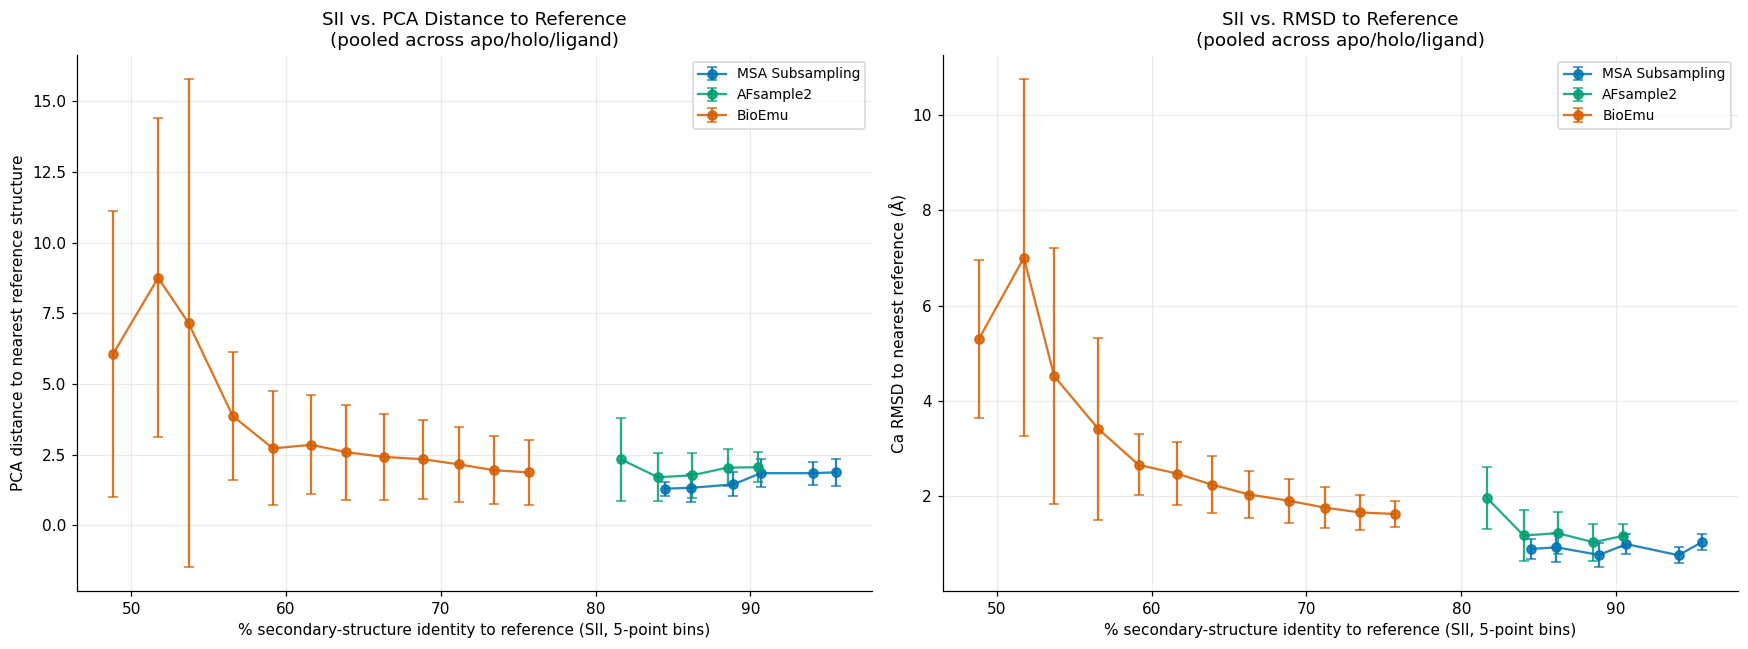

In [28]:
BIN_WIDTH = 2.5  # percentage points

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 0: SII vs. PCA distance to nearest reference
ax = axes[0]
sub_dist = density_vs_refdist_df.dropna(subset=["pct_ss_identity"])
for name in MODEL_NAMES:
    sub = sub_dist[sub_dist["model"] == name].copy()
    x = sub["pct_ss_identity"].values
    lo = np.floor(x.min() / BIN_WIDTH) * BIN_WIDTH
    hi = np.ceil(x.max() / BIN_WIDTH) * BIN_WIDTH
    edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
    sub["bin"] = pd.cut(sub["pct_ss_identity"], edges)
    binned = sub.groupby("bin", observed=True).agg(
        x_mean=("pct_ss_identity", "mean"), y_mean=("dist_to_ref_EV", "mean"),
        y_sd=("dist_to_ref_EV", "std"), n=("dist_to_ref_EV", "size"))
    binned = binned[binned["n"] >= 3].sort_values("x_mean")
    ax.errorbar(binned["x_mean"], binned["y_mean"], yerr=binned["y_sd"], fmt="o-", markersize=6,
                color=MODEL_COLORS[name], alpha=0.85, capsize=3, linewidth=1.5, label=name)
ax.set_xlabel("% secondary-structure identity to reference (SII, 5-point bins)")
ax.set_ylabel("PCA distance to nearest reference structure")
ax.set_title("SII vs. PCA Distance to Reference\n(pooled across apo/holo/ligand)")
ax.legend(fontsize=9, loc="best")

# Panel 1: SII vs. RMSD to nearest reference
ax = axes[1]
sub_rmsd = rmsd_vs_ref_df.dropna(subset=["pct_ss_identity"])
for name in MODEL_NAMES:
    sub = sub_rmsd[sub_rmsd["model"] == name].copy()
    x = sub["pct_ss_identity"].values
    lo = np.floor(x.min() / BIN_WIDTH) * BIN_WIDTH
    hi = np.ceil(x.max() / BIN_WIDTH) * BIN_WIDTH
    edges = np.arange(lo, hi + BIN_WIDTH, BIN_WIDTH)
    sub["bin"] = pd.cut(sub["pct_ss_identity"], edges)
    binned = sub.groupby("bin", observed=True).agg(
        x_mean=("pct_ss_identity", "mean"), y_mean=("rmsd_to_ref_A", "mean"),
        y_sd=("rmsd_to_ref_A", "std"), n=("rmsd_to_ref_A", "size"))
    binned = binned[binned["n"] >= 3].sort_values("x_mean")
    ax.errorbar(binned["x_mean"], binned["y_mean"], yerr=binned["y_sd"], fmt="o-", markersize=6,
                color=MODEL_COLORS[name], alpha=0.85, capsize=3, linewidth=1.5, label=name)
ax.set_xlabel("% secondary-structure identity to reference (SII, 5-point bins)")
ax.set_ylabel("Ca RMSD to nearest reference (\u00c5)")
ax.set_title("SII vs. RMSD to Reference\n(pooled across apo/holo/ligand)")
ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.savefig("../outputs/figures/ss_identity_vs_dist_and_rmsd.png", dpi=150, bbox_inches="tight")
plt.show()


**Interpretation.** BioEmu is the only one of the three models where poor secondary-structure
identity correlates with *both* greater RMSD error and greater PCA distance from the reference
(tables below) -- its most conformationally diverse structures are also its least accurately
folded. For MSA Subsampling and AFsample2, apparent diversity and fold quality are largely
decoupled, consistent with both remaining perturbations of one trained, single-answer network
rather than free samples from a learned distribution.

In [29]:
ssi_dist_corr_rows = []
for name, sub in density_vs_refdist_df.dropna(subset=["pct_ss_identity"]).groupby("model"):
    rho, p = spearmanr(sub["pct_ss_identity"], sub["dist_to_ref_EV"])
    ssi_dist_corr_rows.append(dict(model=name, n=len(sub),
                                    ss_identity_mean=round(sub["pct_ss_identity"].mean(), 1),
                                    ss_identity_sd=round(sub["pct_ss_identity"].std(), 1),
                                    dist_to_ref_EV_mean=round(sub["dist_to_ref_EV"].mean(), 3),
                                    dist_to_ref_EV_sd=round(sub["dist_to_ref_EV"].std(), 3),
                                    spearman_rho=round(rho, 3), p_value=round(p, 4)))
ssi_dist_corr_df = pd.DataFrame(ssi_dist_corr_rows)
ssi_dist_corr_df = ssi_dist_corr_df.rename(columns={"model": "Model", "n": "N",
    "ss_identity_mean": "Mean SS Identity (%)", "ss_identity_sd": "SD",
    "dist_to_ref_EV_mean": "Mean PCA Distance", "dist_to_ref_EV_sd": "SD",
    "spearman_rho": "Spearman rho", "p_value": "p-value"})
print("SS identity vs. PCA distance to nearest reference (negative rho = higher identity -> closer to reference):")
print(ssi_dist_corr_df.to_markdown(index=False))



SS identity vs. PCA distance to nearest reference (negative rho = higher identity -> closer to reference):
| Model           |    N |   Mean SS Identity (%) |   SD |   Mean PCA Distance |    SD |   Spearman rho |   p-value |
|:----------------|-----:|-----------------------:|-----:|--------------------:|------:|---------------:|----------:|
| AFsample2       |  600 |                   87.3 |  2.1 |               1.913 | 0.751 |          0.227 |         0 |
| BioEmu          | 3000 |                   66.6 |  4   |               2.478 | 1.753 |         -0.158 |         0 |
| MSA Subsampling |  600 |                   89.2 |  2.9 |               1.576 | 0.505 |          0.494 |         0 |


In [30]:
ssi_rmsd_corr_rows = []
for name, sub in rmsd_vs_ref_df.dropna(subset=["pct_ss_identity"]).groupby("model"):
    rho, p = spearmanr(sub["pct_ss_identity"], sub["rmsd_to_ref_A"])
    ssi_rmsd_corr_rows.append(dict(model=name, n=len(sub),
                                    ss_identity_mean=round(sub["pct_ss_identity"].mean(), 1),
                                    ss_identity_sd=round(sub["pct_ss_identity"].std(), 1),
                                    rmsd_to_ref_A_mean=round(sub["rmsd_to_ref_A"].mean(), 3),
                                    rmsd_to_ref_A_sd=round(sub["rmsd_to_ref_A"].std(), 3),
                                    spearman_rho=round(rho, 3), p_value=round(p, 4)))
ssi_rmsd_corr_df = pd.DataFrame(ssi_rmsd_corr_rows)
ssi_rmsd_corr_df = ssi_rmsd_corr_df.rename(columns={"model": "Model", "n": "N",
    "ss_identity_mean": "Mean SS Identity (%)", "ss_identity_sd": "SD",
    "rmsd_to_ref_A_mean": "Mean RMSD (A)", "rmsd_to_ref_A_sd": "SD",
    "spearman_rho": "Spearman rho", "p_value": "p-value"})
print("SS identity vs. Ca RMSD to nearest reference (negative rho = higher identity -> lower RMSD):")
print(ssi_rmsd_corr_df.to_markdown(index=False))


SS identity vs. Ca RMSD to nearest reference (negative rho = higher identity -> lower RMSD):
| Model           |    N |   Mean SS Identity (%) |   SD |   Mean RMSD (A) |    SD |   Spearman rho |   p-value |
|:----------------|-----:|-----------------------:|-----:|----------------:|------:|---------------:|----------:|
| AFsample2       |  600 |                   87.3 |  2.1 |           1.138 | 0.436 |         -0.086 |    0.0347 |
| BioEmu          | 3000 |                   66.6 |  4   |           2.099 | 0.745 |         -0.495 |    0      |
| MSA Subsampling |  600 |                   89.2 |  2.9 |           0.895 | 0.255 |          0.218 |    0      |


# 3. State Characterisation

Sections 1–2 asked how close a predicted structure gets to a resolved reference conformation,
in whole-protein terms. This section characterises the specific local feature that actually
distinguishes the ligand-bound cryptic-pocket state from apo/holo: a discrete side-chain rotamer
switch at Phe42 and a corresponding change in pocket-lining side-chain volume, gated together
rather than judged by backbone RMSD alone. Four subsections build this up in order: the
pocket-lining residue set itself (3.1), the χ1 rotamer readout (3.2), the pocket-volume readout
calibrated against the reference structures alone (3.3), and that same volume readout applied
to and cross-validated against all three predicted ensembles (3.4).

## 3.1. Pocket-Lining Residue Definition

The pocket-lining residue set is defined data-drivenly, not by literature assumption: every
IL-2 residue with a heavy atom within 4.5 Å of the bound small-molecule ligand's heavy atoms, in
each of the four ligand-bound reference structures independently, intersected across all four so
the final set is one every reference structure agrees defines the pocket.

In [31]:
def find_pocket_lining_residues(pdb_path, cutoff_A=4.5):
    """Data-driven cryptic-pocket definition: every IL-2 residue with a heavy atom within
    `cutoff_A` of any bound small-molecule ligand's heavy atoms in a single reference PDB."""
    traj = load_pdb_angstrom(pdb_path)
    top = traj.topology
    il2_chains = set(find_il2_chains(traj))
    prot_idx = [a.index for a in top.atoms
                if a.residue.chain.index in il2_chains and a.element.symbol != "H"]
    lig_residues = [r for r in top.residues
                    if not r.is_protein and not r.is_water and r.name not in NON_LIGAND_HET]
    if not lig_residues or not prot_idx:
        return set()
    tree = cKDTree(traj.xyz[0][prot_idx])
    contacts = set()
    for r in lig_residues:
        lig_idx = [a.index for a in r.atoms if a.element.symbol != "H"]
        for hits in tree.query_ball_point(traj.xyz[0][lig_idx], r=cutoff_A):
            for j in hits:
                contacts.add(top.atom(prot_idx[j]).residue.resSeq)
    return contacts


lining_per_pdb = {}
for p in sorted(glob.glob(f"{STATE_DIRS['ligand']}/*.pdb")):
    pdb_id = os.path.basename(p).replace(".pdb", "")
    lining_per_pdb[pdb_id] = find_pocket_lining_residues(p)
    print(f"{pdb_id}: {sorted(lining_per_pdb[pdb_id])}")

POCKET_LINING_RESIDUES = sorted(set.intersection(*lining_per_pdb.values()))
print(f"\nIntersection across all {len(lining_per_pdb)} ligand-bound PDBs "
      f"(canonical pocket definition, n={len(POCKET_LINING_RESIDUES)} residues):")
print(POCKET_LINING_RESIDUES)

1M48: [35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73, 76]
1M49: [34, 35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73]
1PW6: [35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73, 111]
1PY2: [34, 35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73, 111]

Intersection across all 4 ligand-bound PDBs (canonical pocket definition, n=13 residues):
[35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73]


## BioEmu Reconstruction, Step 2 -- Side-Chain Grafting

With the pocket-lining residue set now known (and combined with the three χ1-gating residues,
Section 3.2 below, into `MATCH_RESIDUES`), Step 2 of the BioEmu reconstruction introduced in
Section 1.2 can now run: for each BioEmu frame, a single donor structure is picked from the
pooled MSA Subsampling + AFsample2 ensemble by matching backbone dihedrals jointly across
`MATCH_RESIDUES`, and that donor's side-chain geometry is grafted onto BioEmu's own exact
backbone -- giving `bio_traj_full`, BioEmu's full-atom reconstruction, used for every χ1/pocket-
volume/real-DSSP-adjacent computation from here on.

In [32]:
MATCH_RESIDUES = sorted(set(POCKET_LINING_RESIDUES) | set(GATING_RESIDUES))
bio_grafted, bio_donor_idx = graft_bioemu_sidechains_single_donor(
    bio_phi_by_res, bio_psi_by_res, bio_R_all, bio_pos_A, donor_pool_all, MATCH_RESIDUES)
bio_traj_full = build_bioemu_full_atom_traj(bio_bb, bio_grafted)

n_grafted = len(bio_grafted)
n_from_msa = int((bio_donor_idx < msa_traj_full.n_frames).sum())
print(f"BioEmu full-atom reconstruction: {bio_traj_full.n_frames} frames, "
      f"{bio_traj_full.n_atoms} atoms/frame ({bio_traj_full.n_atoms / 133:.1f} atoms/residue avg)")
print(f"Residues with grafted side chains beyond CB: {n_grafted}/133 "
      f"({sorted(set(range(1,134)) - set(bio_grafted.keys()))} not grafted -- ALA/GLY have "
      f"nothing beyond CB to graft)")
print(f"Donor structure source for the {bio_traj_full.n_frames} matched BioEmu frames: "
      f"{n_from_msa} from MSA Subsampling, {bio_traj_full.n_frames - n_from_msa} from AFsample2 "
      f"({len(set(bio_donor_idx.tolist()))} distinct donor structures used overall)")

BioEmu full-atom reconstruction: 1000 frames, 947 atoms/frame (7.1 atoms/residue avg)
Residues with grafted side chains beyond CB: 126/133 ([1, 27, 50, 73, 98, 108, 112] not grafted -- ALA/GLY have nothing beyond CB to graft)
Donor structure source for the 1000 matched BioEmu frames: 178 from MSA Subsampling, 822 from AFsample2 (151 distinct donor structures used overall)


## 3.2. χ1 Rotamer State (Phe42 / Tyr45 / Glu62)

Three gating residues were originally considered for classifying pocket openness by side-chain
rotamer state; in practice Tyr45 and Glu62 are holo-like in effectively every structure across
all three models regardless of Phe42's own orientation, so the joint three-residue criterion
reduces to Phe42 alone. χ1 is computed via MDTraj's own chi1 atom definitions (N–Cα–Cβ–Cγ,
correct per residue type automatically), converted to degrees; a structure is classified
"open" (ligand-bound-like) at a residue if its χ1 sits within 60° of the pooled ligand-bound
reference's own mean χ1 at that residue.

In [33]:
def chi1_for_gating_residues(traj, residues=GATING_RESIDUES):
    """MDTraj's built-in md.compute_chi1 handles the correct chi1 atom definition for
    every residue type automatically; we just pick out the rows for our three gating
    residues and convert radians to degrees."""
    chi1_idx, chi1_vals = md.compute_chi1(traj)
    out = {}
    for i, quad in enumerate(chi1_idx):
        res = traj.topology.atom(quad[0]).residue
        if res.resSeq in residues and res.name == residues[res.resSeq]:
            out[res.resSeq] = np.degrees(chi1_vals[:, i])
    return out  # {resSeq: array of angles, one per frame}


ligand_chi1_rows = []
for p in sorted(glob.glob(f"{STATE_DIRS['ligand']}/*.pdb")):
    pdb_id = os.path.basename(p).replace(".pdb", "")
    for label, t in full_atom_single_chain_trajs(p):
        chi1 = {r: v[0] for r, v in chi1_for_gating_residues(t).items()}
        ligand_chi1_rows.append(dict(pdb_id=pdb_id, chain=label,
                                      **{f"res{r}_chi1": round(v, 1) for r, v in chi1.items()}))
ligand_chi1_df = pd.DataFrame(ligand_chi1_rows)
print(f"chi1 (Phe42/Tyr45/Glu62) across all {len(ligand_chi1_df)} resolved ligand-bound reference chains:")
print(ligand_chi1_df.to_string(index=False))

ref_chi1 = {r: float(ligand_chi1_df[f"res{r}_chi1"].mean()) for r in GATING_RESIDUES}
print(f"\nPooled ligand-bound reference chi1 (mean across all {len(ligand_chi1_df)} chains):",
      {k: round(v, 1) for k, v in ref_chi1.items()})

ref_1m47 = load_pdb_angstrom(f"{STATE_DIRS['apo']}/1M47.pdb")
apo_chi1 = {r: v[0] for r, v in chi1_for_gating_residues(ref_1m47).items()}
print("1M47 (apo) chi1:", {k: round(v, 1) for k, v in apo_chi1.items()})

chi1 (Phe42/Tyr45/Glu62) across all 10 resolved ligand-bound reference chains:
pdb_id       chain  res42_chi1  res45_chi1  res62_chi1
  1M48 1M48:chain0 -176.300003  -71.300003  -69.699997
  1M48 1M48:chain1 -172.300003  -70.800003  -70.000000
  1M49 1M49:chain0 -172.300003  -73.500000  -73.199997
  1M49 1M49:chain1 -170.199997  -70.300003  -75.900002
  1PW6 1PW6:chain0 -149.100006  -72.400002  -77.699997
  1PW6 1PW6:chain1 -152.699997  -83.000000  -81.199997
  1PY2 1PY2:chain0 -151.899994  -78.800003  -67.900002
  1PY2 1PY2:chain1 -150.699997  -85.300003  -74.900002
  1PY2 1PY2:chain2 -152.300003  -78.099998  -70.699997
  1PY2 1PY2:chain3 -150.699997  -77.000000  -83.900002

Pooled ligand-bound reference chi1 (mean across all 10 chains): {42: -159.9, 45: -76.1, 62: -74.5}
1M47 (apo) chi1: {42: np.float32(-61.5), 45: np.float32(-66.6), 62: np.float32(-72.2)}


In [34]:
# chi1 for all three models. MSA Subsampling and AFsample2 are direct (full-atom, real
# side chains); BioEmu uses bio_traj_full (Section 1: exact backbone + grafted side chains).
msa_chi1 = chi1_for_gating_residues(msa_traj_full)
afs2_chi1 = chi1_for_gating_residues(afs2_traj_full)
bio_chi1 = chi1_for_gating_residues(bio_traj_full)

model_chi1_dfs = {}
for name, meta_idx, chi1_dict, labels_key in [
        ("MSA Subsampling", msa_meta_idx, msa_chi1, "ligand"),
        ("AFsample2", afs2_meta_idx, afs2_chi1, "ligand"),
        ("BioEmu", None, bio_chi1, "ligand")]:
    if meta_idx is not None:
        df = meta_idx.copy()
    else:
        df = pd.DataFrame({"source": [f"BioEmu:{i}" for i in range(bio_traj_full.n_frames)]})
    diffs, holo_like = {}, {}
    for r in ref_chi1:
        df[f"res{r}_chi1"] = chi1_dict[r]
        diffs[r] = angular_diff(chi1_dict[r], ref_chi1[r])
        holo_like[r] = diffs[r] <= 60.0
        df[f"res{r}_diff"] = diffs[r]
        df[f"res{r}_open"] = holo_like[r]
    df["all_open"] = np.all(list(holo_like.values()), axis=0)
    df["combined_diff"] = sum(diffs.values())
    model_chi1_dfs[name] = df
    print(f"{name}: {df.all_open.sum()}/{len(df)} = {df.all_open.mean()*100:.0f}% classified "
          f"'open' (all 3 gating residues holo-like)")
    print(f"  per-residue holo-like fraction: "
          f"{ {r: round(float(df[f'res{r}_open'].mean()),2) for r in ref_chi1} }")

MSA Subsampling: 125/200 = 62% classified 'open' (all 3 gating residues holo-like)
  per-residue holo-like fraction: {42: 0.62, 45: 1.0, 62: 1.0}
AFsample2: 126/200 = 63% classified 'open' (all 3 gating residues holo-like)
  per-residue holo-like fraction: {42: 0.63, 45: 1.0, 62: 1.0}
BioEmu: 480/1000 = 48% classified 'open' (all 3 gating residues holo-like)
  per-residue holo-like fraction: {42: 0.48, 45: 1.0, 62: 1.0}


In [35]:
def reference_chi1_df_for_state(state):
    """Same construction as ligand_chi1_rows above, generalized to any state -- apo/holo
    don't have an equivalent per-chain chi1 dataframe yet, only ligand-bound does."""
    rows = []
    for p in sorted(glob.glob(f"{STATE_DIRS[state]}/*.pdb")):
        pdb_id = os.path.basename(p).replace(".pdb", "")
        if pdb_id in EXCLUDED_PDB_IDS:
            continue
        for label, t in full_atom_single_chain_trajs(p):
            chi1 = {r: v[0] for r, v in chi1_for_gating_residues(t).items()}
            if set(GATING_RESIDUES) - set(chi1):
                continue  # skip chains missing one of the 3 gating residues resolved
            rows.append(dict(pdb_id=pdb_id, chain=label,
                              **{f"res{r}_chi1": v for r, v in chi1.items()}))
    return pd.DataFrame(rows)


reference_chi1_by_state = {"ligand": ligand_chi1_df,
                            "apo": reference_chi1_df_for_state("apo"),
                            "holo": reference_chi1_df_for_state("holo")}

rotamer_stats_rows = []
for r in GATING_RESIDUES:
    for state in STATES:
        vals = reference_chi1_by_state[state][f"res{r}_chi1"].values
        rotamer_stats_rows.append(dict(group=f"Reference ({STATE_LABELS[state]})", residue=f"{GATING_RESIDUES[r]}{r}",
                                        n=len(vals), mean=round(float(np.mean(vals)), 2),
                                        sdev=round(float(np.std(vals, ddof=1)), 2),
                                        variance=round(float(np.var(vals, ddof=1)), 2)))
    for name in MODEL_NAMES:
        vals = model_chi1_dfs[name][f"res{r}_chi1"].values
        rotamer_stats_rows.append(dict(group=name, residue=f"{GATING_RESIDUES[r]}{r}",
                                        n=len(vals), mean=round(float(np.mean(vals)), 2),
                                        sdev=round(float(np.std(vals, ddof=1)), 2),
                                        variance=round(float(np.var(vals, ddof=1)), 2)))

rotamer_stats_df = pd.DataFrame(rotamer_stats_rows)
rotamer_stats_df


,group,residue,n,mean,sdev,variance
0,Reference (Apo (unbound)),PHE42,3,-65.82,3.75,14.04
1,Reference (Holo (IL-2Ra-bound)),PHE42,4,-61.67,1.92,3.69
2,Reference (Ligand-bound (cryptic pocket)),PHE42,10,-159.85,11.26,126.90
3,MSA Subsampling,PHE42,200,-132.95,39.58,1566.46
4,AFsample2,PHE42,200,-128.97,47.93,2297.58
5,BioEmu,PHE42,1000,-97.06,54.83,3006.83
6,Reference (Apo (unbound)),TYR45,3,-68.26,1.44,2.09
7,Reference (Holo (IL-2Ra-bound)),TYR45,4,-68.00,3.31,10.94
8,Reference (Ligand-bound (cryptic pocket)),TYR45,10,-76.05,5.27,27.73
9,MSA Subsampling,TYR45,200,-68.84,1.04,1.08


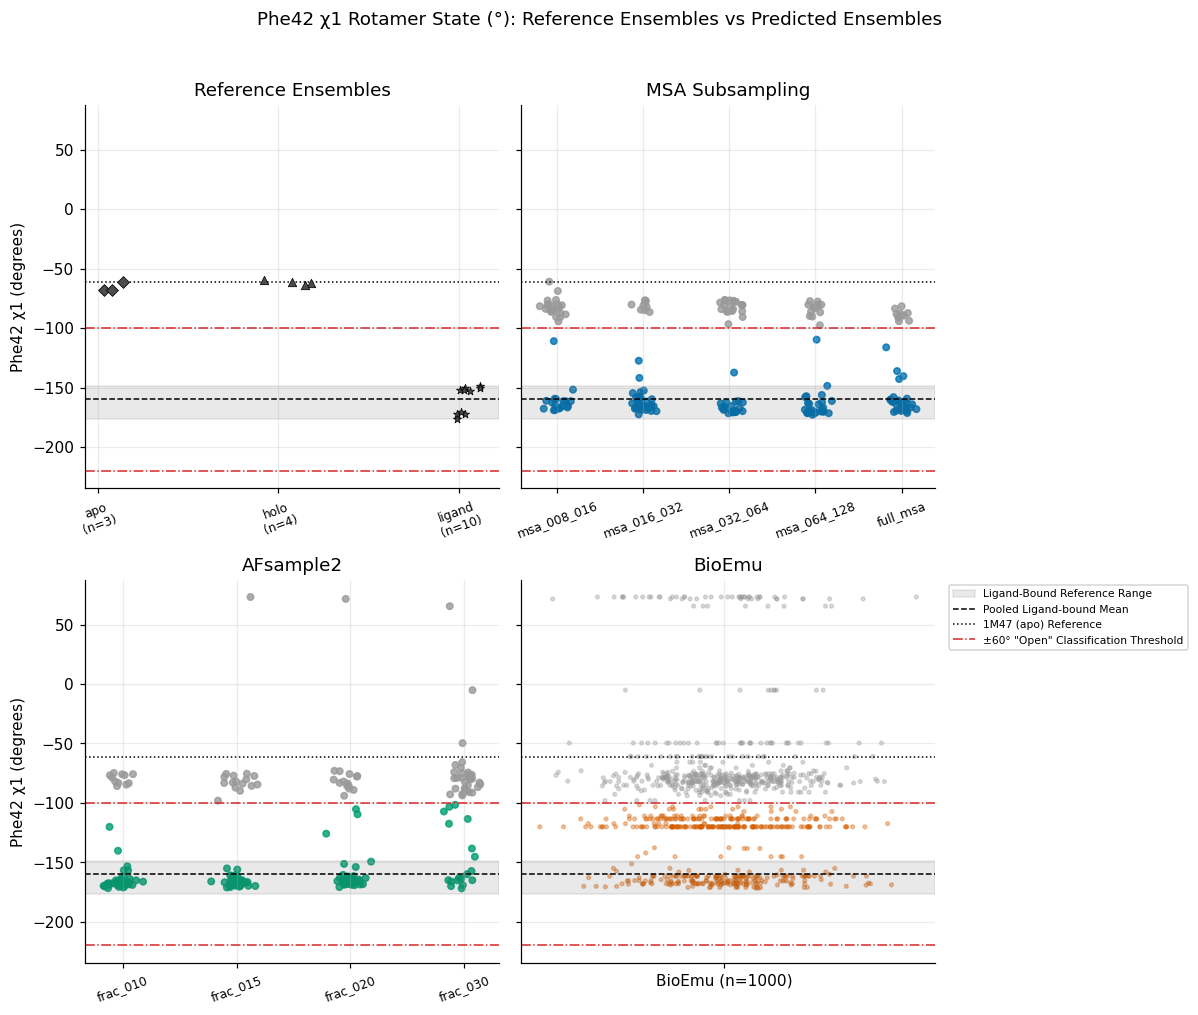

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharey=True)
np.random.seed(0)
model_x_categories = {
    "MSA Subsampling": ("msa_depth", MSA_ORDER),
    "AFsample2": ("dropout_rate", DROPOUT_ORDER),
    "BioEmu": (None, None),
}
OPEN_THRESHOLD_DEG = 60.0
REF_STATE_MARKERS = {"apo": "D", "holo": "^", "ligand": "*"}
REF_STATE_ORDER = ["apo", "holo", "ligand"]

# Top-left: reference ensembles (apo/holo/ligand-bound pools)
ax = axes[0, 0]
for i, state in enumerate(REF_STATE_ORDER):
    sub = reference_chi1_by_state[state]  # was an undefined name; this dict (built just above) has the same data per-state
    jitter = np.random.normal(i, 0.08, size=len(sub))
    ax.scatter(jitter, sub["res42_chi1"], s=30, marker=REF_STATE_MARKERS[state],
               color=COLOR_REF, edgecolors="black", linewidths=0.5, zorder=5)
ax.set_xticks(range(len(REF_STATE_ORDER)))
ax.set_xticklabels([f"{s}\n(n={len(reference_chi1_by_state[s])})" for s in REF_STATE_ORDER],
                    rotation=20, fontsize=8)
ax.axhspan(ligand_chi1_df["res42_chi1"].min(), ligand_chi1_df["res42_chi1"].max(),
           color=COLOR_REF, alpha=0.12, label="Ligand-Bound reference range")
ax.axhline(ref_chi1[42], color="k", linestyle="--", linewidth=1, label="Pooled Ligand-bound Mean")
ax.axhline(apo_chi1[42], color="k", linestyle=":", linewidth=1, label="1M47 (apo) reference")
ax.axhline(ref_chi1[42] + OPEN_THRESHOLD_DEG, color="tab:red", linestyle="-.", linewidth=1,
           label="±60° \"Open\" Classification Threshold")
ax.axhline(ref_chi1[42] - OPEN_THRESHOLD_DEG, color="tab:red", linestyle="-.", linewidth=1)
ax.set_title("Reference Ensembles")
ax.set_ylabel("Phe42 χ1 (degrees)")

# Remaining 3 quadrants: MSA Subsampling (top-right), AFsample2 (bottom-left), BioEmu (bottom-right)
model_axes = [(axes[0, 1], "MSA Subsampling", COLOR_MSA),
              (axes[1, 0], "AFsample2", COLOR_AFS2),
              (axes[1, 1], "BioEmu", COLOR_BIO)]

for ax, name, color in model_axes:
    df = model_chi1_dfs[name]
    cat_col, cat_order = model_x_categories[name]
    if cat_col is None:
        jitter = np.random.normal(0, 0.3, size=len(df))
        colors = np.where(df["res42_open"], color, "#999999")
        ax.scatter(jitter, df["res42_chi1"], s=6, alpha=0.35, c=colors)
        ax.set_xticks([0]); ax.set_xticklabels(["BioEmu (n=1000)"])
    else:
        for i, cat in enumerate(cat_order):
            sub = df[df[cat_col] == cat]
            jitter = np.random.normal(i, 0.08, size=len(sub))
            colors = np.where(sub["res42_open"], color, "#999999")
            ax.scatter(jitter, sub["res42_chi1"], s=18, alpha=0.8, c=colors)
        ax.set_xticks(range(len(cat_order))); ax.set_xticklabels(cat_order, rotation=20, fontsize=8)
    ax.axhspan(ligand_chi1_df["res42_chi1"].min(), ligand_chi1_df["res42_chi1"].max(),
               color=COLOR_REF, alpha=0.12, label="Ligand-Bound Reference Range")
    ax.axhline(ref_chi1[42], color="k", linestyle="--", linewidth=1, label="Pooled Ligand-bound Mean")
    ax.axhline(apo_chi1[42], color="k", linestyle=":", linewidth=1, label="1M47 (apo) Reference")
    ax.axhline(ref_chi1[42] + OPEN_THRESHOLD_DEG, color="tab:red", linestyle="-.", linewidth=1,
               label="±60° \"Open\" Classification Threshold")
    ax.axhline(ref_chi1[42] - OPEN_THRESHOLD_DEG, color="tab:red", linestyle="-.", linewidth=1)
    ax.set_title(name)
    if ax is axes[1, 0]:
        ax.set_ylabel("Phe42 χ1 (degrees)")

axes[1, 1].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.suptitle("Phe42 χ1 Rotamer State (°): Reference Ensembles vs Predicted Ensembles", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/phe42_chi1.png", dpi=150, bbox_inches="tight")
plt.show()



**Per-condition Phe42 classification.** For each MSA-depth / dropout-rate condition (pooled across all samples for BioEmu), the fraction of structures that are near-apo (within 60° of the 1M47 χ1), distinct from the pooled ligand-bound state (>60° from its mean), or literally inside the pooled reference's observed χ1 range.

In [37]:
rows = []
for name in ["MSA Subsampling", "AFsample2", "BioEmu"]:
    df = model_chi1_dfs[name]
    cat_col, cat_order = model_x_categories[name]
    groups = [(cat, df[df[cat_col] == cat]) for cat in cat_order] if cat_col is not None else [("all samples", df)]

    for cat, sub in groups:
        n = len(sub)
        apo_diff = angular_diff(sub["res42_chi1"].values, apo_chi1[42])
        near_apo = apo_diff <= OPEN_THRESHOLD_DEG                       # within 60 deg of the apo reference
        distinct_from_ligand = ~sub["res42_open"].values               # >60 deg from the pooled ligand-bound mean
        in_ref_range = sub["res42_chi1"].between(
            ligand_chi1_df["res42_chi1"].min(), ligand_chi1_df["res42_chi1"].max())  # inside the literal reference band

        rows.append({
            "Model": name,
            "Condition": cat,
            "N structures": n,
            "Near-Apo (≤60° from apo reference) (n)": int(near_apo.sum()),
            "Near-Apo (≤60° from apo reference) (%)": round(100 * near_apo.mean(), 1),
            ">60° from Ligand-Bound Mean (n)": int(distinct_from_ligand.sum()),
            ">60° from Ligand-Bound Mean (%)": round(100 * distinct_from_ligand.mean(), 1),
            "Within Ligand-Bound Ref. Range (n)": int(in_ref_range.sum()),
            "Within Ligand-Bound Ref. Range (%)": round(100 * in_ref_range.mean(), 1),
        })

phe42_class_by_condition_df = pd.DataFrame(rows)
print(phe42_class_by_condition_df.to_markdown(index=False))



| Model           | Condition   |   N structures |   Near-Apo (≤60° from apo reference) (n) |   Near-Apo (≤60° from apo reference) (%) |   >60° from Ligand-Bound Mean (n) |   >60° from Ligand-Bound Mean (%) |   Within Ligand-Bound Ref. Range (n) |   Within Ligand-Bound Ref. Range (%) |
|:----------------|:------------|---------------:|-----------------------------------------:|-----------------------------------------:|----------------------------------:|----------------------------------:|-------------------------------------:|-------------------------------------:|
| MSA Subsampling | msa_008_016 |             40 |                                       23 |                                     57.5 |                                22 |                              55   |                                   17 |                                 42.5 |
| MSA Subsampling | msa_016_032 |             40 |                                        9 |                                     22.5 |   

## 3.3. Pocket Volume & SASA (Reference Calibration)

The second, geometric readout of pocket openness: the convex-hull volume of the pocket-lining
side chains' heavy atoms (excluding backbone atoms), plus summed per-residue solvent-accessible
surface area (SASA) as a complementary check. Computed first on the reference structures alone,
this establishes an empirical, data-driven open/closed threshold -- the pooled apo+holo
("closed") mean plus 2 SD -- rather than an assumed cutoff, checked against the requirement that
every ligand-bound reference chain actually clears it.

In [38]:
def pocket_hull_volume_A3(traj, resSeqs):
    """Convex-hull volume (Angstrom^3, frame 0) of the side-chain heavy atoms (excludes
    backbone N/CA/C/O) of the given pocket-lining residues."""
    idx = [a.index for a in traj.topology.atoms
           if a.residue.resSeq in resSeqs and a.name not in ("N", "CA", "C", "O")
           and a.element.symbol != "H"]
    return ConvexHull(traj.xyz[0][idx]).volume


def pocket_hull_volume_series_A3(traj, resSeqs):
    """Per-frame pocket volume for a multi-frame trajectory sharing one topology."""
    idx = [a.index for a in traj.topology.atoms
           if a.residue.resSeq in resSeqs and a.name not in ("N", "CA", "C", "O")
           and a.element.symbol != "H"]
    return np.array([ConvexHull(traj.xyz[i][idx]).volume for i in range(traj.n_frames)])


def pocket_sasa_A2(traj, resSeqs):
    """Summed per-residue SASA (Angstrom^2) of the pocket-lining residues. MDTraj's
    shrake_rupley assumes nanometre input -- so, unlike the Angstrom convention used
    everywhere else in this notebook, it needs a nm-scaled copy."""
    nm_traj = md.Trajectory(xyz=traj.xyz / 10.0, topology=traj.topology)
    sasa_nm2 = md.shrake_rupley(nm_traj, mode="residue")[0]
    keep = [r.index for r in traj.topology.residues if r.resSeq in resSeqs]
    return float(sasa_nm2[keep].sum()) * 100.0  # nm^2 -> A^2

In [39]:
# Reference (crystal) pocket volume/SASA -- unchanged from the original methodology, now
# additionally used as the shared open/closed threshold for all three models below.
pocket_rows = []
for state in STATES:
    for p in sorted(glob.glob(f"{STATE_DIRS[state]}/*.pdb")):
        pdb_id = os.path.basename(p).replace(".pdb", "")
        if pdb_id in EXCLUDED_PDB_IDS:
            continue
        for label, t in full_atom_single_chain_trajs(p):
            resolved = set(a.residue.resSeq for a in t.topology.atoms)
            if not set(POCKET_LINING_RESIDUES).issubset(resolved):
                continue
            pocket_rows.append(dict(
                state=state, chain=label,
                hull_volume_A3=round(pocket_hull_volume_A3(t, POCKET_LINING_RESIDUES), 1),
                pocket_sasa_A2=round(pocket_sasa_A2(t, POCKET_LINING_RESIDUES), 1)))
pocket_df = pd.DataFrame(pocket_rows)
pocket_summary = pocket_df.groupby("state")[["hull_volume_A3", "pocket_sasa_A2"]].agg(["mean", "std", "count"]).round(1)
print(pocket_summary.to_markdown())

| state   |   ('hull_volume_A3', 'mean') |   ('hull_volume_A3', 'std') |   ('hull_volume_A3', 'count') |   ('pocket_sasa_A2', 'mean') |   ('pocket_sasa_A2', 'std') |   ('pocket_sasa_A2', 'count') |
|:--------|-----------------------------:|----------------------------:|------------------------------:|-----------------------------:|----------------------------:|------------------------------:|
| apo     |                       1391.6 |                        92.1 |                             3 |                        882.9 |                        72.2 |                             3 |
| holo    |                       1308.1 |                        42.4 |                             4 |                        861.8 |                        21.5 |                             4 |
| ligand  |                       1526.5 |                        66.6 |                            10 |                        854.9 |                        61.6 |                            10 |


In [40]:
apo_vol = pocket_df.loc[pocket_df.state == "apo", "hull_volume_A3"].values
holo_vol = pocket_df.loc[pocket_df.state == "holo", "hull_volume_A3"].values
ligand_vol = pocket_df.loc[pocket_df.state == "ligand", "hull_volume_A3"].values
closed_vol = np.concatenate([apo_vol, holo_vol])


print(f"apo    pocket volume: {apo_vol.mean():.1f} +/- {apo_vol.std():.1f} A^3 (n={len(apo_vol)})")
print(f"holo   pocket volume: {holo_vol.mean():.1f} +/- {holo_vol.std():.1f} A^3 (n={len(holo_vol)})")
print(f"ligand pocket volume: {ligand_vol.mean():.1f} +/- {ligand_vol.std():.1f} A^3 (n={len(ligand_vol)})")


POCKET_OPEN_THRESHOLD_A3 = float(closed_vol.mean() + 2 * closed_vol.std())
print(f"\nPocket-open threshold (pooled closed mean + 2 SD): {POCKET_OPEN_THRESHOLD_A3:.1f} A^3")
print(f"All {len(ligand_vol)} ligand-bound reference chains clear this threshold: "
      f"{bool(np.all(ligand_vol > POCKET_OPEN_THRESHOLD_A3))}")

print("\nFull range (Å³), per state:")
for label, vol in [("apo", apo_vol), ("holo", holo_vol), ("ligand", ligand_vol)]:
    print(f"  {label:6s}: min={vol.min():.1f}, max={vol.max():.1f}, range={vol.max() - vol.min():.1f} (n={len(vol)})")



apo    pocket volume: 1391.6 +/- 75.2 A^3 (n=3)
holo   pocket volume: 1308.1 +/- 36.7 A^3 (n=4)
ligand pocket volume: 1526.5 +/- 63.2 A^3 (n=10)

Pocket-open threshold (pooled closed mean + 2 SD): 1483.9 A^3
All 10 ligand-bound reference chains clear this threshold: False

Full range (Å³), per state:
  apo   : min=1285.3, max=1445.0, range=159.7 (n=3)
  holo  : min=1255.9, max=1359.1, range=103.2 (n=4)
  ligand: min=1395.3, max=1596.6, range=201.3 (n=10)


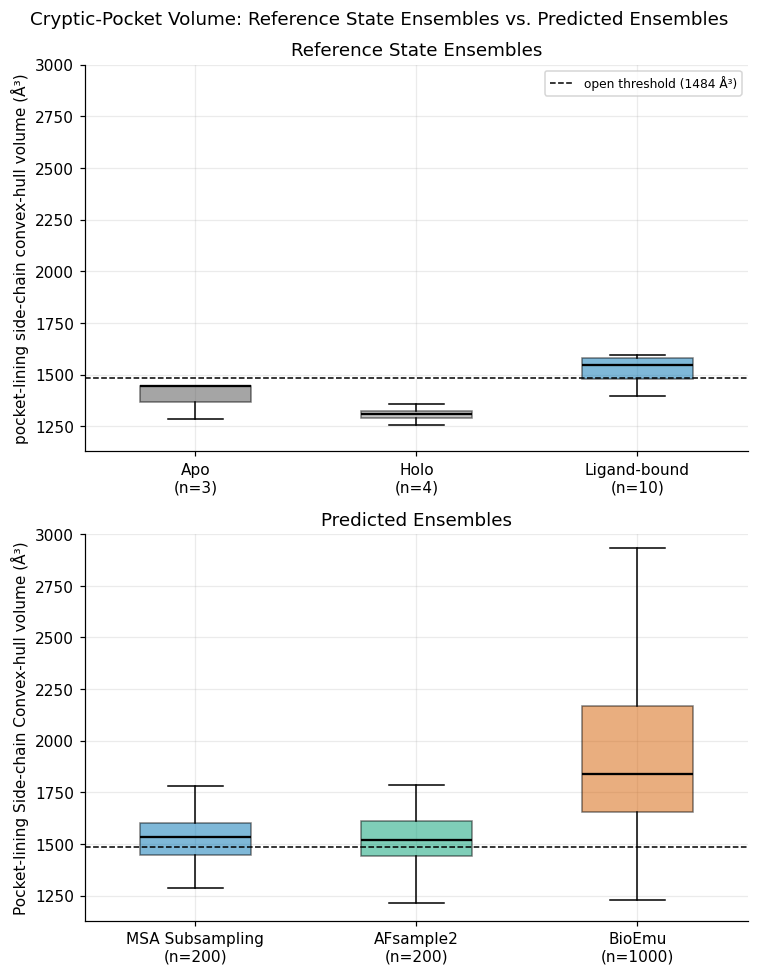

In [41]:
fig, axes = plt.subplots(2, 1, figsize=(7, 9), sharey=True)
median_style = dict(color="black", linewidth=1.5)

# Panel 0: reference structures -- no point overlay, n under each bar's tick label
ax = axes[0]
ref_data = [apo_vol, holo_vol, ligand_vol]
ref_labels = ["Apo", "Holo", "Ligand-bound"]
bp = ax.boxplot(ref_data, tick_labels=[f"{lab}\n(n={len(vals)})" for lab, vals in zip(ref_labels, ref_data)],
                 patch_artist=True, widths=0.5, medianprops=median_style)
for patch, color in zip(bp["boxes"], [COLOR_REF, "#8a8a8a", COLOR_MSA]):
    patch.set_facecolor(color); patch.set_alpha(0.5)
ax.axhline(POCKET_OPEN_THRESHOLD_A3, color="k", linestyle="--", linewidth=1,
           label=f"open threshold ({POCKET_OPEN_THRESHOLD_A3:.0f} Å³)")
ax.set_ylabel("pocket-lining side-chain convex-hull volume (Å³)")
ax.set_title("Reference State Ensembles")
ax.legend(fontsize=8)

# Panel 1: predicted ensembles -- same box style, no point overlay
ax = axes[1]
model_pocket_vol = {
    "MSA Subsampling": pocket_hull_volume_series_A3(msa_traj_full, POCKET_LINING_RESIDUES),
    "AFsample2": pocket_hull_volume_series_A3(afs2_traj_full, POCKET_LINING_RESIDUES),
    "BioEmu": pocket_hull_volume_series_A3(bio_traj_full, POCKET_LINING_RESIDUES),
}
model_data = [model_pocket_vol[name] for name in MODEL_NAMES]
bp = ax.boxplot(model_data, tick_labels=[f"{n}\n(n={len(model_pocket_vol[n])})" for n in MODEL_NAMES],
                 patch_artist=True, widths=0.5, medianprops=median_style, showfliers=False)
for patch, name in zip(bp["boxes"], MODEL_NAMES):
    patch.set_facecolor(MODEL_COLORS[name]); patch.set_alpha(0.5)
ax.axhline(POCKET_OPEN_THRESHOLD_A3, color="k", linestyle="--", linewidth=1)
ax.set_ylabel("Pocket-lining Side-chain Convex-hull volume (Å³)")
ax.set_title("Predicted Ensembles")

axes[0].set_ylim(top=3000)
fig.suptitle("Cryptic-Pocket Volume: Reference State Ensembles vs. Predicted Ensembles")
plt.tight_layout()
plt.savefig("../outputs/figures/pocket_volume_gallery.png", dpi=150, bbox_inches="tight")
plt.show()




## 3.4. Cryptic Pocket Volume Applied to Predicted Ensembles

The same pocket-lining convex-hull volume and SASA metrics, now computed per-frame for all three
predicted full-atom ensembles and classified against the reference-derived open/closed threshold
above. Cross-tabulating this volume-based classification against the independent χ1-based
classification (Section 3.2), separately per model, tests whether the two readouts of "openness"
actually agree.

In [42]:
pocket_vol_by_model = {
    "MSA Subsampling": pocket_hull_volume_series_A3(msa_traj_full, POCKET_LINING_RESIDUES),
    "AFsample2": pocket_hull_volume_series_A3(afs2_traj_full, POCKET_LINING_RESIDUES),
    "BioEmu": pocket_hull_volume_series_A3(bio_traj_full, POCKET_LINING_RESIDUES),
}
pocket_sasa_by_model = {
    "MSA Subsampling": pocket_sasa_A2(msa_traj_full, POCKET_LINING_RESIDUES),
    "AFsample2": pocket_sasa_A2(afs2_traj_full, POCKET_LINING_RESIDUES),
}
# per-frame SASA needed here (not just frame 0) -- loop per model since shrake_rupley batches
# over frames but pocket_sasa_A2 above sums frame 0 only; compute the full per-frame series:
def pocket_sasa_series_A2(traj, resSeqs):
    nm_traj = md.Trajectory(xyz=traj.xyz / 10.0, topology=traj.topology)
    sasa_nm2 = md.shrake_rupley(nm_traj, mode="residue")
    keep = [r.index for r in traj.topology.residues if r.resSeq in resSeqs]
    return sasa_nm2[:, keep].sum(axis=1) * 100.0

pocket_sasa_series_by_model = {
    "MSA Subsampling": pocket_sasa_series_A2(msa_traj_full, POCKET_LINING_RESIDUES),
    "AFsample2": pocket_sasa_series_A2(afs2_traj_full, POCKET_LINING_RESIDUES),
    "BioEmu": pocket_sasa_series_A2(bio_traj_full, POCKET_LINING_RESIDUES),
}

agreement_rows = []
for name, df in model_chi1_dfs.items():
    df["pocket_volume_A3"] = pocket_vol_by_model[name]
    df["pocket_sasa_A2"] = pocket_sasa_series_by_model[name]
    df["pocket_open"] = df["pocket_volume_A3"] > POCKET_OPEN_THRESHOLD_A3
    agree = (df["pocket_open"] == df["all_open"])
    agreement_rows.append(dict(model=name,
                                pct_chi1_open=round(float(df.all_open.mean() * 100), 1),
                                pct_volume_open=round(float(df.pocket_open.mean() * 100), 1),
                                pct_agreement=round(float(agree.mean() * 100), 1)))
    print(f"\n{name}: chi1 all_open={df.all_open.sum()}/{len(df)}, "
          f"volume pocket_open={df.pocket_open.sum()}/{len(df)}, agreement={agree.mean()*100:.0f}%")
    print(pd.crosstab(df["all_open"], df["pocket_open"],
                       rownames=["chi1: all_open"], colnames=["volume: pocket_open"]))

agreement_df = pd.DataFrame(agreement_rows)
agreement_df


MSA Subsampling: chi1 all_open=125/200, volume pocket_open=132/200, agreement=72%
volume: pocket_open  False  True 
chi1: all_open                   
False                   44     31
True                    24    101

AFsample2: chi1 all_open=126/200, volume pocket_open=116/200, agreement=65%
volume: pocket_open  False  True 
chi1: all_open                   
False                   44     30
True                    40     86

BioEmu: chi1 all_open=480/1000, volume pocket_open=945/1000, agreement=48%
volume: pocket_open  False  True 
chi1: all_open                   
False                   27    493
True                    28    452


,model,pct_chi1_open,pct_volume_open,pct_agreement
0,MSA Subsampling,62.5,66.0,72.5
1,AFsample2,63.0,58.0,65.0
2,BioEmu,48.0,94.5,47.9


In [43]:
# Full-atom ensembles superposed onto the ligand-state PCA basis (superpose_full_atom_on_ca,
# Section 0), so every PDB exported from here on (pocket-volume top5 below, and the MD seed
# selection in Section 5) is written out in a consistent, comparable orientation. None of
# msa_full_ligand_aligned / afs2_full_ligand_aligned / bio_full_ligand_aligned /
# full_aligned_by_model / export_name_by_model were previously defined anywhere in the
# notebook -- added here, at the first point all three *_traj_full trajectories exist.
msa_full_ligand_aligned = superpose_full_atom_on_ca(msa_traj_full, pca_basis["ligand"])
afs2_full_ligand_aligned = superpose_full_atom_on_ca(afs2_traj_full, pca_basis["ligand"])
bio_full_ligand_aligned = superpose_full_atom_on_ca(bio_traj_full, pca_basis["ligand"])

full_aligned_by_model = {"MSA Subsampling": msa_full_ligand_aligned,
                          "AFsample2": afs2_full_ligand_aligned,
                          "BioEmu": bio_full_ligand_aligned}
export_name_by_model = {name: name.replace(" ", "_") for name in MODEL_NAMES}

In [44]:
top5_vol_tables = {}
for name, df in model_chi1_dfs.items():
    labels = df["source"].tolist()
    df_top5, idx = top5_by_value(df["pocket_volume_A3"].values, labels, ascending=False)
    df_top5 = df_top5.rename(columns={"value": "pocket_volume_A3"})
    export_top5_pdbs(full_aligned_by_model[name], idx, "ligand", export_name_by_model[name],
                      "pocket_volume_most_open", labels)
    top5_vol_tables[name] = df_top5
    print(f"--- {name}: top 5 largest cryptic-pocket volume (independent of chi1) ---")
    print(df_top5.to_string(index=False))

--- MSA Subsampling: top 5 largest cryptic-pocket volume (independent of chi1) ---
 rank                               source  pocket_volume_A3
    1 MSA:msa_008_016:rank040_model2_seed3          2253.775
    2 MSA:msa_008_016:rank037_model1_seed6          2150.342
    3 MSA:msa_008_016:rank035_model1_seed4          1781.505
    4 MSA:msa_008_016:rank015_model5_seed4          1765.898
    5 MSA:msa_008_016:rank027_model2_seed6          1696.896
--- AFsample2: top 5 largest cryptic-pocket volume (independent of chi1) ---
 rank                     source  pocket_volume_A3
    1 AFS2:frac_030:model2_pred2          2433.225
    2 AFS2:frac_030:model2_pred4          2369.771
    3 AFS2:frac_020:model4_pred8          2352.986
    4 AFS2:frac_020:model2_pred9          2330.768
    5 AFS2:frac_015:model2_pred6          2309.237
--- BioEmu: top 5 largest cryptic-pocket volume (independent of chi1) ---
 rank     source  pocket_volume_A3
    1 BioEmu:407          3776.234
    2 BioEmu:108        

In [45]:
pocket_stats_rows = []
for state in STATES:
    vals = pocket_df.loc[pocket_df["state"] == state, "hull_volume_A3"].values
    pocket_stats_rows.append(dict(group=f"Reference ({STATE_LABELS[state]})", n=len(vals),
                                   mean=round(float(np.mean(vals)), 1),
                                   sdev=round(float(np.std(vals, ddof=1)), 1),
                                   variance=round(float(np.var(vals, ddof=1)), 1)))
for name in MODEL_NAMES:
    vals = model_chi1_dfs[name]["pocket_volume_A3"].values
    pocket_stats_rows.append(dict(group=name, n=len(vals),
                                   mean=round(float(np.mean(vals)), 1),
                                   sdev=round(float(np.std(vals, ddof=1)), 1),
                                   variance=round(float(np.var(vals, ddof=1)), 1)))

pocket_stats_df = pd.DataFrame(pocket_stats_rows).rename(columns={"group": "Group", "n": "N",
    "mean": "Mean Volume (A3)", "sdev": "SD", "variance": "Variance"})
print(pocket_stats_df.to_markdown(index=False))


| Group                                     |    N |   Mean Volume (A3) |    SD |   Variance |
|:------------------------------------------|-----:|-------------------:|------:|-----------:|
| Reference (Apo (unbound))                 |    3 |             1391.6 |  92.1 |     8474.8 |
| Reference (Holo (IL-2Ra-bound))           |    4 |             1308.1 |  42.4 |     1798.7 |
| Reference (Ligand-bound (cryptic pocket)) |   10 |             1526.5 |  66.6 |     4440.4 |
| MSA Subsampling                           |  200 |             1528.3 | 116.9 |    13674   |
| AFsample2                                 |  200 |             1551.5 | 192.9 |    37229.4 |
| BioEmu                                    | 1000 |             1944.4 | 397.1 |   157659   |


# 4. MD Seed Selection

Section 2 established that MSA Subsampling and AFsample2 are fidelity-strong and low-diversity,
while BioEmu is diversity-strong and fidelity-weak. Seeding follows directly from that split, but
the aim is not to pick each ensemble's most typical or best-scoring structure: each criterion
below instead targets a different kind of uncertainty the static analysis could not resolve on
its own -- a safe case to confirm the baseline, an ambiguous case where the classification itself
is unsure, and a boundary case at the edge of what the ensemble produced. Running MD on the
resulting seeds is the only way to find out how any of them actually behave.

**Why binding-site, not whole-protein, RMSD.** Every selection criterion below that uses RMSD
uses **binding-site** Cα RMSD (Section 3.1's 13 pocket-lining residues), not whole-protein RMSD.
The table below justifies that choice directly: binding-site RMSD gives a higher separation
ratio than whole-protein RMSD for every state pair, meaning it distinguishes apo/holo/ligand-bound
more cleanly relative to its own within-state noise floor.

In [46]:
def pairwise_rmsd_matrix(coords_a, coords_b):
    """Mean Ca RMSD across every (frame_i in coords_a) x (frame_j in coords_b) pair, given
    ALREADY-aligned coordinates (no re-superposition) -- coords_* shape (n_frames, n_atoms, 3)."""
    diffs = coords_a[:, None, :, :] - coords_b[None, :, :, :]
    return np.sqrt(np.mean(np.sum(diffs ** 2, axis=-1), axis=-1))


state_frame_counts = [len(ref_trajs[state]) for state in STATES]
state_frame_offsets = np.cumsum([0] + state_frame_counts)
state_frame_ranges = {state: (state_frame_offsets[i], state_frame_offsets[i + 1]) for i, state in enumerate(STATES)}

binding_site_pooled = [r for r in POCKET_LINING_RESIDUES if r in pooled_resid_list]
bs_idx_pooled = [i for i, r in enumerate(pooled_resid_list) if r in binding_site_pooled]
print(f"Binding-site residues resolved in the pooled (apo+holo+ligand) common core: "
      f"{len(binding_site_pooled)}/{len(POCKET_LINING_RESIDUES)}")

rmsd_compare_rows = []
for state_a in STATES:
    for state_b in STATES:
        lo_a, hi_a = state_frame_ranges[state_a]
        lo_b, hi_b = state_frame_ranges[state_b]
        coords_a_whole = pooled_ref_traj.xyz[lo_a:hi_a]
        coords_b_whole = pooled_ref_traj.xyz[lo_b:hi_b]
        coords_a_bs = coords_a_whole[:, bs_idx_pooled, :]
        coords_b_bs = coords_b_whole[:, bs_idx_pooled, :]

        rmsd_whole = pairwise_rmsd_matrix(coords_a_whole, coords_b_whole)
        rmsd_bs = pairwise_rmsd_matrix(coords_a_bs, coords_b_bs)
        if state_a == state_b:
            np.fill_diagonal(rmsd_whole, np.nan)
            np.fill_diagonal(rmsd_bs, np.nan)

        rmsd_compare_rows.append(dict(
            state_a=STATE_LABELS[state_a], state_b=STATE_LABELS[state_b],
            mean_wholeprotein_RMSD_A=round(float(np.nanmean(rmsd_whole)), 2),
            mean_bindingsite_RMSD_A=round(float(np.nanmean(rmsd_bs)), 2)))

rmsd_compare_df = pd.DataFrame(rmsd_compare_rows)
print("Raw pairwise mean RMSD, whole-protein Ca vs. binding-site-only (Angstrom):")
print(rmsd_compare_df.to_string(index=False))
diff = rmsd_compare_df["mean_bindingsite_RMSD_A"] - rmsd_compare_df["mean_wholeprotein_RMSD_A"]
n_bs_larger = int((diff > 0).sum())
print(f"\nBinding-site RMSD > whole-protein RMSD in {n_bs_larger}/{len(rmsd_compare_df)} of the 9 state-pair comparisons")
print(f"Average difference (binding-site - whole-protein), all 9 comparisons: {diff.mean():.2f} A")
print(f"Average difference, restricted to the {n_bs_larger} comparisons where binding-site is larger: "
      f"{diff[diff > 0].mean():.2f} A")


# Separation ratio = between-state RMSD / average of the two states' own within-state RMSD.
# Higher = that metric distinguishes the two states more cleanly relative to its own noise floor.
diag = {row["state_a"]: row for row in rmsd_compare_rows if row["state_a"] == row["state_b"]}
separation_rows = []
for row in rmsd_compare_rows:
    if row["state_a"] == row["state_b"]:
        continue
    within_whole = np.nanmean([diag[row["state_a"]]["mean_wholeprotein_RMSD_A"],
                                diag[row["state_b"]]["mean_wholeprotein_RMSD_A"]])
    within_bs = np.nanmean([diag[row["state_a"]]["mean_bindingsite_RMSD_A"],
                             diag[row["state_b"]]["mean_bindingsite_RMSD_A"]])
    separation_rows.append(dict(
        state_pair=f'{row["state_a"]} vs {row["state_b"]}',
        wholeprotein_between=row["mean_wholeprotein_RMSD_A"], wholeprotein_within_avg=round(float(within_whole), 2),
        wholeprotein_separation_ratio=round(row["mean_wholeprotein_RMSD_A"] / within_whole, 2),
        bindingsite_between=row["mean_bindingsite_RMSD_A"], bindingsite_within_avg=round(float(within_bs), 2),
        bindingsite_separation_ratio=round(row["mean_bindingsite_RMSD_A"] / within_bs, 2)))

rmsd_separation_df = pd.DataFrame(separation_rows).rename(columns={
    "state_pair": "State Pair", "wholeprotein_between": "Whole-Protein Between (A)",
    "wholeprotein_within_avg": "Whole-Protein Within Avg (A)", "wholeprotein_separation_ratio": "Whole-Protein Separation Ratio",
    "bindingsite_between": "Binding-Site Between (A)", "bindingsite_within_avg": "Binding-Site Within Avg (A)",
    "bindingsite_separation_ratio": "Binding-Site Separation Ratio"})
print(rmsd_separation_df.to_markdown(index=False))


Binding-site residues resolved in the pooled (apo+holo+ligand) common core: 13/13
Raw pairwise mean RMSD, whole-protein Ca vs. binding-site-only (Angstrom):
                      state_a                       state_b  mean_wholeprotein_RMSD_A  mean_bindingsite_RMSD_A
                Apo (unbound)                 Apo (unbound)                      0.22                     0.21
                Apo (unbound)           Holo (IL-2Ra-bound)                      0.71                     1.16
                Apo (unbound) Ligand-bound (cryptic pocket)                      0.55                     0.65
          Holo (IL-2Ra-bound)                 Apo (unbound)                      0.71                     1.16
          Holo (IL-2Ra-bound)           Holo (IL-2Ra-bound)                      0.55                     0.45
          Holo (IL-2Ra-bound) Ligand-bound (cryptic pocket)                      0.78                     1.12
Ligand-bound (cryptic pocket)                 Apo (unbound)       

## 4.1. MSA Subsampling and AFsample2 (4-Criteria Seed Selection)

Because both ensembles are already fidelity-strong (Section 2), the fidelity seed is close to a
formality -- the lowest binding-site RMSD to the pooled ligand-bound reference. The
transition-state seed targets the genuinely ambiguous case: displaced-band RMSD (1–2 Å) combined
with partial gating-residue χ1 agreement (1–2 of 3 residues), where the static rotamer criterion
itself cannot commit to open or closed. The diversity-representative seed is the real structure
closest to the centroid of the largest ligand-state PCA cluster not already captured by the
fidelity or transition-state picks. The discordance seed is the structure furthest from the
ensemble's own centroid in the same PCA space -- the single most atypical prediction either
model produced.

In [47]:
def local_rmsd_to_nearest(sliced_traj, ref_traj_local, resSeqs):
    """RMSD restricted to `resSeqs` Cα atoms, WITHOUT re-superposition -- both trajectories
    are assumed already globally superposed onto the same state reference frame (e.g. via
    project_onto_pca/fit_state_pca), so this measures displacement of the binding site
    relative to the whole-protein alignment, not just local pocket shape."""
    idx_pred = [a.index for a in sliced_traj.topology.atoms if a.residue.resSeq in resSeqs]
    idx_ref = [a.index for a in ref_traj_local.topology.atoms if a.residue.resSeq in resSeqs]
    pred_xyz = sliced_traj.xyz[:, idx_pred, :]
    ref_xyz = ref_traj_local.xyz[:, idx_ref, :]
    out = np.zeros(pred_xyz.shape[0])
    for i in range(pred_xyz.shape[0]):
        diffs = pred_xyz[i][None, :, :] - ref_xyz
        rmsd_per_ref = np.sqrt(np.mean(np.sum(diffs ** 2, axis=-1), axis=-1))
        out[i] = rmsd_per_ref.min()
    return out


BINDING_SITE_RESIDUES = [r for r in POCKET_LINING_RESIDUES if r in pca_basis["ligand"]["resid_list"]]
print(f"Binding-site residues used for MD seed selection (pocket-lining, resolved in both apo "
      f"and ligand reference cores): {BINDING_SITE_RESIDUES}")

bs_rmsd_apo = {"MSA Subsampling": local_rmsd_to_nearest(msa_sliced["apo"], pca_basis["apo"]["ref_traj"], BINDING_SITE_RESIDUES),
               "AFsample2": local_rmsd_to_nearest(afs2_sliced["apo"], pca_basis["apo"]["ref_traj"], BINDING_SITE_RESIDUES),
               "BioEmu": local_rmsd_to_nearest(bio_sliced["apo"], pca_basis["apo"]["ref_traj"], BINDING_SITE_RESIDUES)}
bs_rmsd_ligand = {"MSA Subsampling": local_rmsd_to_nearest(msa_sliced["ligand"], pca_basis["ligand"]["ref_traj"], BINDING_SITE_RESIDUES),
                  "AFsample2": local_rmsd_to_nearest(afs2_sliced["ligand"], pca_basis["ligand"]["ref_traj"], BINDING_SITE_RESIDUES),
                  "BioEmu": local_rmsd_to_nearest(bio_sliced["ligand"], pca_basis["ligand"]["ref_traj"], BINDING_SITE_RESIDUES)}
for name in MODEL_NAMES:
    print(f"{name:16s}: binding-site RMSD to apo ref mean={bs_rmsd_apo[name].mean():.2f} A, "
          f"to ligand ref mean={bs_rmsd_ligand[name].mean():.2f} A")

Binding-site residues used for MD seed selection (pocket-lining, resolved in both apo and ligand reference cores): [35, 38, 39, 41, 42, 43, 44, 45, 62, 65, 69, 72, 73]
MSA Subsampling : binding-site RMSD to apo ref mean=1.22 A, to ligand ref mean=0.82 A
AFsample2       : binding-site RMSD to apo ref mean=1.41 A, to ligand ref mean=1.07 A
BioEmu          : binding-site RMSD to apo ref mean=2.48 A, to ligand ref mean=2.32 A


In [48]:
# Binding-site RMSD to the holo reference, needed by the summary card (Section 4.5) alongside
# the apo/ligand versions above.
bs_rmsd_holo = {"MSA Subsampling": local_rmsd_to_nearest(msa_sliced["holo"], pca_basis["holo"]["ref_traj"], BINDING_SITE_RESIDUES),
                "AFsample2": local_rmsd_to_nearest(afs2_sliced["holo"], pca_basis["holo"]["ref_traj"], BINDING_SITE_RESIDUES),
                "BioEmu": local_rmsd_to_nearest(bio_sliced["holo"], pca_basis["holo"]["ref_traj"], BINDING_SITE_RESIDUES)}

In [49]:
def cluster_best_k(scores_2d, k_options=(3, 4), min_frac=0.02):
    """K-means in PCA space; k chosen by silhouette score among k_options. Clusters below
    `min_frac` of the ensemble are dropped. Returns (labels, kept_cluster_ids_sorted_by_size)."""
    best_k, best_score, best_labels = None, -2, None
    for k in k_options:
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(scores_2d)
        score = silhouette_score(scores_2d, km.labels_)
        if score > best_score:
            best_k, best_score, best_labels = k, score, km.labels_
    counts = pd.Series(best_labels).value_counts()
    kept = counts[counts >= min_frac * len(best_labels)].index.tolist()
    kept_sorted = sorted(kept, key=lambda c: -counts[c])
    return best_labels, kept_sorted, best_k, best_score

In [50]:
### Selecting the Seeds

In [51]:
def select_seeds_for_full_atom_model(name, sliced_state_scores_ligand, full_aligned_traj,
                                      meta_idx, bs_rmsd_ligand_arr, chi1_df):
    labels = meta_idx["source"].tolist()
    picks = {}  # criterion -> (frame_idx, note)

    # 2. fidelity_ligand: lowest binding-site RMSD to pooled ligand-bound reference
    i2 = int(np.argmin(bs_rmsd_ligand_arr))
    picks["02_fidelity_ligand"] = (i2, f"binding-site RMSD to ligand = {bs_rmsd_ligand_arr[i2]:.2f} A")

    # 3. transition_state: displaced band (1-2A) to ligand ref AND partial chi1 agreement (1 or 2 of 3)
    chi1_count = chi1_df[[f"res{r}_open" for r in GATING_RESIDUES]].sum(axis=1).values
    displaced = (bs_rmsd_ligand_arr > 1.0) & (bs_rmsd_ligand_arr <= 2.0)
    partial = (chi1_count == 1) | (chi1_count == 2)
    candidates = np.where(displaced & partial)[0]
    if len(candidates) > 0:
        i3 = int(candidates[np.argmin(np.abs(bs_rmsd_ligand_arr[candidates] - 1.5))])
        picks["03_transition_state"] = (i3, f"binding-site RMSD to ligand = {bs_rmsd_ligand_arr[i3]:.2f} A "
                                             f"(displaced band), chi1 partial agreement = {int(chi1_count[i3])}/3")
    else:
        picks["03_transition_state"] = (None, "not selected -- no structure met displaced-band + partial-chi1 criteria")

    # 4. diversity_representative: k-means in ligand-state PCA space, largest surviving
    # cluster not already represented by the fidelity_ligand/transition_state picks above --
    # original method, unchanged.
    already = {v[0] for v in picks.values() if v[0] is not None}
    cl_labels, kept, best_k, best_score = cluster_best_k(sliced_state_scores_ligand)
    i4, i4_note = None, None
    for cid in kept:
        members = np.where(cl_labels == cid)[0]
        candidates4 = np.array([m for m in members if m not in already])
        if len(candidates4) == 0:
            continue
        centroid = sliced_state_scores_ligand[members].mean(axis=0)
        d = np.linalg.norm(sliced_state_scores_ligand[candidates4] - centroid, axis=1)
        i4 = int(candidates4[np.argmin(d)])
        i4_note = f"k-means k={best_k} (silhouette={best_score:.2f}), cluster {cid} (n={len(members)}), closest to centroid"
        break
    picks["04_diversity_representative"] = (i4, i4_note or "not selected -- no surviving cluster had an unused member")

    # 5. discordance: structure furthest from the ensemble's own PCA centroid -- verified
    # empirically (both models) to coincide with the structure picked by the original
    # RMSD/pocket-volume-disagreement definition AND by furthest binding-site RMSD alone.
    ensemble_centroid5 = sliced_state_scores_ligand.mean(axis=0)
    i5 = int(np.argmax(np.linalg.norm(sliced_state_scores_ligand - ensemble_centroid5, axis=1)))
    i5_note = ("furthest from ensemble centroid in ligand-state PCA space (verified equivalent to "
               "RMSD/pocket-volume disagreement and furthest binding-site RMSD)")
    picks["05_discordance"] = (i5, i5_note)

    out_dir = f"../outputs/md_seeds/{name.replace(' ', '_')}"
    os.makedirs(out_dir, exist_ok=True)
    rows = []
    for criterion, (idx, note) in picks.items():
        if idx is None:
            rows.append(dict(model=name, criterion=criterion, source=None, note=note, pdb_path=None))
            continue
        pdb_path = f"{out_dir}/{criterion}.pdb"
        save_pdb_from_angstrom(full_aligned_traj[idx], pdb_path)
        rows.append(dict(model=name, criterion=criterion, source=labels[idx], note=note,
                          pdb_path=pdb_path, frame_idx=idx))
    return pd.DataFrame(rows)


msa_seed_table = select_seeds_for_full_atom_model(
    "MSA Subsampling", msa_scores["ligand"], msa_full_ligand_aligned, msa_meta_idx,
    bs_rmsd_ligand["MSA Subsampling"], model_chi1_dfs["MSA Subsampling"])
afs2_seed_table = select_seeds_for_full_atom_model(
    "AFsample2", afs2_scores["ligand"], afs2_full_ligand_aligned, afs2_meta_idx,
    bs_rmsd_ligand["AFsample2"], model_chi1_dfs["AFsample2"])

print("--- MSA Subsampling seeds ---"); print(msa_seed_table.to_string(index=False))
print("\n--- AFsample2 seeds ---"); print(afs2_seed_table.to_string(index=False))



--- MSA Subsampling seeds ---
          model                   criterion                               source                                                                                                                                              note                                                            pdb_path  frame_idx
MSA Subsampling          02_fidelity_ligand MSA:msa_032_064:rank014_model5_seed0                                                                                                              binding-site RMSD to ligand = 0.59 A          ../outputs/md_seeds/MSA_Subsampling/02_fidelity_ligand.pdb        133
MSA Subsampling         03_transition_state MSA:msa_008_016:rank038_model1_seed0                                                               binding-site RMSD to ligand = 1.27 A (displaced band), chi1 partial agreement = 2/3         ../outputs/md_seeds/MSA_Subsampling/03_transition_state.pdb         77
MSA Subsampling 04_diversity_representative    MSA:f

In [52]:
verification_rows = []
for _name, _scores, _bs_rmsd_ligand, _chi1_df in [
    ("MSA Subsampling", msa_scores["ligand"], bs_rmsd_ligand["MSA Subsampling"], model_chi1_dfs["MSA Subsampling"]),
    ("AFsample2", afs2_scores["ligand"], bs_rmsd_ligand["AFsample2"], model_chi1_dfs["AFsample2"]),
]:
    _labels = (msa_meta_idx if _name == "MSA Subsampling" else afs2_meta_idx)["source"].tolist()

    # (a) furthest from the ensemble's own PCA centroid
    _centroid = _scores.mean(axis=0)
    _d_centroid = np.linalg.norm(_scores - _centroid, axis=1)
    _i_centroid = int(np.argmax(_d_centroid))

    # (b) pocket disagreement (the original discordance definition: binding-site RMSD and
    # pocket volume disagree about "openness", ranked by combined z-score magnitude)
    _vol = _chi1_df["pocket_volume_A3"].values
    _discordant = ((_bs_rmsd_ligand > 2.0) & (_vol > POCKET_OPEN_THRESHOLD_A3)) | \
                  ((_bs_rmsd_ligand <= 1.0) & (_vol <= POCKET_OPEN_THRESHOLD_A3))
    _cand = np.where(_discordant)[0]
    if len(_cand) > 0:
        _rmsd_z = (_bs_rmsd_ligand - _bs_rmsd_ligand.mean()) / _bs_rmsd_ligand.std()
        _vol_z = (_vol - _vol.mean()) / _vol.std()
        _score = np.abs(_rmsd_z + _vol_z)
        _i_pocket = int(_cand[np.argmax(_score[_cand])])
    else:
        _i_pocket = None

    # (c) furthest binding-site RMSD to the ligand-bound reference
    _i_rmsd = int(np.argmax(_bs_rmsd_ligand))

    verification_rows.append(dict(
        model=_name,
        furthest_from_centroid=_i_centroid, furthest_from_centroid_source=_labels[_i_centroid],
        pocket_disagreement=_i_pocket, pocket_disagreement_source=(_labels[_i_pocket] if _i_pocket is not None else None),
        furthest_binding_rmsd=_i_rmsd, furthest_binding_rmsd_source=_labels[_i_rmsd],
        all_three_agree=(_i_centroid == _i_pocket == _i_rmsd) if _i_pocket is not None else False,
    ))

verification_df = pd.DataFrame(verification_rows)
for _, row in verification_df.iterrows():
    verdict = "ALL THREE AGREE" if row["all_three_agree"] else "DISAGREE -- not all three land on the same structure"
    print(f"{row['model']}: centroid={row['furthest_from_centroid']}, "
          f"pocket-disagreement={row['pocket_disagreement']}, "
          f"furthest-RMSD={row['furthest_binding_rmsd']} -- {verdict}")

print(verification_df.to_markdown(index=False))


MSA Subsampling: centroid=79, pocket-disagreement=79, furthest-RMSD=79 -- ALL THREE AGREE
AFsample2: centroid=119, pocket-disagreement=119, furthest-RMSD=119 -- ALL THREE AGREE
| model           |   furthest_from_centroid | furthest_from_centroid_source        |   pocket_disagreement | pocket_disagreement_source           |   furthest_binding_rmsd | furthest_binding_rmsd_source         | all_three_agree   |
|:----------------|-------------------------:|:-------------------------------------|----------------------:|:-------------------------------------|------------------------:|:-------------------------------------|:------------------|
| MSA Subsampling |                       79 | MSA:msa_008_016:rank040_model2_seed3 |                    79 | MSA:msa_008_016:rank040_model2_seed3 |                      79 | MSA:msa_008_016:rank040_model2_seed3 | True              |
| AFsample2       |                      119 | AFS2:frac_020:model2_pred9           |                   119 | AFS2:frac_0

## 4.2. BioEmu (Cluster-Centroid Selection)

BioEmu's seeding is centred on conformational diversity instead (Section 2.2): because a
meaningful share of that diversity is falsely predicted fold rather than genuine sampling
(Section 2.2c), diversity alone is not a reliable criterion on its own. Candidates are first
restricted to within 1.5× the reference ensemble's own PCA spread, then clustered (k-means, same
method as Section 4.1's diversity criterion), and within each surviving cluster only structures
exceeding the survivor pool's own mean secondary-structure identity are eligible as that
cluster's representative.

In [53]:
bio_ref_centroid = pca_basis["ligand"]["ref_scores"].mean(axis=0)
bio_radii = np.linalg.norm(bio_scores["ligand"] - bio_ref_centroid, axis=1)
spread_cutoff = 1.5 * ref_hulls["ligand"]["mean_radius"]
survivors = np.where(bio_radii <= spread_cutoff)[0]
print(f"BioEmu candidates within 1.5x reference PCA spread ({spread_cutoff:.2f}): "
      f"{len(survivors)}/{bio_traj.n_frames}")

cl_labels, kept, best_k, best_score = cluster_best_k(bio_scores["ligand"][survivors])
print(f"k-means k={best_k} (silhouette={best_score:.2f}), "
      f"{len(kept)} clusters survive the 2% population filter")

# Secondary-structure recovery filter: a cluster's chosen representative must exceed the
# survivor pool's own mean SS identity (not the full 1000-frame ensemble's, since survivors
# is already the PCA-spread-filtered candidate pool clustering operates on) -- the cluster's
# centroid/shape is still defined over ALL its members, only the final pick is constrained.
bio_ss_identity_ligand = ss_identity_df[(ss_identity_df["state"] == "ligand") &
                                         (ss_identity_df["model"] == "BioEmu")]["pct_ss_identity"].values
ss_identity_threshold = float(np.nanmean(bio_ss_identity_ligand[survivors]))
print(f"Secondary-structure recovery filter: candidate must exceed the survivor-pool mean "
      f"SS identity ({ss_identity_threshold:.1f}%) to be selected as a cluster's representative")

bio_out_dir = "../outputs/md_seeds/BioEmu"
os.makedirs(bio_out_dir, exist_ok=True)
centroid_rows = []
rank = 0
for cid in kept:
    if rank >= 5:
        break
    members_local = np.where(cl_labels == cid)[0]
    members = survivors[members_local]

    ss_ok = bio_ss_identity_ligand[members] > ss_identity_threshold
    if not np.any(ss_ok):
        print(f"  cluster {cid} (n={len(members)}): no member exceeds the SS-identity threshold -- skipped")
        continue
    members_filtered = members[ss_ok]

    centroid = bio_scores["ligand"][members].mean(axis=0)
    d_filtered = np.linalg.norm(bio_scores["ligand"][members_filtered] - centroid, axis=1)
    chosen = int(members_filtered[np.argmin(d_filtered)])

    rank += 1
    nearest_state_rmsd = {s: float(rmsd_scores["BioEmu"][s][chosen]) for s in STATES}  # bio_rmsd was never defined
    nearest_state = min(nearest_state_rmsd, key=nearest_state_rmsd.get)

    pdb_path = f"{bio_out_dir}/centroid_{rank:02d}.pdb"
    save_pdb_from_angstrom(bio_full_ligand_aligned[chosen], pdb_path)
    centroid_rows.append(dict(rank=rank, cluster_id=int(cid), cluster_size=len(members),
                               cluster_size_ss_filtered=len(members_filtered),
                               frame_idx=chosen, source=f"BioEmu:{chosen}", pdb_path=pdb_path,
                               ss_identity_pct=round(float(bio_ss_identity_ligand[chosen]), 1),
                               nearest_state=nearest_state,
                               rmsd_to_apo=round(nearest_state_rmsd["apo"], 2),
                               rmsd_to_holo=round(nearest_state_rmsd["holo"], 2),
                               rmsd_to_ligand=round(nearest_state_rmsd["ligand"], 2)))

bio_seed_table = pd.DataFrame(centroid_rows)
bio_seed_table.to_csv(f"{bio_out_dir}/centroid_summary.csv", index=False)
print(f"\n--- BioEmu cluster-centroid seeds ({len(bio_seed_table)}) ---")
print(bio_seed_table.to_string(index=False))


BioEmu candidates within 1.5x reference PCA spread (4.47): 452/1000
k-means k=3 (silhouette=0.40), 3 clusters survive the 2% population filter
Secondary-structure recovery filter: candidate must exceed the survivor-pool mean SS identity (67.0%) to be selected as a cluster's representative

--- BioEmu cluster-centroid seeds (3) ---
 rank  cluster_id  cluster_size  cluster_size_ss_filtered  frame_idx     source                                   pdb_path  ss_identity_pct nearest_state  rmsd_to_apo  rmsd_to_holo  rmsd_to_ligand
    1           1           222                       117        785 BioEmu:785 ../outputs/md_seeds/BioEmu/centroid_01.pdb             69.0        ligand         1.90          2.15            1.60
    2           2           121                        56        580 BioEmu:580 ../outputs/md_seeds/BioEmu/centroid_02.pdb             69.8        ligand         1.39          1.49            1.05
    3           0           109                        56         74  BioEmu

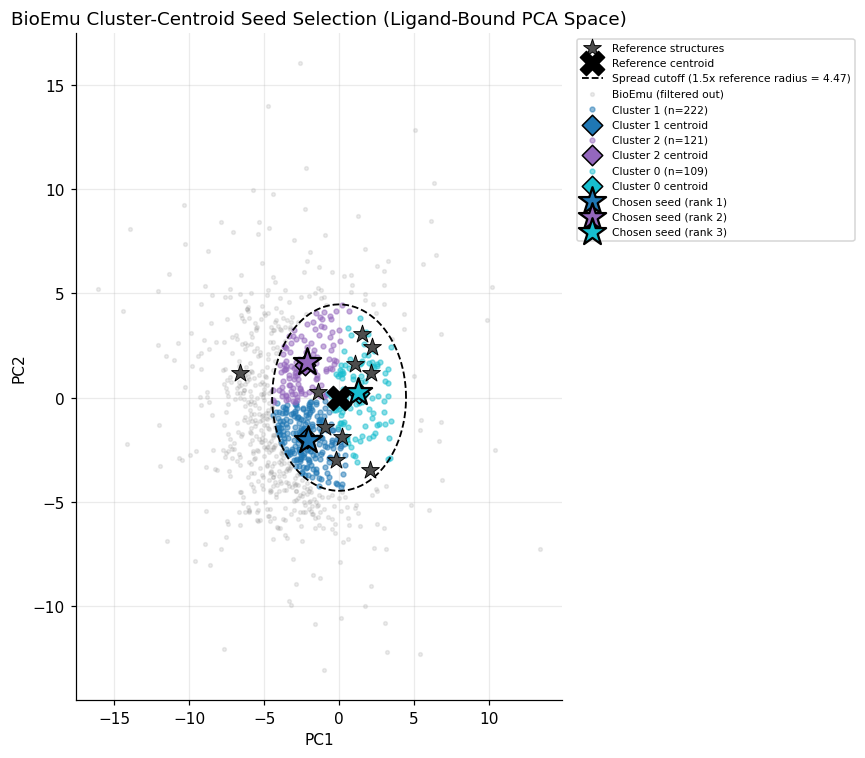

In [54]:
fig, ax = plt.subplots(figsize=(8, 7))

# Reference ensemble + its centroid (the outlier-filter anchor)
_ref_pts = pca_basis["ligand"]["ref_scores"]
ax.scatter(_ref_pts[:, 0], _ref_pts[:, 1], marker="*", s=150, color=COLOR_REF,
           edgecolor="black", linewidth=0.6, zorder=5, label="Reference structures")
ax.scatter(*bio_ref_centroid, marker="X", s=250, color="black", zorder=6,
           label="Reference centroid")

# Spread cutoff boundary (1.5x the reference's own mean radius)
_theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(bio_ref_centroid[0] + spread_cutoff * np.cos(_theta),
        bio_ref_centroid[1] + spread_cutoff * np.sin(_theta),
        linestyle="--", color="black", linewidth=1.2, zorder=4,
        label=f"Spread cutoff (1.5x reference radius = {spread_cutoff:.2f})")

# BioEmu candidates filtered out entirely (too far from the reference centroid)
_all_idx = np.arange(bio_scores["ligand"].shape[0])
_filtered_out = np.setdiff1d(_all_idx, survivors)
ax.scatter(bio_scores["ligand"][_filtered_out, 0], bio_scores["ligand"][_filtered_out, 1],
           s=6, alpha=0.15, color="grey", zorder=1, label="BioEmu (filtered out)")

# Surviving BioEmu candidates, coloured by k-means cluster, with each cluster's OWN centroid
_cluster_colors = dict(zip(kept, plt.cm.tab10(np.linspace(0, 0.9, len(kept)))))
for cid in kept:
    _members_local = np.where(cl_labels == cid)[0]
    _members = survivors[_members_local]
    ax.scatter(bio_scores["ligand"][_members, 0], bio_scores["ligand"][_members, 1],
               s=10, alpha=0.5, color=_cluster_colors[cid], zorder=2,
               label=f"Cluster {cid} (n={len(_members)})")
    _cluster_centroid = bio_scores["ligand"][_members].mean(axis=0)
    ax.scatter(*_cluster_centroid, marker="D", s=90, color=_cluster_colors[cid],
               edgecolor="black", linewidth=1.0, zorder=6, label=f"Cluster {cid} centroid")

# The actual chosen seed per cluster -- the real structure closest to its own cluster centroid
for _, row in bio_seed_table.iterrows():
    _i = int(row["frame_idx"])
    ax.scatter(bio_scores["ligand"][_i, 0], bio_scores["ligand"][_i, 1], marker="*", s=350,
               color=_cluster_colors[row["cluster_id"]], edgecolor="black", linewidth=1.5,
               zorder=7, label=f"Chosen seed (rank {row['rank']})")

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("BioEmu Cluster-Centroid Seed Selection (Ligand-Bound PCA Space)")

_handles, _labels = ax.get_legend_handles_labels()
_uniq = dict(zip(_labels, _handles))
ax.legend(_uniq.values(), _uniq.keys(), fontsize=7, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()


### PCA-Space Seed Visualisation

All selected seeds, coloured by selection criterion, projected against their source ensembles in the shared apo-state PCA basis.

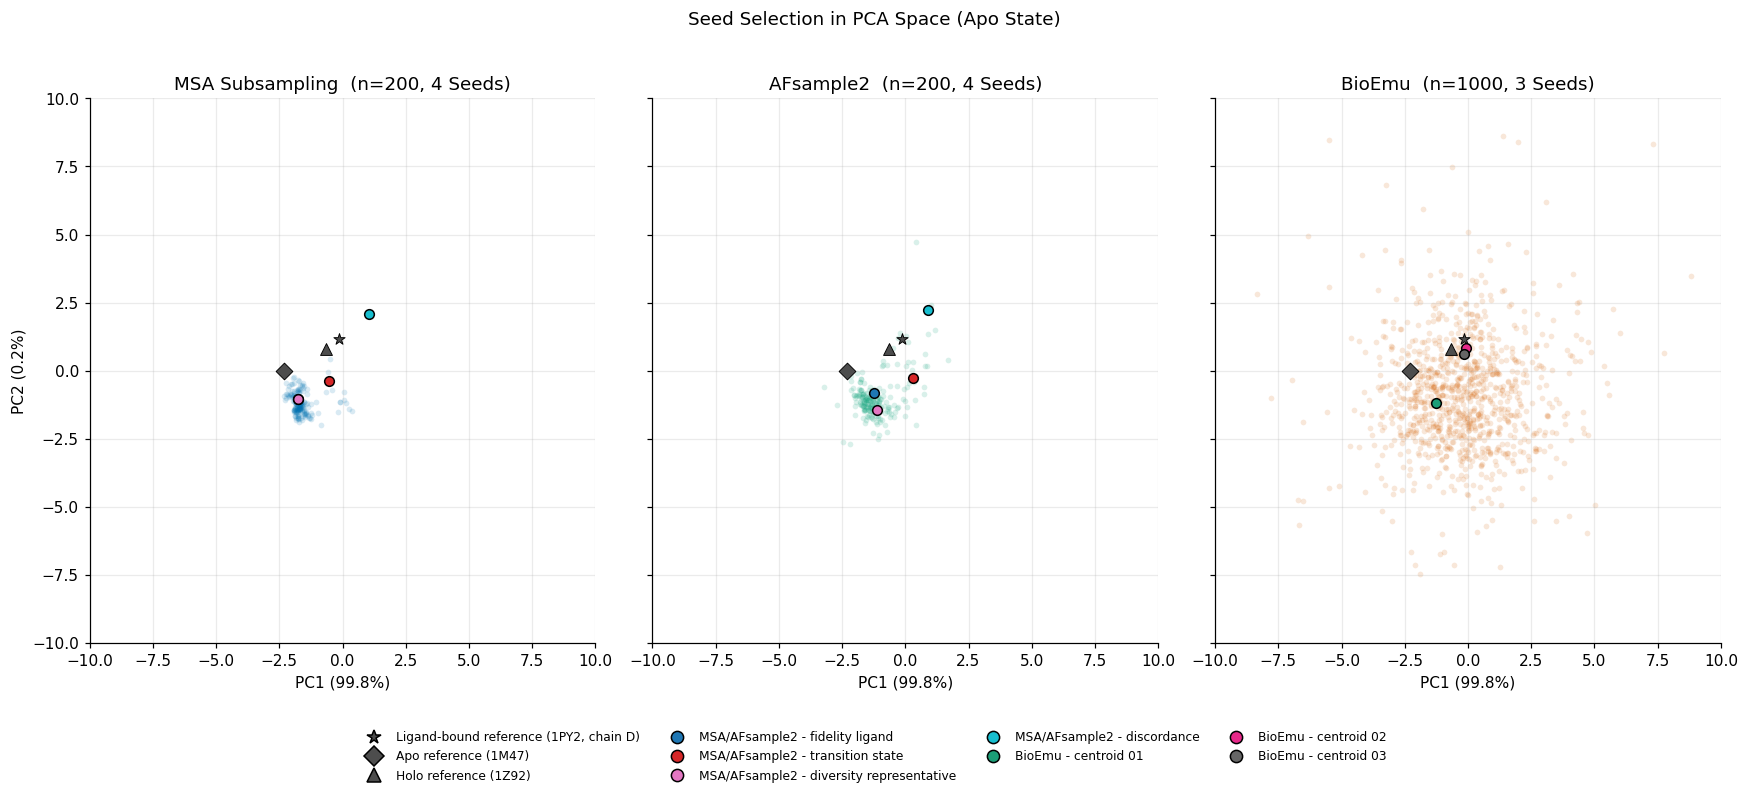

In [55]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 3, figsize=(16, 6.2), sharex=True, sharey=True)

ENSEMBLE_SCORES = {"MSA Subsampling": msa_scores["apo"],
                    "AFsample2": afs2_scores["apo"],
                    "BioEmu": bio_scores["apo"]}
SEED_TABLES = {"MSA Subsampling": msa_seed_table,
               "AFsample2": afs2_seed_table,
               "BioEmu": bio_seed_table}
apo_basis = pca_basis["apo"]

CRITERION_ORDER = ["02_fidelity_ligand", "03_transition_state",
                    "04_diversity_representative", "05_discordance"]
CRITERION_COLORS = dict(zip(CRITERION_ORDER, plt.cm.tab10(np.linspace(0, 0.9, len(CRITERION_ORDER)))))

BIOEMU_RANKS = sorted(bio_seed_table["rank"].unique()) if len(bio_seed_table) else list(range(1, 6))
BIOEMU_COLORS = dict(zip(BIOEMU_RANKS, plt.cm.Dark2(np.linspace(0, 0.9, max(len(BIOEMU_RANKS), 1)))))

REF_MARKER_SIZE = 60
SEED_MARKER_SIZE = 40


def _select_ref_chain(state, pdb_id, chain_suffix=None):
    """Pick ONE specific reference chain by PDB ID (e.g. "1M47") and, for a PDB with
    multiple IL-2 copies (1PY2 has 4: A-D), an explicit mdtraj chain-index suffix (e.g.
    "chain3"). Loads and re-parses that single PDB directly via ca_single_chain_trajs
    (Section 0), rather than depending on the ref_labels/ref_trajs globals built in
    Section 1 -- ref_labels gets reused (and clobbered from a dict into a plain list) by
    Section 6c's pocket-volume boxplot cell later on, so looking the file up fresh here
    avoids depending on execution order elsewhere in the notebook. Verified against 1PY2's
    raw ATOM records that find_il2_chains's chain order (0,1,2,3) matches the file's own
    A,B,C,D chain IDs, so "chain3" == chain D."""
    path = f"{STATE_DIRS[state]}/{pdb_id}.pdb"
    for label, traj in ca_single_chain_trajs(path):
        if chain_suffix is None or label.endswith(chain_suffix):
            return traj
    raise ValueError(f"no reference chain found for {pdb_id} ({chain_suffix}) in state {state}")


def _project_single_ref_onto_basis(traj, basis):
    """Project ONE raw CA-only reference chain onto another state's already-fit PCA basis --
    same math as project_onto_pca/_project_ref_chains_onto_basis, just for a single chain."""
    sliced = slice_to_resSeqs(traj, set(basis["resid_list"]))
    sliced.superpose(basis["mean_target"], frame=0)
    X = sliced.xyz.reshape(sliced.n_frames, -1)
    return basis["pca"].transform(X - basis["mean_"])


REF_STATE_CHAIN = {"apo": _select_ref_chain("apo", "1M47"),
                    "holo": _select_ref_chain("holo", "1Z92"),
                    "ligand": _select_ref_chain("ligand", "1PY2", chain_suffix="chain3")}
REF_STATE_SCORES = {state: _project_single_ref_onto_basis(traj, apo_basis)
                     for state, traj in REF_STATE_CHAIN.items()}
REF_STATE_MARKERS = {"ligand": "*", "apo": "D", "holo": "^"}
REF_STATE_LABELS = {"ligand": "Ligand-bound reference (1PY2, chain D)",
                     "apo": "Apo reference (1M47)", "holo": "Holo reference (1Z92)"}

axis_limits = shared_axes_limits(
    [apo_basis["ref_scores"], msa_scores["apo"], afs2_scores["apo"], bio_scores["apo"]]
    + list(REF_STATE_SCORES.values()))

for ax, model_name in zip(axes, MODEL_NAMES):
    scores = ENSEMBLE_SCORES[model_name]
    ax.scatter(scores[:, 0], scores[:, 1], s=14, alpha=0.15,
               color=MODEL_COLORS[model_name], linewidths=0, label="_nolegend_")

    for ref_state in ("apo", "holo", "ligand"):
        pt = REF_STATE_SCORES[ref_state]
        z = 6 if ref_state == "apo" else 5
        ax.scatter(pt[:, 0], pt[:, 1], marker=REF_STATE_MARKERS[ref_state],
                   s=REF_MARKER_SIZE, color=COLOR_REF, edgecolors="black", linewidths=0.6,
                   zorder=z, label="_nolegend_")

    seed_df = SEED_TABLES[model_name]
    seed_rows = seed_df.dropna(subset=["frame_idx"]) if "frame_idx" in seed_df.columns else seed_df
    for _, row in seed_rows.iterrows():
        idx = int(row["frame_idx"])
        x, y = scores[idx, 0], scores[idx, 1]
        if model_name == "BioEmu":
            case_color = BIOEMU_COLORS[row["rank"]]
        else:
            case_color = CRITERION_COLORS[row["criterion"]]
        ax.scatter(x, y, s=SEED_MARKER_SIZE, color=case_color, edgecolors="black",
                   linewidths=1.0, zorder=6, label="_nolegend_")

    ax.set_title(f"{model_name}  (n={scores.shape[0]}, {len(seed_rows)} Seeds)")
    ax.set_xlabel(f"PC1 ({apo_basis['pca'].explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)

axes[0].set_ylabel(f"PC2 ({apo_basis['pca'].explained_variance_ratio_[1]*100:.1f}%)")
fig.suptitle("Seed Selection in PCA Space (Apo State)", y=1.02)

ref_handles = [Line2D([0], [0], marker=REF_STATE_MARKERS[s], color="none",
                       markerfacecolor=COLOR_REF, markeredgecolor="black", markersize=9,
                       label=REF_STATE_LABELS[s])
               for s in ("ligand", "apo", "holo")]
criterion_handles = [Line2D([0], [0], marker="o", color="none",
                             markerfacecolor=CRITERION_COLORS[c], markeredgecolor="black",
                             markersize=8, label=f"MSA/AFsample2 - {c[3:].replace('_', ' ')}")
                      for c in CRITERION_ORDER]
bioemu_handles = [Line2D([0], [0], marker="o", color="none",
                          markerfacecolor=BIOEMU_COLORS[r], markeredgecolor="black",
                          markersize=8, label=f"BioEmu - centroid {r:02d}")
                   for r in BIOEMU_RANKS]

fig.legend(handles=ref_handles + criterion_handles + bioemu_handles,
           loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=8, frameon=False)

plt.tight_layout()
plt.show()




## 4.3. Pre-MD Minimization Sanity Gate

Before committing any seed to production MD, it is run through a quick OpenMM energy
minimization (PDBFixer adds any missing atoms/hydrogens first) -- a cheap check for whether the
seed's geometry is even a sane starting point, catching cases (e.g. severe steric clashes in a
low-confidence prediction) that would otherwise cause a production simulation to collapse before
any physically meaningful sampling occurs. This is a sanity gate, not a full physics
validation.

In [56]:
from pdbfixer import PDBFixer
from openmm import app, unit
from openmm import LangevinMiddleIntegrator

def minimize_and_check(pdb_path, max_iterations=1000, energy_per_atom_threshold=-1.0):
    try:
        fixer = PDBFixer(filename=pdb_path)
        fixer.findMissingResidues()
        fixer.missingResidues = {}  # don't model in missing loops -- keep the seed geometry as-is
        fixer.findNonstandardResidues()
        fixer.replaceNonstandardResidues()
        fixer.removeHeterogens(keepWater=False)
        fixer.findMissingAtoms()
        fixer.addMissingAtoms()
        fixer.addMissingHydrogens(7.0)

        forcefield = app.ForceField("amber14-all.xml")
        system = forcefield.createSystem(fixer.topology, nonbondedMethod=app.NoCutoff, constraints=app.HBonds)
        integrator = LangevinMiddleIntegrator(300 * unit.kelvin, 1 / unit.picosecond, 0.002 * unit.picoseconds)
        sim = app.Simulation(fixer.topology, system, integrator)
        sim.context.setPositions(fixer.positions)
        e0 = sim.context.getState(getEnergy=True).getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
        sim.minimizeEnergy(maxIterations=max_iterations)
        state = sim.context.getState(getEnergy=True, getPositions=True)
        e1 = state.getPotentialEnergy().value_in_unit(unit.kilojoule_per_mole)
        n_atoms = fixer.topology.getNumAtoms()
        e1_per_atom = e1 / n_atoms
        passed = np.isfinite(e1) and (e1 < e0) and (e1_per_atom < energy_per_atom_threshold)

        min_path = pdb_path.replace(".pdb", "_minimized.pdb")
        with open(min_path, "w") as fh:
            app.PDBFile.writeFile(fixer.topology, state.getPositions(), fh)
        return dict(e0_kJmol=round(e0, 1), e1_kJmol=round(e1, 1), n_atoms=n_atoms,
                    e1_per_atom=round(e1_per_atom, 3), passed=bool(passed), minimized_path=min_path, error=None)
    except Exception as exc:
        return dict(e0_kJmol=np.nan, e1_kJmol=np.nan, n_atoms=np.nan, e1_per_atom=np.nan,
                    passed=False, minimized_path=None, error=str(exc))


all_seed_rows = []
for df in (msa_seed_table, afs2_seed_table):
    for _, row in df.iterrows():
        if pd.isna(row["pdb_path"]):
            continue
        all_seed_rows.append(dict(model=row["model"], criterion=row["criterion"],
                                   source=row["source"], pdb_path=row["pdb_path"]))
for _, row in bio_seed_table.iterrows():
    all_seed_rows.append(dict(model="BioEmu", criterion=f"centroid_{row['rank']:02d}",
                               source=row["source"], pdb_path=row["pdb_path"]))

min_results = []
for r in all_seed_rows:
    res = minimize_and_check(r["pdb_path"])
    min_results.append({**r, **res})
    status = "PASS" if res["passed"] else f"FAIL ({res['error'] or 'energy gate'})"
    print(f"{r['model']:16s} {r['criterion']:28s} E0={res['e0_kJmol']!s:>14} E1={res['e1_kJmol']!s:>12} "
          f"({res['e1_per_atom']!s} kJ/mol/atom) -- {status}")

min_results_df = pd.DataFrame(min_results)
print(f"\n{min_results_df['passed'].sum()}/{len(min_results_df)} seeds passed the minimization sanity gate")

MSA Subsampling  02_fidelity_ligand           E0=       11542.2 E1=    -13889.0 (-6.316 kJ/mol/atom) -- PASS


MSA Subsampling  03_transition_state          E0=      106809.4 E1=    -13781.0 (-6.267 kJ/mol/atom) -- PASS


MSA Subsampling  04_diversity_representative  E0=       14156.3 E1=    -13781.2 (-6.267 kJ/mol/atom) -- PASS


MSA Subsampling  05_discordance               E0=       80564.5 E1=    -13961.8 (-6.349 kJ/mol/atom) -- PASS


AFsample2        02_fidelity_ligand           E0=       19674.9 E1=    -13982.1 (-6.358 kJ/mol/atom) -- PASS


...

AFsample2        04_diversity_representative  E0=       13542.1 E1=    -14030.6 (-6.38 kJ/mol/atom) -- PASS


AFsample2        05_discordance               E0=    15502075.1 E1=    -13789.4 (-6.271 kJ/mol/atom) -- PASS


BioEmu           centroid_01                  E0=615428889105.8 E1=    -11535.2 (-5.241 kJ/mol/atom) -- PASS


BioEmu           centroid_02                  E0= 26322520071.0 E1=    -10522.1 (-4.785 kJ/mol/atom) -- PASS


BioEmu           centroid_03                  E0=   410028066.7 E1=    -11530.3 (-5.243 kJ/mol/atom) -- PASS

11/11 seeds passed the minimization sanity gate


## 4.4. Secondary-Structure Recovery of Seeds

The same per-residue DSSP comparison as Section 2.1, restricted to just the 11 selected MD
seeds, laid out against the 1M47 apo reference so any seed with an already-degraded local fold
going into MD is visible before committing simulation time to it.

In [57]:
from matplotlib.colors import ListedColormap

SS_CODE4 = {"C": 0, "H": 1, "E": 2, "U": 3}
SS_COLORS4 = {"H": "#e6194B", "E": "#ffe119", "C": "#dcdcdc", "U": "#ffffff"}
SS_CMAP4 = ListedColormap([SS_COLORS4["C"], SS_COLORS4["H"], SS_COLORS4["E"], SS_COLORS4["U"]])

seed_ss_source = {"MSA Subsampling": msa_dssp, "AFsample2": afs2_dssp, "BioEmu": bio_dssp}

seed_ss_rows = []
for _, row in msa_seed_table.iterrows():
    if pd.isna(row["pdb_path"]):
        continue
    seed_ss_rows.append((f"MSA Subsampling / {row['criterion']}", "MSA Subsampling", int(row["frame_idx"])))
for _, row in afs2_seed_table.iterrows():
    if pd.isna(row["pdb_path"]):
        continue
    seed_ss_rows.append((f"AFsample2 / {row['criterion']}", "AFsample2", int(row["frame_idx"])))
for _, row in bio_seed_table.iterrows():
    seed_ss_rows.append((f"BioEmu / centroid_{row['rank']:02d}", "BioEmu", int(row["frame_idx"])))


def single_chain_ss(pdb_path):
    """DSSP for one specific reference PDB (single chain) -- anchors against 1M47 rather
    than a pooled per-state consensus."""
    label, t = full_atom_single_chain_trajs(pdb_path)[0]
    return {r: lab[0] for r, lab in dssp_by_resSeq(t).items() if lab[0] != "NA"}


seed_ss_ref_consensus = single_chain_ss(f"{STATE_DIRS['apo']}/1M47.pdb")
# Full 1-133 range, not just 1M47's resolved residues -- residues 1M47 has no modelled
# density for (crystallographic gaps like 75-76/99-102, or entirely outside its resolved
# span) are kept as real columns and marked "unmodelled" below instead of silently
# skipped, so the seeds -- modelled at every position -- stay column-aligned to true
# residue number rather than drifting after each gap.
seed_ss_resSeqs = list(range(1, 134))
seed_ss_ref_codes = np.array([[SS_CODE4[seed_ss_ref_consensus.get(r, "U")] for r in seed_ss_resSeqs]])

seed_ss_matrix = np.full((len(seed_ss_rows), len(seed_ss_resSeqs)), np.nan)
seed_ss_labels = []
for row_i, (label, model, fi) in enumerate(seed_ss_rows):
    ss_by_res = seed_ss_source[model]
    matches = scored = 0
    for col_i, r in enumerate(seed_ss_resSeqs):
        if r not in ss_by_res or fi >= len(ss_by_res[r]):
            continue
        lab = ss_by_res[r][fi]
        if lab == "NA":
            continue
        seed_ss_matrix[row_i, col_i] = SS_CODE4[lab]
        ref_lab = seed_ss_ref_consensus.get(r)  # None where 1M47 has no modelled density
        if ref_lab is not None:
            scored += 1
            matches += lab == ref_lab
    seed_ss_labels.append(f"{label}  ({100*matches/scored:.0f}% match)" if scored else f"{label}  (n/a)")



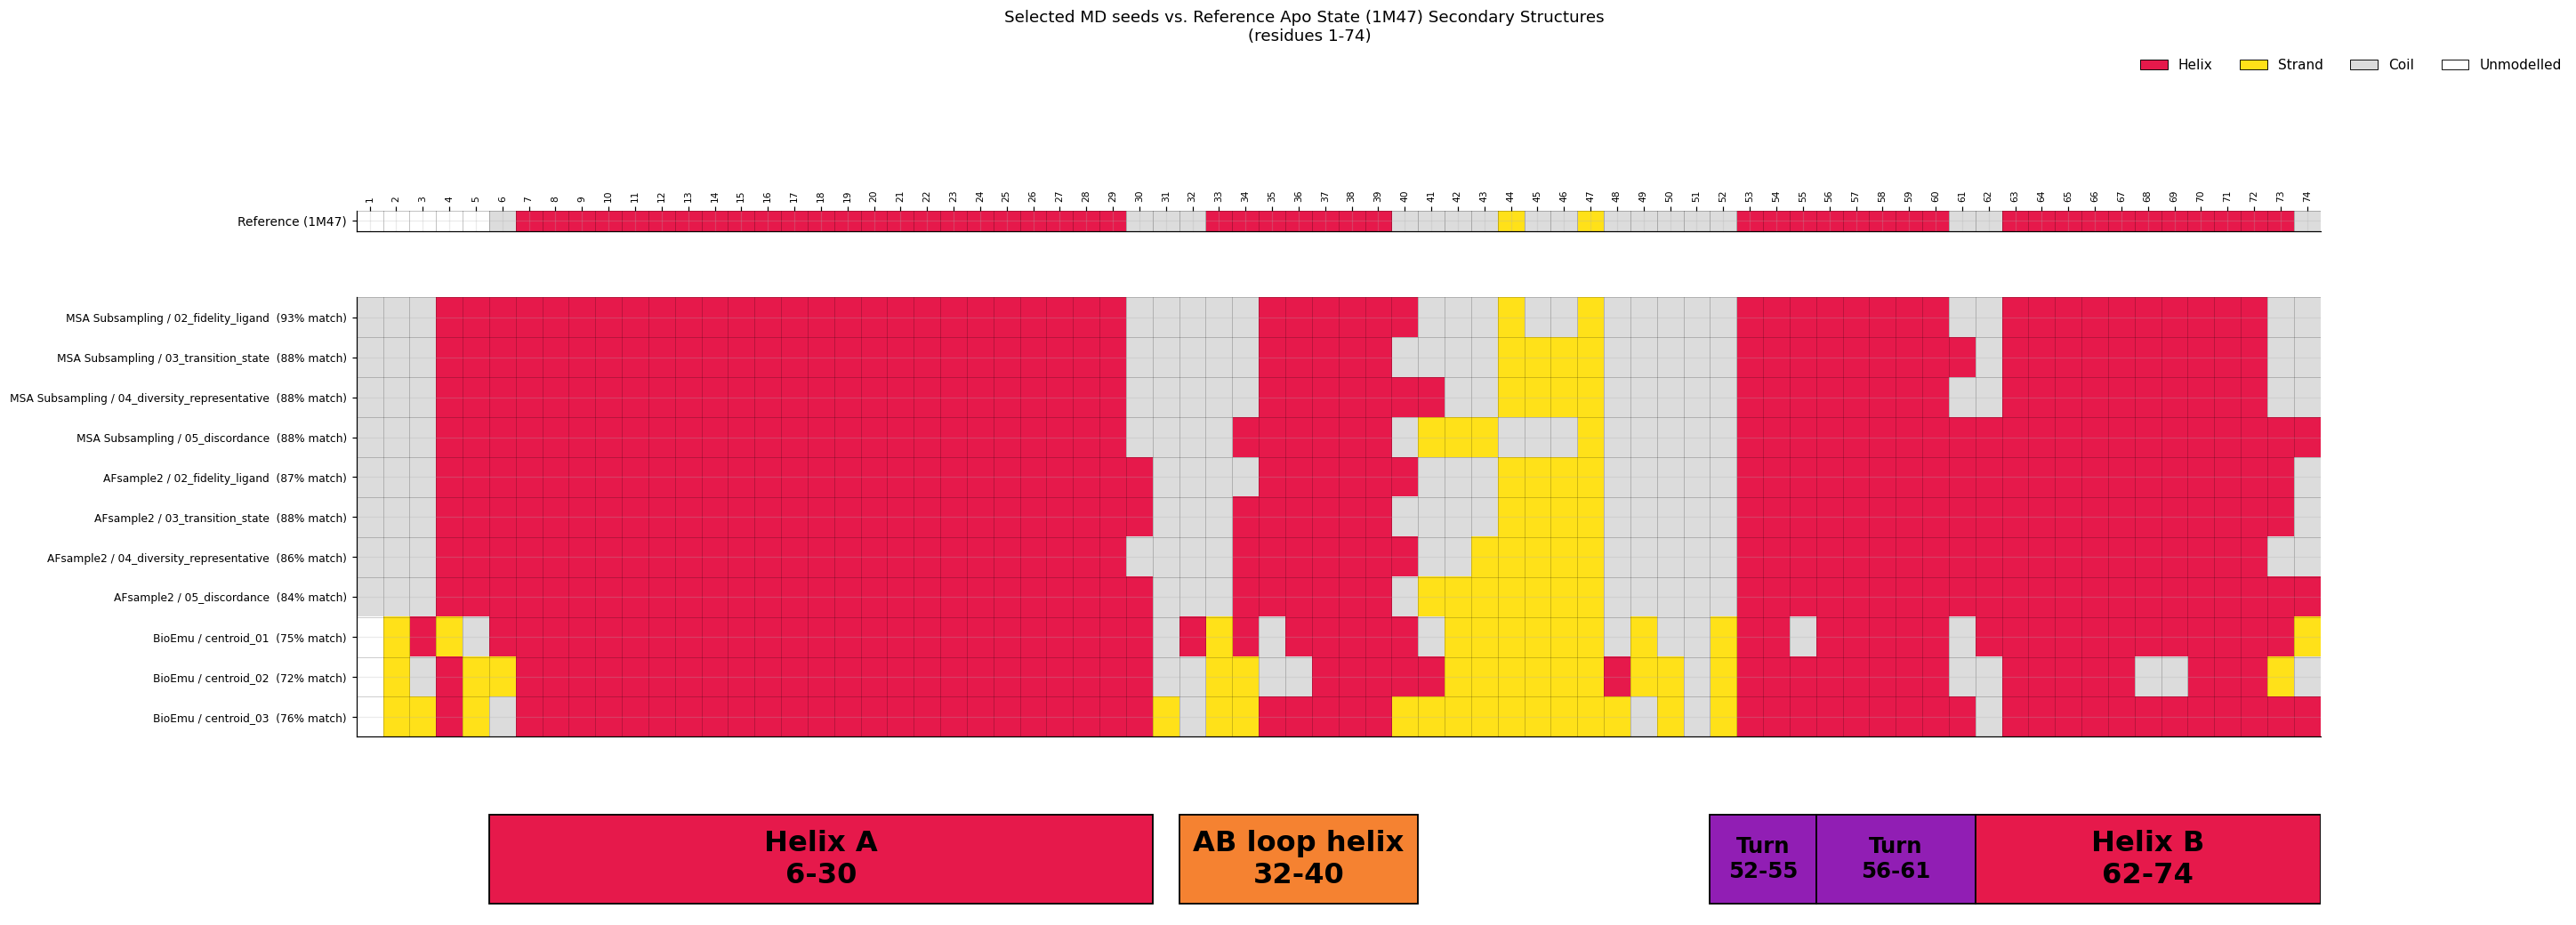

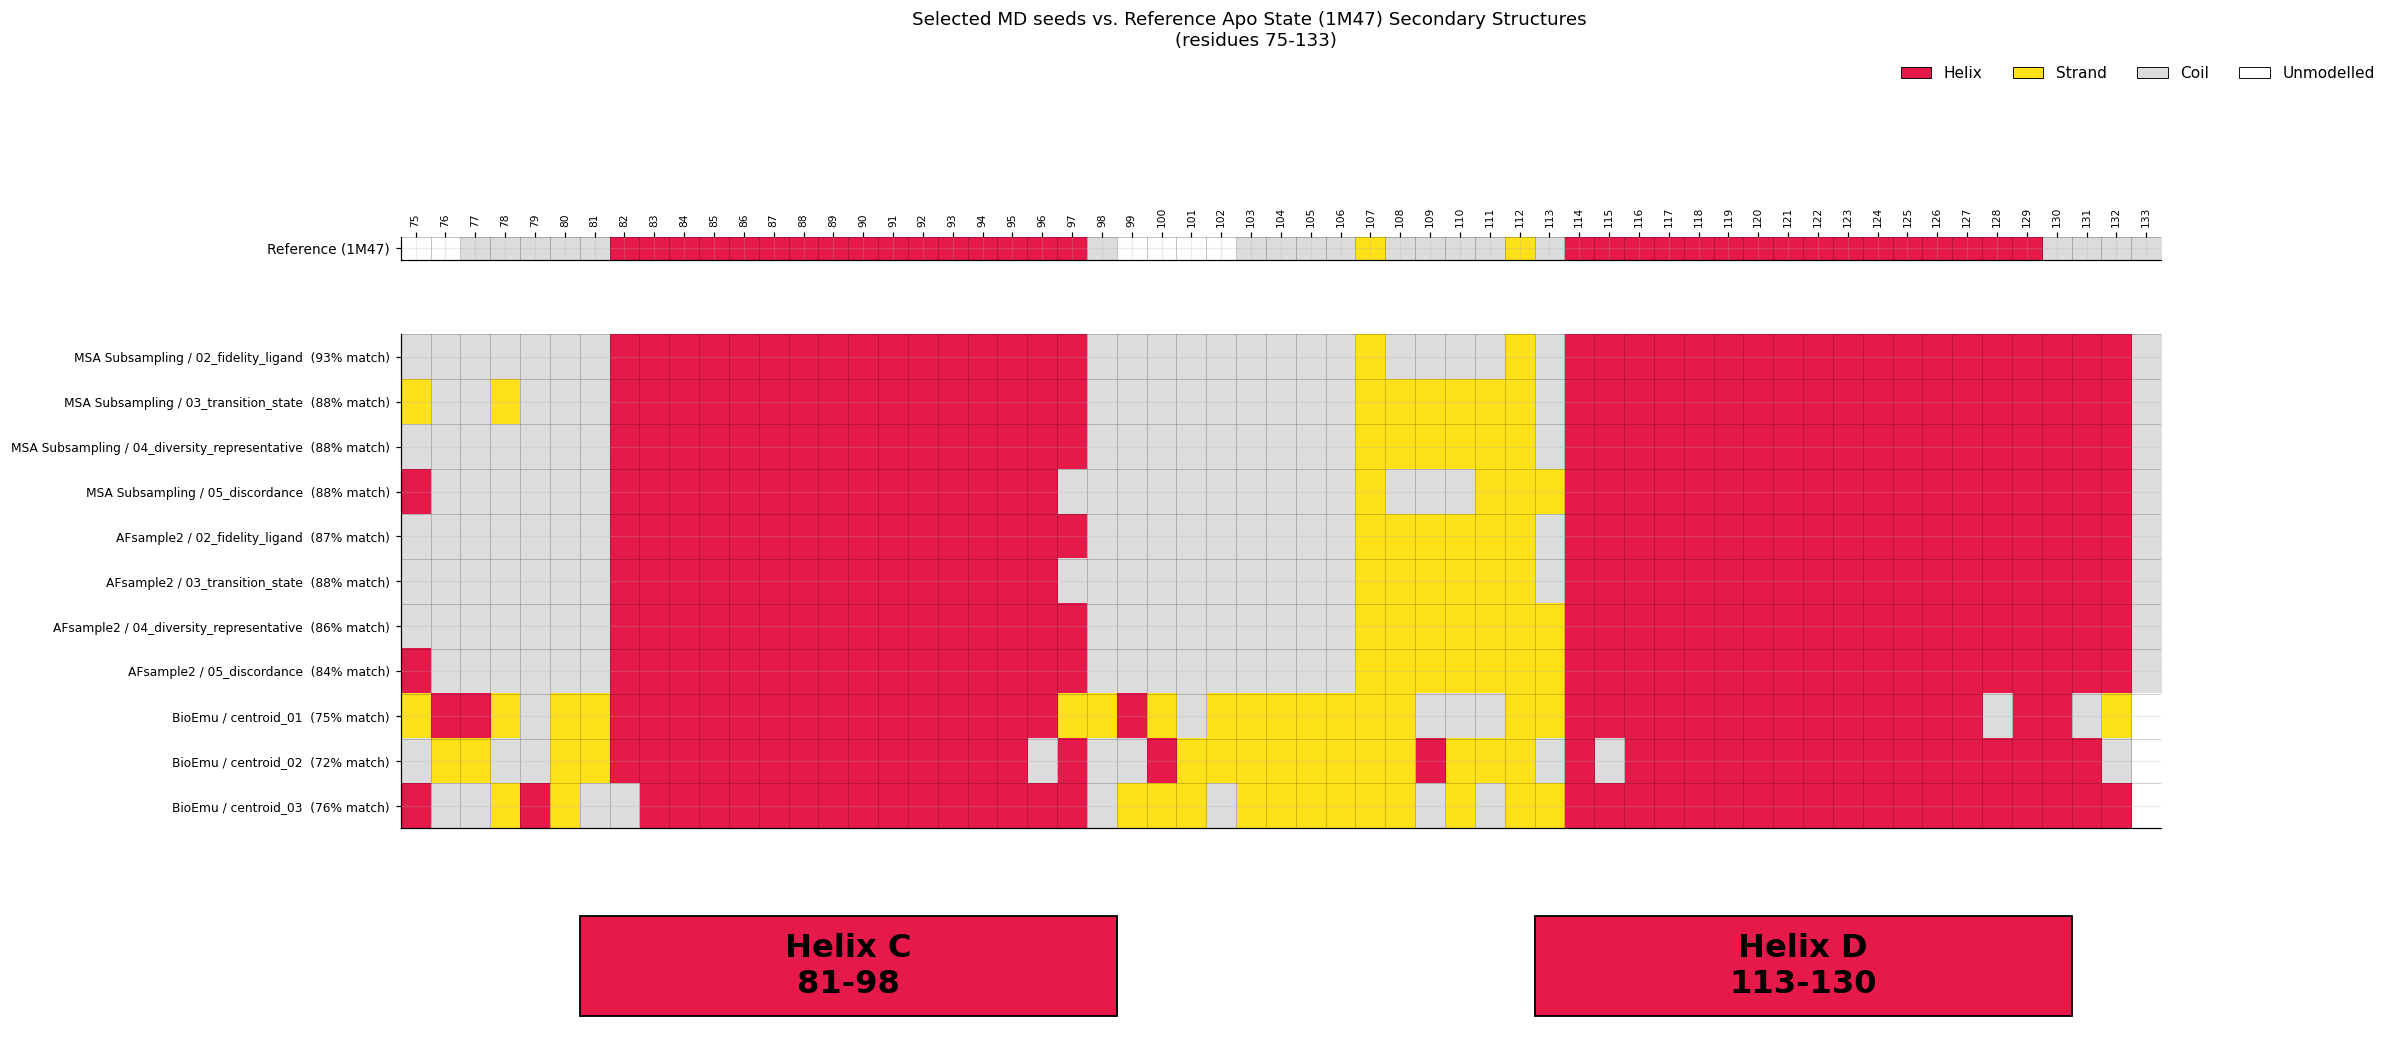

In [58]:
NAMED_SEGMENTS = [
    ("Helix A", 6, 30, "#e6194B"),
    ("AB loop helix", 32, 40, "#f58231"),
    ("Turn", 52, 55, "#911eb4"),
    ("Turn", 56, 61, "#911eb4"),
    ("Helix B", 62, 74, "#e6194B"),
    ("Helix C", 81, 98, "#e6194B"),
    ("Helix D", 113, 130, "#e6194B"),
]


def plot_seed_ss_panel(col_lo, col_hi, panel_label, save_path):
    resSeqs_p = seed_ss_resSeqs[col_lo:col_hi]
    n_p = len(resSeqs_p)
    ref_codes_p = seed_ss_ref_codes[:, col_lo:col_hi]
    matrix_p = seed_ss_matrix[:, col_lo:col_hi]
    resSeq_to_col_p = {r: i for i, r in enumerate(resSeqs_p)}
    segs_p = [(name, start, end, color) for name, start, end, color in NAMED_SEGMENTS
              if start in resSeq_to_col_p and end in resSeq_to_col_p]

    fig, axes = plt.subplots(3, 1, figsize=(0.35 * n_p, 0.35 * len(seed_ss_rows) + 5.5),
                              gridspec_kw={"height_ratios": [0.5, len(seed_ss_rows), 2.8], "hspace": 0.35})
    ax_ref, ax_seeds, ax_ranges = axes

    ax_ref.imshow(ref_codes_p, aspect="auto", cmap=SS_CMAP4, vmin=0, vmax=3)
    ax_ref.set_yticks([0]); ax_ref.set_yticklabels(["Reference (1M47)"], fontsize=9)
    ax_ref.set_xticks(np.arange(-0.5, n_p, 1), minor=True)
    ax_ref.set_yticks(np.arange(-0.5, 1, 1), minor=True)
    ax_ref.grid(which="minor", color="black", linewidth=0.6)
    ax_ref.tick_params(which="minor", length=0)
    ax_ref.xaxis.set_ticks_position("top")
    ax_ref.set_xticks(range(n_p))
    ax_ref.set_xticklabels(resSeqs_p, fontsize=7, rotation=90)

    ax_seeds.imshow(np.ma.masked_invalid(matrix_p), aspect="auto", cmap=SS_CMAP4, vmin=0, vmax=3)
    ax_seeds.set_yticks(range(len(seed_ss_rows)))
    ax_seeds.set_yticklabels(seed_ss_labels, fontsize=8)
    ax_seeds.set_xticks(np.arange(-0.5, n_p, 1), minor=True)
    ax_seeds.set_yticks(np.arange(-0.5, len(seed_ss_rows), 1), minor=True)
    ax_seeds.grid(which="minor", color="black", linewidth=0.5)
    ax_seeds.tick_params(which="minor", length=0)
    ax_seeds.set_xticks([])

    ax_ranges.set_xlim(-0.5, n_p - 0.5)
    ax_ranges.set_ylim(0, 1)
    ax_ranges.axis("off")
    for name, start, end, color in segs_p:
        c0, c1 = resSeq_to_col_p[start], resSeq_to_col_p[end]
        width = c1 - c0 + 1
        ax_ranges.add_patch(plt.Rectangle((c0 - 0.5, 0.1), width, 0.8, facecolor=color,
                                           edgecolor="black", linewidth=1.2))
        ax_ranges.text(c0 + width / 2 - 0.5, 0.5, f"{name}\n{start}-{end}", ha="center", va="center",
                        fontsize=16 if width < 8 else 21, fontweight="bold")

    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=SS_COLORS4[k], edgecolor="black", linewidth=0.6)
               for k in ["H", "E", "C", "U"]]
    fig.legend(handles, ["Helix", "Strand", "Coil", "Unmodelled"], loc="upper right",
               bbox_to_anchor=(1.0, 1.06), fontsize=10, frameon=False, ncol=4)

    fig.suptitle(f"Selected MD seeds vs. Reference Apo State (1M47) Secondary Structures \n ({panel_label})",
                 fontsize=12, y=1.1)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


split_col = seed_ss_resSeqs.index(74) + 1
plot_seed_ss_panel(0, split_col, f"residues {seed_ss_resSeqs[0]}-{seed_ss_resSeqs[split_col - 1]}",
                    "../outputs/figures/seed_ss_vs_reference_part1.png")
plot_seed_ss_panel(split_col, len(seed_ss_resSeqs), f"residues {seed_ss_resSeqs[split_col]}-{seed_ss_resSeqs[-1]}",
                    "../outputs/figures/seed_ss_vs_reference_part2.png")


**Interpretation.** Every MSA Subsampling and AFsample2 seed enters MD with a
secondary-structure fold already close to the apo reference; BioEmu's three centroids show more
scattered disagreement in the flexible loop/turn regions (residues 32–61) specifically, not in
the core helices -- consistent with Section 2.2c's finding that BioEmu's fold quality, not its
diversity per se, is where it lags the two AlphaFold2-based methods.

## 4.5. Summary Card of Seeds

Complete per-seed record: binding-site Cα RMSD to all three reference states, secondary-structure
recovery, pocket-lining volume and open/closed classification, and gating-residue χ1 agreement
count, for all 11 selected MD seeds.

In [59]:
seed_raw_pdb_rows = []
for _, row in msa_seed_table.iterrows():
    if pd.isna(row["pdb_path"]):
        continue
    fi = int(row["frame_idx"])
    seed_raw_pdb_rows.append(dict(model="MSA Subsampling", criterion=row["criterion"],
                                   source=row["source"], seed_pdb_path=row["pdb_path"],
                                   raw_pdb_path=msa_meta_idx.loc[fi, "path"]))
for _, row in afs2_seed_table.iterrows():
    if pd.isna(row["pdb_path"]):
        continue
    fi = int(row["frame_idx"])
    seed_raw_pdb_rows.append(dict(model="AFsample2", criterion=row["criterion"],
                                   source=row["source"], seed_pdb_path=row["pdb_path"],
                                   raw_pdb_path=afs2_meta_idx.loc[fi, "path"]))
for _, row in bio_seed_table.iterrows():
    seed_raw_pdb_rows.append(dict(model="BioEmu", criterion=f"centroid_{row['rank']:02d}",
                                   source=row["source"], seed_pdb_path=row["pdb_path"],
                                   raw_pdb_path=None))  # no AF2-style pLDDT / raw prediction file exists for BioEmu

seed_raw_pdb_df = pd.DataFrame(seed_raw_pdb_rows)
seed_raw_pdb_df.to_csv("../outputs/md_seeds/seed_raw_pdb_paths.csv", index=False)
print(f"Saved seed -> raw AF2 prediction PDB path mapping ({len(seed_raw_pdb_df)} rows) -> "
      f"outputs/md_seeds/seed_raw_pdb_paths.csv")
seed_raw_pdb_df


Saved seed -> raw AF2 prediction PDB path mapping (11 rows) -> outputs/md_seeds/seed_raw_pdb_paths.csv


,model,criterion,source,seed_pdb_path,raw_pdb_path
0,MSA Subsampling,02_fidelity_ligand,MSA:msa_032_064:rank014_model5_seed0,../outputs/md_seeds/MSA_Subsampling/02_fidelit...,data/raw/af2_msa_sweep/msa_032_064/IL-2_pdb_1M...
1,MSA Subsampling,03_transition_state,MSA:msa_008_016:rank038_model1_seed0,../outputs/md_seeds/MSA_Subsampling/03_transit...,data/raw/af2_msa_sweep/msa_008_016/IL-2_pdb_1M...
2,MSA Subsampling,04_diversity_representative,MSA:full_msa:rank032_model1_seed1,../outputs/md_seeds/MSA_Subsampling/04_diversi...,data/raw/af2_msa_sweep/full_msa/IL-2_pdb_1M47_...
3,MSA Subsampling,05_discordance,MSA:msa_008_016:rank040_model2_seed3,../outputs/md_seeds/MSA_Subsampling/05_discord...,data/raw/af2_msa_sweep/msa_008_016/IL-2_pdb_1M...
4,AFsample2,02_fidelity_ligand,AFS2:frac_015:model4_pred4,../outputs/md_seeds/AFsample2/02_fidelity_liga...,data/raw/afsample2/outputs/frac_015/il2/afsamp...
5,AFsample2,03_transition_state,AFS2:frac_030:model5_pred4,../outputs/md_seeds/AFsample2/03_transition_st...,data/raw/afsample2/outputs/frac_030/il2/afsamp...
6,AFsample2,04_diversity_representative,AFS2:frac_015:model3_pred8,../outputs/md_seeds/AFsample2/04_diversity_rep...,data/raw/afsample2/outputs/frac_015/il2/afsamp...
7,AFsample2,05_discordance,AFS2:frac_020:model2_pred9,../outputs/md_seeds/AFsample2/05_discordance.pdb,data/raw/afsample2/outputs/frac_020/il2/afsamp...
8,BioEmu,centroid_01,BioEmu:785,../outputs/md_seeds/BioEmu/centroid_01.pdb,None
9,BioEmu,centroid_02,BioEmu:580,../outputs/md_seeds/BioEmu/centroid_02.pdb,None


In [60]:
density_ligand_by_model = {
    name: density_vs_refdist_df[(density_vs_refdist_df["state"] == "ligand") &
                                 (density_vs_refdist_df["model"] == name)].reset_index(drop=True)
    for name in MODEL_NAMES
}

def final_seed_row(model_name, criterion_or_rank, source, frame_idx):
    chi1_row = model_chi1_dfs[model_name].iloc[frame_idx]
    density_row = density_ligand_by_model[model_name].iloc[frame_idx]

    return dict(
        model=model_name, criterion=criterion_or_rank, source=source,
        rmsd_to_apo_A=round(float(bs_rmsd_apo[model_name][frame_idx]), 2),
        rmsd_to_holo_A=round(float(bs_rmsd_holo[model_name][frame_idx]), 2),
        rmsd_to_ligand_A=round(float(bs_rmsd_ligand[model_name][frame_idx]), 2),
        ss_identity_pct=round(float(density_row["pct_ss_identity"]), 1),
        pocket_volume_A3=round(float(chi1_row["pocket_volume_A3"]), 1),
        pocket_open=bool(chi1_row["pocket_open"]),
        chi1_agreement_count=int(sum(chi1_row[f"res{r}_open"] for r in GATING_RESIDUES)),
    )

final_summary_rows = []
for df in (msa_seed_table, afs2_seed_table):
    for _, row in df.iterrows():
        if pd.isna(row["pdb_path"]):
            continue
        final_summary_rows.append(final_seed_row(row["model"], row["criterion"], row["source"], int(row["frame_idx"])))

for _, row in bio_seed_table.iterrows():
    final_summary_rows.append(final_seed_row("BioEmu", f"centroid_{row['rank']:02d}", row["source"], int(row["frame_idx"])))

final_seed_summary_df = pd.DataFrame(final_summary_rows).rename(columns={
    "model": "Model", "criterion": "Selection Criterion", "source": "Source Structure",
    "rmsd_to_apo_A": "RMSD to Apo (A)", "rmsd_to_holo_A": "RMSD to Holo (A)",
    "rmsd_to_ligand_A": "RMSD to Ligand-Bound (A)", "ss_identity_pct": "SS Recovery (Q3 %)",
    "pocket_volume_A3": "Pocket Volume (A3)", "pocket_open": "Pocket Open",
    "chi1_agreement_count": "chi1 Agreement Count (/3)"})
print(final_seed_summary_df.to_markdown(index=False))


| Model           | Selection Criterion         | Source Structure                     |   RMSD to Apo (A) |   RMSD to Holo (A) |   RMSD to Ligand-Bound (A) |   SS Recovery (Q3 %) |   Pocket Volume (A3) | Pocket Open   |   chi1 Agreement Count (/3) |
|:----------------|:----------------------------|:-------------------------------------|------------------:|-------------------:|---------------------------:|---------------------:|---------------------:|:--------------|----------------------------:|
| MSA Subsampling | 02_fidelity_ligand          | MSA:msa_032_064:rank014_model5_seed0 |              0.97 |               0.88 |                       0.59 |                 95.4 |               1433.1 | False         |                           2 |
| MSA Subsampling | 03_transition_state         | MSA:msa_008_016:rank038_model1_seed0 |              1.66 |               1.15 |                       1.27 |                 89.2 |               1398.8 | False         |                           